## Imports and paths

In [2]:
# stdlib
import sys
import yaml
from pathlib import Path

# third-party
import atlite
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import geopandas as gpd
import pypsa
import xarray as xr
from atlite.resource import get_windturbineconfig

# directory set up on cluster

# root = Path.cwd()
# pypsa_eur_root = root  

# pypsa_eur_scripts = pypsa_eur_root / "scripts"

# sys.path.insert(0, str(pypsa_eur_scripts / "_testing"))

# directory set up on local machine
root = Path.cwd()
pypsa_eur_root = root.parent.parent  

pypsa_eur_scripts = pypsa_eur_root / "scripts"

sys.path.insert(0, str(pypsa_eur_root))
sys.path.insert(0, str(pypsa_eur_scripts))
sys.path.insert(0, str(pypsa_eur_scripts / "_testing"))

In [3]:
sys.path

['/home/lois/pypsa-eur/pypsa-eur/scripts/_testing',
 '/home/lois/pypsa-eur/pypsa-eur/scripts',
 '/home/lois/pypsa-eur/pypsa-eur',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python313.zip',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/lib-dynload',
 '',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/site-packages']

In [4]:
from scripts.build_damage_profiles.build_wind_damage_profiles import compute_wind_damage, aggregate_to_buses
from plot_stats import compute_stats_diff, format_stats_df, iplot_stats_bar, plot_stats_bar
from plot_damage import (
    iplot_plant_profile,
    iplot_bus_profile,
    iplot_vulnerability_table,
    plot_plant_profile,
    plot_bus_profile,
    plot_vulnerability_table,
)

from plot_stats import eb_imap_network

from styles import _compute_day_ticks, _DAMAGE_COLORS

print("Imports OK")

Imports OK


In [5]:
# ===========================================================================
# CONFIGURATION — edit here
# ===========================================================================
CONFIG_NAME = "2021-GB"
YEAR        = 2021
CLUSTERS    = 5

SNAP_START  = "2021-06-01"
SNAP_END    = "2022-05-31 23:00"

CARRIERS = {
    "onwind":        ("availability_matrix_5_onwind.nc",        "Vestas_V112_3MW"),
    "offwind-ac":    ("availability_matrix_5_offwind-ac.nc",    "NREL_ReferenceTurbine_2020ATB_5.5MW"),
    "offwind-dc":    ("availability_matrix_5_offwind-dc.nc",    "NREL_ReferenceTurbine_2020ATB_5.5MW"),
    # "offwind-float": ("availability_matrix_5_offwind-float.nc", "NREL_ReferenceTurbine_5MW_offshore"),
}

_cutout_dir = pypsa_eur_root / "data/cutout/build/unknown"
CUTOUT_PATHS = [
    _cutout_dir / f"europe-{YEAR}-era5_fg10_lmlt.nc",
    _cutout_dir / f"europe-{YEAR + 1}-era5_fg10_lmlt.nc",
]

_results = pypsa_eur_root / "results" / CONFIG_NAME

SCENARIO_VARIANTS = {
    "cap":           f"weather_year_{YEAR}_win_cap_LGLP",
    "dis":           f"weather_year_{YEAR}_win_dis_LGLP",
    "base":         f"weather_year_{YEAR}_win_base_LGLP",
    # "base_line-on": f"weather_year_{YEAR}_win_dis_line-on",
    # "cap_line-on":   f"weather_year_{YEAR}_win_cap_line-on",
    # "dis_line-on":   f"weather_year_{YEAR}_win_dis_line-on",
}

NETWORK_PATHS = {
    "base":     _results / f"weather_year_{YEAR}_win_dis_LGLP" / "networks" / "base_s_5_elec_.nc",
    "base_dis": _results / f"weather_year_{YEAR}_win_base_LGLP" / "networks" / "base_s_5_elec__op.nc",
    "cap":      _results / f"weather_year_{YEAR}_win_cap_LGLP"  / "networks" / "base_s_5_elec_.nc",
    "cap_on": _results / f"weather_year_{YEAR}_win_cap_LGLP" / "networks" / "base_s_5_elec__op.nc",
    "dis":      _results / f"weather_year_{YEAR}_win_dis_LGLP"  / "networks" / "base_s_5_elec__damaged-dispatch.nc",
}





## Load gust data

In [6]:
snapshot_index = pd.date_range(start=f"{YEAR + 1}-01-01", end=SNAP_END, freq="h", inclusive="both")
CUTOUT_DIR = CUTOUT_PATHS[0].parent

GUST_CACHE = CUTOUT_DIR / f"wnd_gust10m_{YEAR + 1}-01_{YEAR + 1}-05.nc"

cutout_y2 = atlite.Cutout(CUTOUT_PATHS[1])

if GUST_CACHE.exists():
    V_p = xr.open_dataarray(GUST_CACHE)
    print(f"Loaded from cache: {GUST_CACHE}")
else:
    V_p = cutout_y2.data["wnd_gust10m"].sel(time=slice(f"{YEAR + 1}-01-01", SNAP_END))
    V_p.to_netcdf(GUST_CACHE)
    print(f"Saved to cache: {GUST_CACHE}")


Loaded from cache: /home/lois/pypsa-eur/pypsa-eur/data/cutout/build/unknown/wnd_gust10m_2022-01_2022-05.nc


## bus to cell mapping

In [7]:
cutout_2022 = atlite.Cutout(_cutout_dir / "europe-2022-era5_fg10_lmlt.nc")

In [8]:
SCENARIO_DIR = pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS["dis"]
SCENARIO_DIR

PosixPath('/home/lois/pypsa-eur/pypsa-eur/resources/2021-GB/weather_year_2021_win_dis_LGLP')

/tmp/ipykernel_468950/3255403765.py:1: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



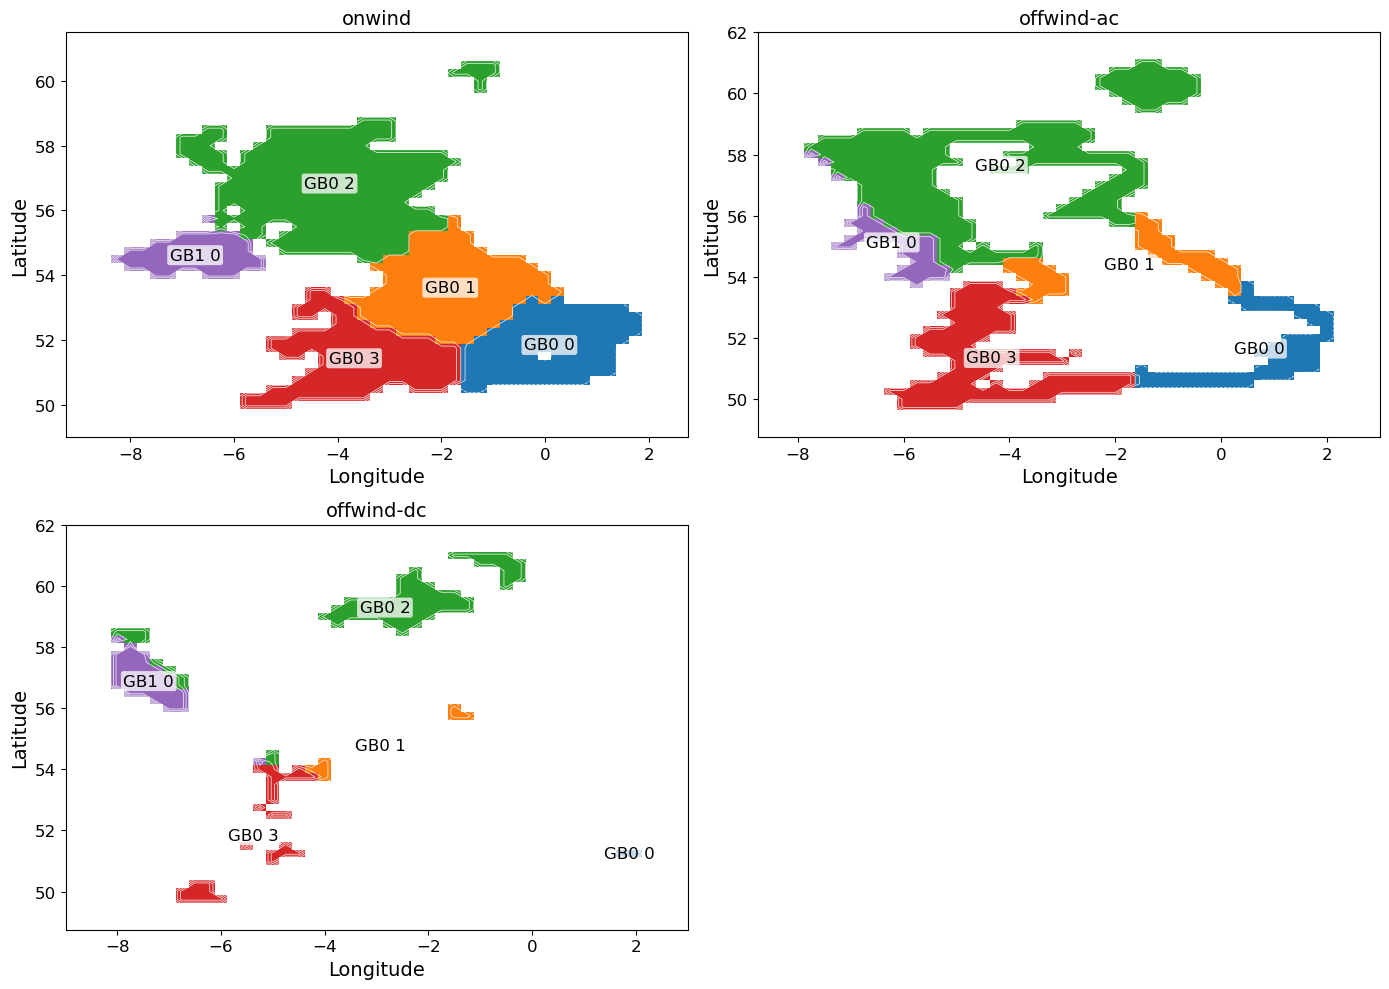

In [10]:
cmap = plt.cm.get_cmap("tab10")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (carrier, (avail_file, turbine)) in zip(axes.flat, CARRIERS.items()):
    avail = xr.open_dataarray(SCENARIO_DIR / avail_file)
    avail_total = avail.sum(dim="bus")
    has_avail = avail_total > 0

    # Colour each cell by dominant bus index
    dom_bus = avail.argmax(dim="bus").where(has_avail).astype(float)
    dom_bus.plot(ax=ax, cmap="tab10", vmin=0, vmax=9, add_colorbar=False)

    # Bus region borders via contour on the integer bus index array
    dom_int = avail.argmax(dim="bus").where(has_avail, other=-1)
    ax.contour(
        dom_int.x.values, dom_int.y.values, dom_int.values,
        levels=np.arange(-0.5, len(avail.bus) + 0.5, 1),
        colors="white", linewidths=0.6, alpha=0.8,
    )

    # Bus label at centroid of each region
    for i, bus in enumerate(avail.bus.values):
        mask = (avail.argmax(dim="bus") == i) & has_avail
        if mask.any():
            y_c = float(avail.y.where(mask).mean())
            x_c = float(avail.x.where(mask).mean())
            ax.text(x_c, y_c, bus, fontsize=12, ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.75, edgecolor="none"))

    # Zoom to active cells
    x_act = avail.x.where(has_avail.any(dim="y"), drop=True)
    y_act = avail.y.where(has_avail.any(dim="x"), drop=True)
    if len(x_act) and len(y_act):
        ax.set_xlim(float(x_act.min()) - 1, float(x_act.max()) + 1)
        ax.set_ylim(float(y_act.min()) - 1, float(y_act.max()) + 1)

    ax.set_title(carrier)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

for ax in axes.flat[len(CARRIERS):]:
    ax.set_visible(False)

# plt.suptitle("Bus allocation per grid cell — all carriers, 5 clusters", y=1.01)
plt.tight_layout()
plt.show()


## compute layout weights — grid maps (all carriers)

Spatial weighting check — onwind, 5 clusters


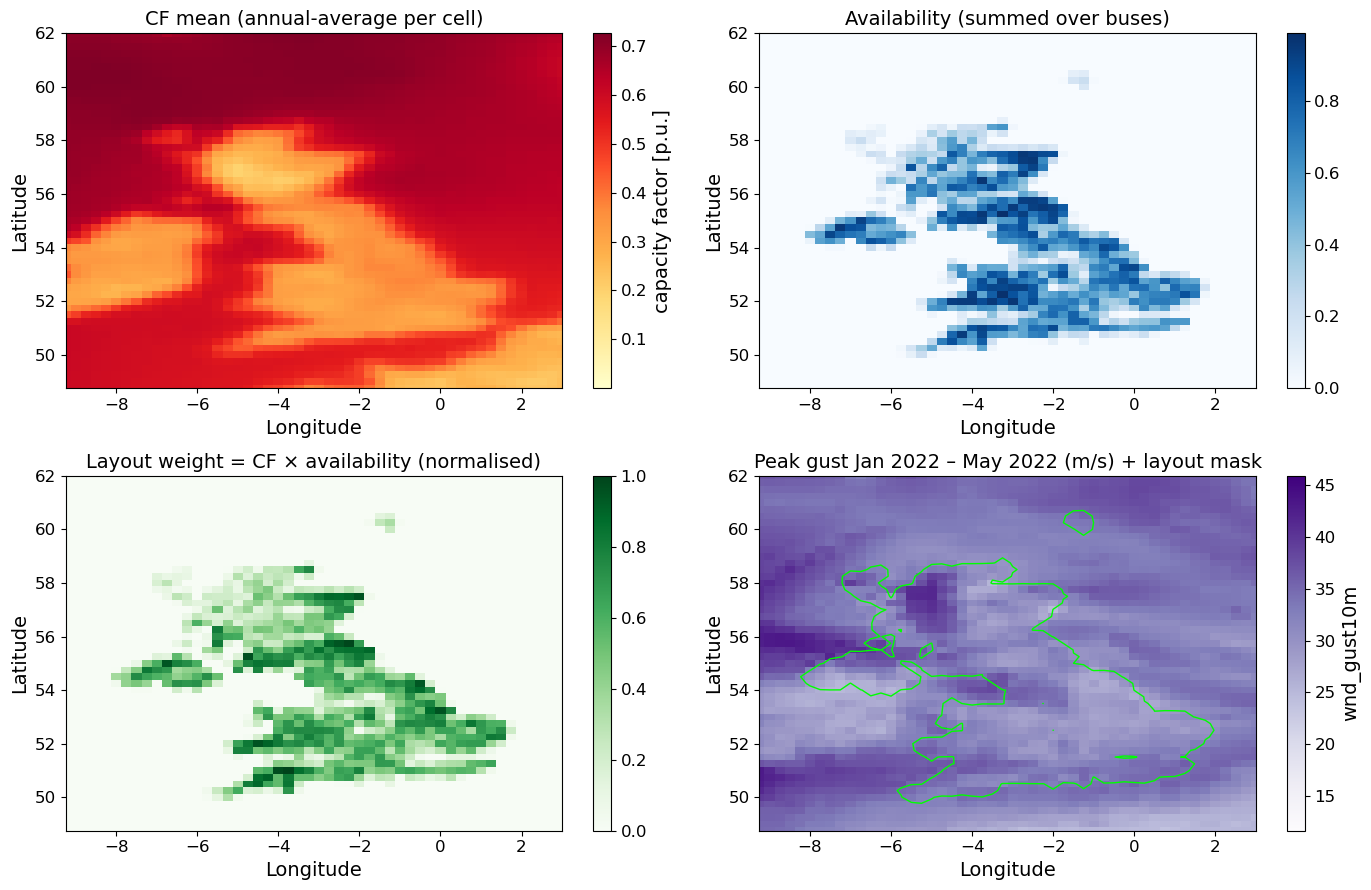

Spatial weighting check — offwind-ac, 5 clusters


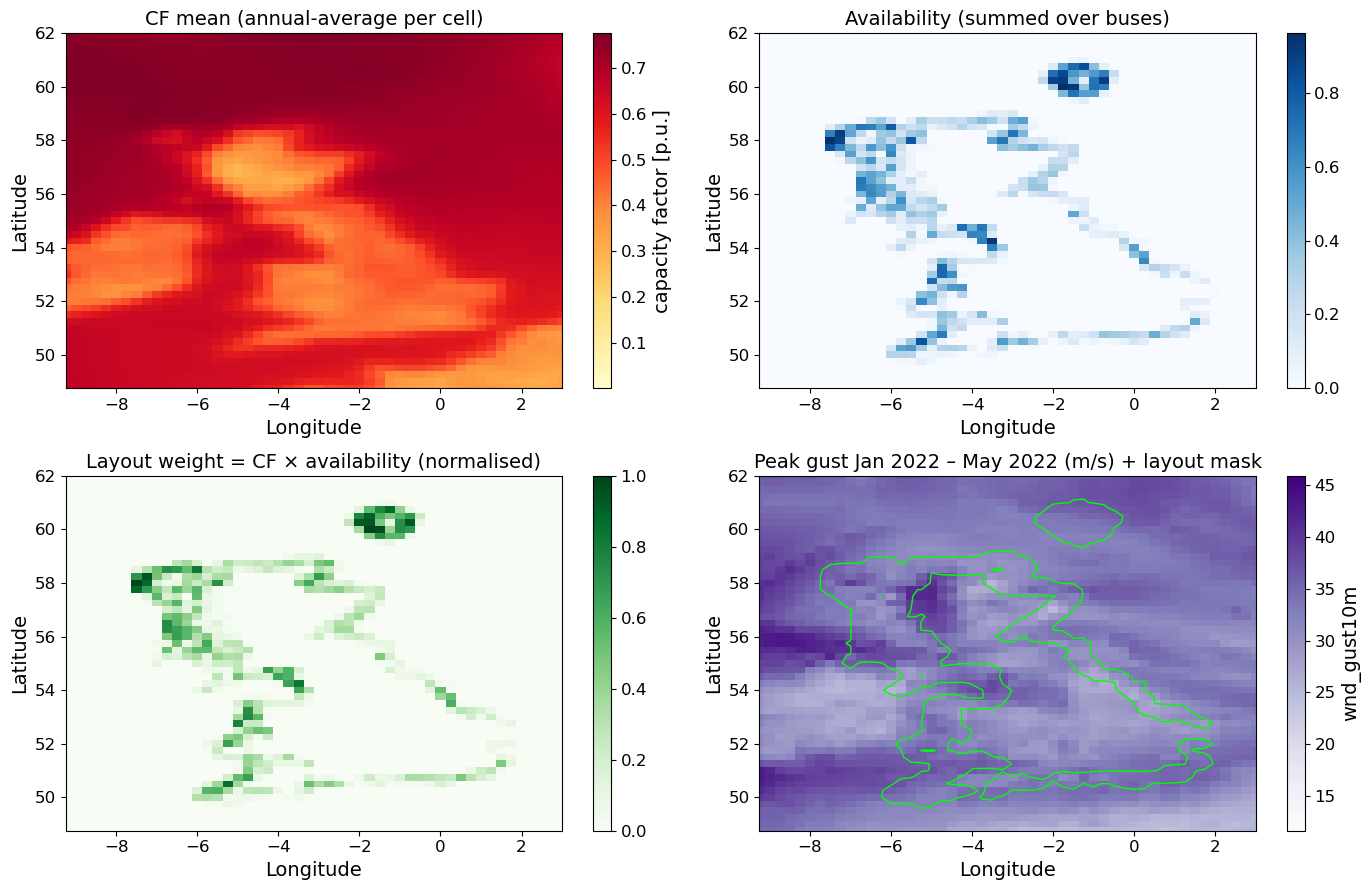

Spatial weighting check — offwind-dc, 5 clusters


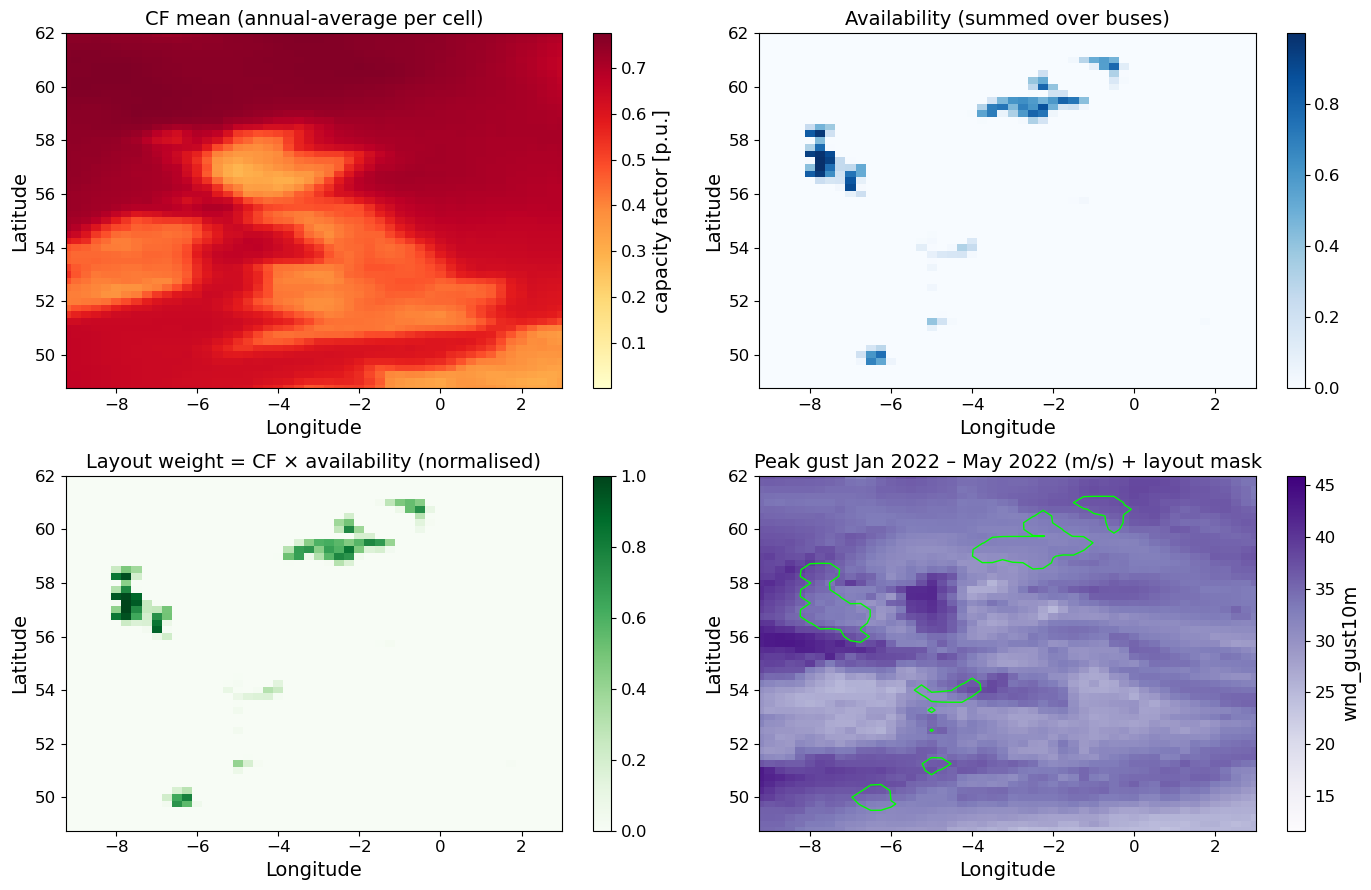

In [19]:
area       = cutout_y2.area(crs=3035) / 1e6
peak_gust  = V_p.sel(time=slice(f"{YEAR + 1}-01-01", SNAP_END)).max(dim="time")

# Pass 1: collect per-carrier bounds
lon_mins, lon_maxs, lat_mins, lat_maxs = [], [], [], []
for avail_file, _ in CARRIERS.values():
    avail = xr.open_dataarray(SCENARIO_DIR / avail_file)
    has_avail = avail.sum(dim="bus") > 0
    x_act = avail.x.where(has_avail.any(dim="y"), drop=True)
    y_act = avail.y.where(has_avail.any(dim="x"), drop=True)
    lon_mins.append(float(x_act.min()) - 1)
    lon_maxs.append(float(x_act.max()) + 1)
    lat_mins.append(float(y_act.min()) - 1)
    lat_maxs.append(float(y_act.max()) + 1)

lon_min, lon_max = min(lon_mins), max(lon_maxs)
lat_min, lat_max = min(lat_mins), max(lat_maxs)

# Pass 2: plot
for carrier, (avail_file, turbine) in CARRIERS.items():
    CF_mean       = cutout_y2.wind(turbine=turbine, capacity_factor=True)
    availability  = xr.open_dataarray(SCENARIO_DIR / avail_file)
    avail_total   = availability.sum(dim="bus")
    layout_weight = CF_mean * area * avail_total
    layout_weight = layout_weight / layout_weight.max()

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    CF_mean.plot(ax=axes[0, 0], cmap="YlOrRd", add_colorbar=True)
    axes[0, 0].set_title("CF mean (annual-average per cell)")

    avail_total.plot(ax=axes[0, 1], cmap="Blues", add_colorbar=True)
    axes[0, 1].set_title("Availability (summed over buses)")

    layout_weight.plot(ax=axes[1, 0], cmap="Greens", add_colorbar=True)
    axes[1, 0].set_title("Layout weight = CF × availability (normalised)")

    peak_gust.plot(ax=axes[1, 1], cmap="Purples", add_colorbar=True)
    axes[1, 1].contour(
        layout_weight.x.values,
        layout_weight.y.values,
        layout_weight.values,
        levels=[0.03],          # outline cells with non-negligible layout weight
        colors="lime",
        linewidths=1.0,
    )
    axes[1, 1].set_title(f"Peak gust Jan {YEAR + 1} – May {YEAR + 1} (m/s) + layout mask")


    for ax in axes.flat:
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
    print(f"Spatial weighting check — {carrier}, {CLUSTERS} clusters")
    #plt.suptitle(f"Spatial weighting check — {carrier}, {CLUSTERS} clusters", y=1.01)
    plt.tight_layout()
    plt.show()


## Bus-level validation


Wind damage vs renewable CF — GB0 2


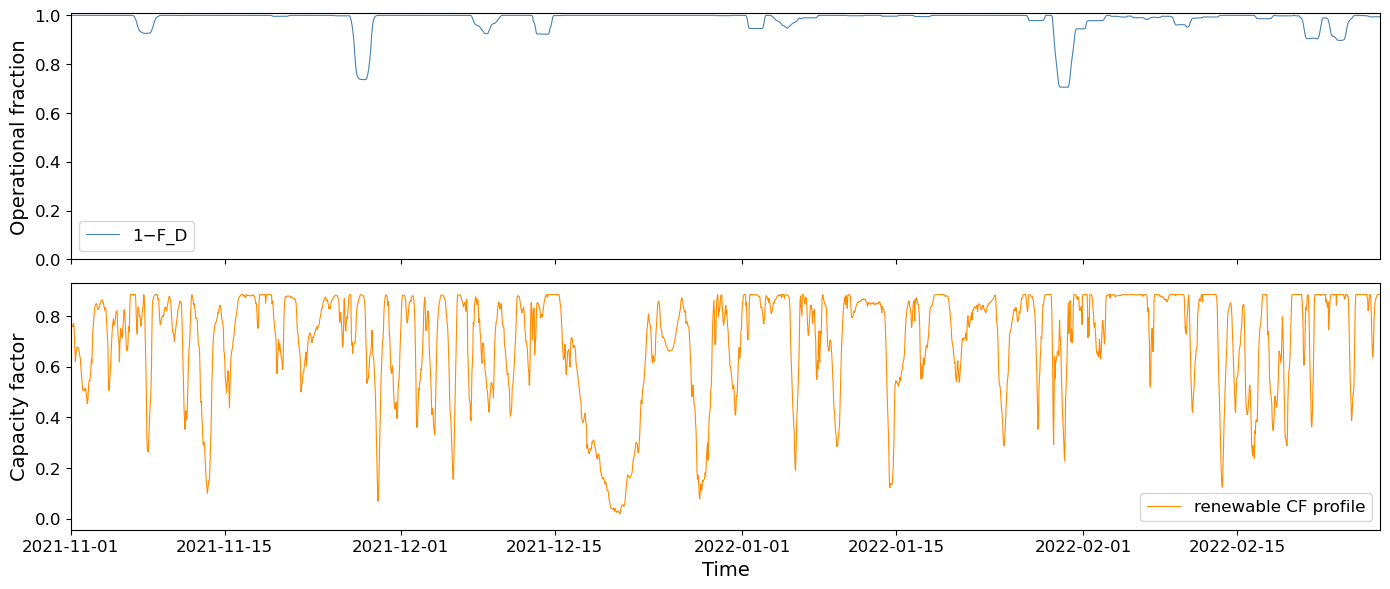

In [12]:
## 8. Plot — damage events vs renewable CF profile
CARRIER = "offwind-ac"
# onwind | offwind-ac | offwind-dc | offwind-float
BUS = "GB0 2"

_avail_file, TURBINE_NAME = CARRIERS[CARRIER]
AVAIL_PATH   = SCENARIO_DIR / _avail_file
PROFILE_PATH = SCENARIO_DIR / f"profile_5_{CARRIER}.nc"
DMG_PATH     = SCENARIO_DIR / "damage_profiles" / f"{CARRIER}_damage_5.nc"

op_existing = 1 - xr.open_dataset(DMG_PATH)["profile"]
cf_profile  = xr.open_dataset(PROFILE_PATH)["profile"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
date_range = ("2021-11-01", "2022-02-28")

axes[0].set_xlim(pd.Timestamp(date_range[0]), pd.Timestamp(date_range[1]))

axes[0].plot(op_existing.time.values, op_existing.sel(bus=BUS).values,
             color="steelblue", linewidth=0.8, label="1\u2212F_D")
axes[0].set_ylabel("Operational fraction")
axes[0].set_ylim(0.0, 1.01)
axes[0].legend()
# axes[0].set_title(f"Wind damage vs renewable CF \u2014 {BUS}")
print(f"Wind damage vs renewable CF \u2014 {BUS}")
axes[1].plot(cf_profile.time.values, cf_profile.sel(bus=BUS).squeeze().values,
             color="darkorange", linewidth=0.8, label="renewable CF profile")

axes[1].set_ylabel("Capacity factor")
axes[1].set_xlabel("Time")
axes[1].legend()

plt.tight_layout()
plt.show()

Wind damage vs renewable CF — GB0 1


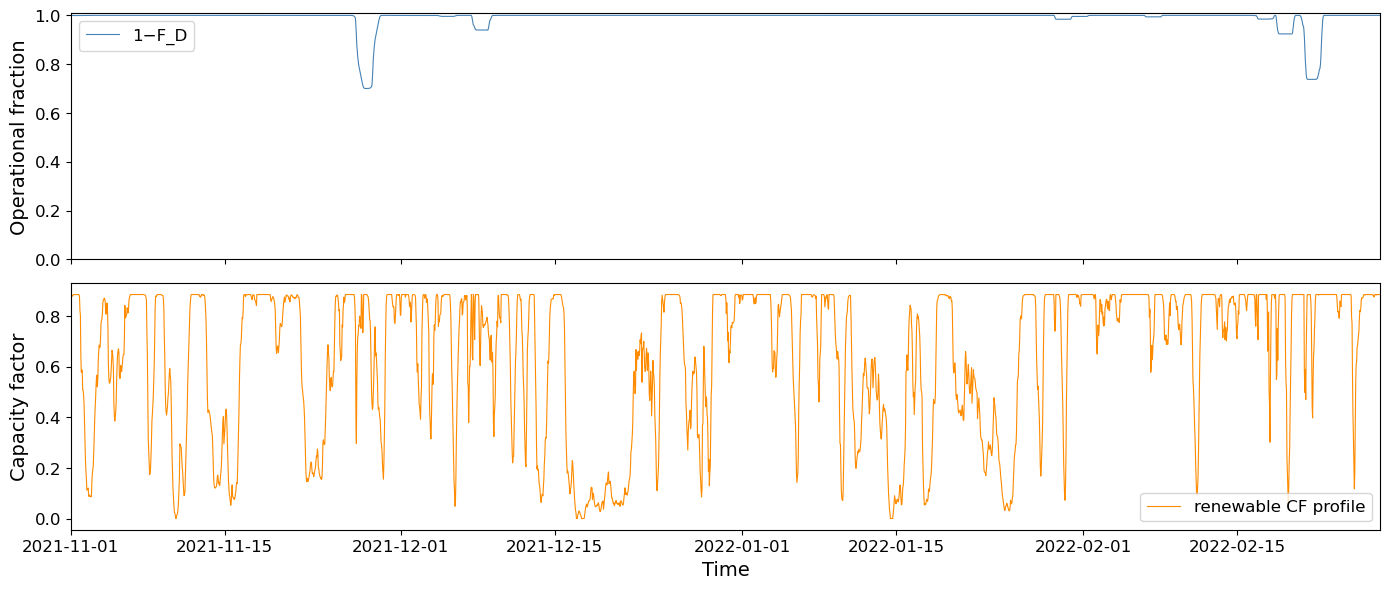

In [15]:
## 8. Plot — damage events vs renewable CF profile
CARRIER = "offwind-ac"
# onwind | offwind-ac | offwind-dc | offwind-float
BUS = "GB0 1"

_avail_file, TURBINE_NAME = CARRIERS[CARRIER]
AVAIL_PATH   = SCENARIO_DIR / _avail_file
PROFILE_PATH = SCENARIO_DIR / f"profile_5_{CARRIER}.nc"
DMG_PATH     = SCENARIO_DIR / "damage_profiles" / f"{CARRIER}_damage_5.nc"

op_existing = 1 - xr.open_dataset(DMG_PATH)["profile"]
cf_profile  = xr.open_dataset(PROFILE_PATH)["profile"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)


date_range = ("2021-11-01", "2022-02-28")
axes[0].set_xlim(pd.Timestamp(date_range[0]), pd.Timestamp(date_range[1]))

axes[0].plot(op_existing.time.values, op_existing.sel(bus=BUS).values,
             color="steelblue", linewidth=0.8, label="1\u2212F_D")
axes[0].set_ylabel("Operational fraction")
axes[0].set_ylim(0.0, 1.01)
axes[0].legend()
# axes[0].set_title(f"Wind damage vs renewable CF \u2014 {BUS}")
print(f"Wind damage vs renewable CF \u2014 {BUS}")
axes[1].plot(cf_profile.time.values, cf_profile.sel(bus=BUS).squeeze().values,
             color="darkorange", linewidth=0.8, label="renewable CF profile")

axes[1].set_ylabel("Capacity factor")
axes[1].set_xlabel("Time")
axes[1].legend()

plt.tight_layout()
plt.show()


Wind damage vs renewable CF — GB0 2


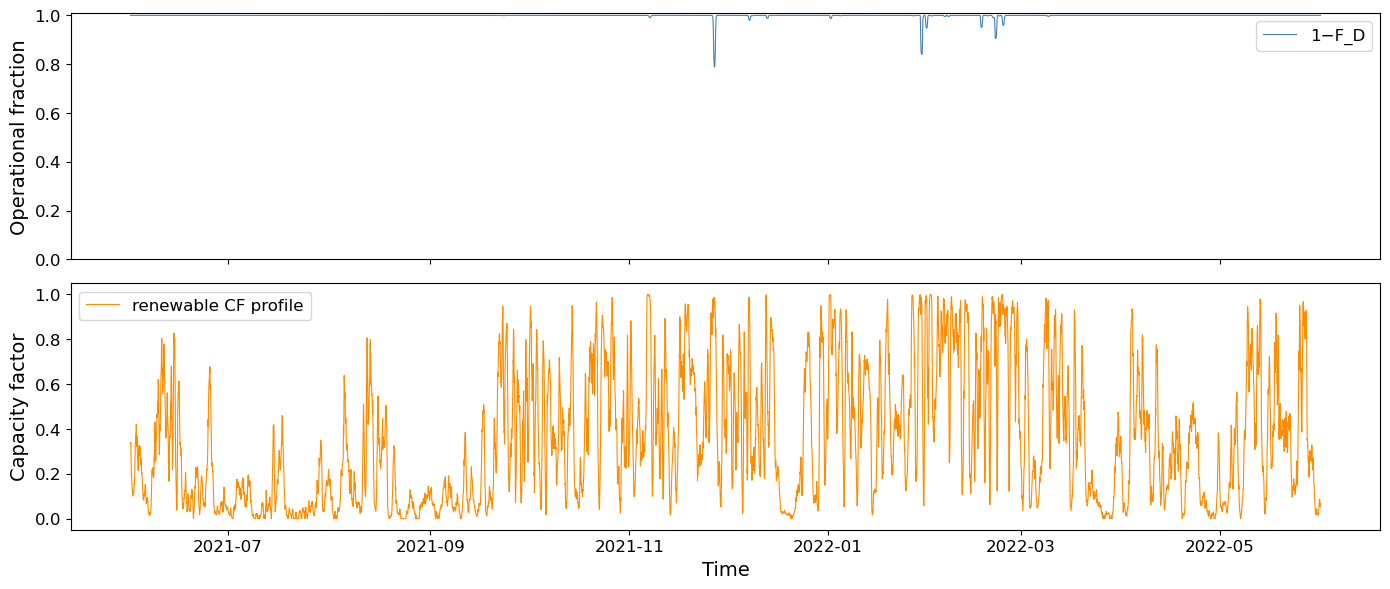

In [12]:
## 8. Plot — damage events vs renewable CF profile
CARRIER = "onwind"
# onwind | offwind-ac | offwind-dc | offwind-float
BUS = "GB0 2"

_avail_file, TURBINE_NAME = CARRIERS[CARRIER]
AVAIL_PATH   = SCENARIO_DIR / _avail_file
PROFILE_PATH = SCENARIO_DIR / f"profile_5_{CARRIER}.nc"
DMG_PATH     = SCENARIO_DIR / "damage_profiles" / f"{CARRIER}_damage_5.nc"

op_existing = 1 - xr.open_dataset(DMG_PATH)["profile"]
cf_profile  = xr.open_dataset(PROFILE_PATH)["profile"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(op_existing.time.values, op_existing.sel(bus=BUS).values,
             color="steelblue", linewidth=0.8, label="1\u2212F_D")
axes[0].set_ylabel("Operational fraction")
axes[0].set_ylim(0.0, 1.01)
axes[0].legend()
# axes[0].set_title(f"Wind damage vs renewable CF \u2014 {BUS}")
print(f"Wind damage vs renewable CF \u2014 {BUS}")
axes[1].plot(cf_profile.time.values, cf_profile.sel(bus=BUS).squeeze().values,
             color="darkorange", linewidth=0.8, label="renewable CF profile")

axes[1].set_ylabel("Capacity factor")
axes[1].set_xlabel("Time")
axes[1].legend()

plt.tight_layout()
plt.show()


## Cell-level validation


In [ ]:
def plot_bus_wind_sample(carrier: str, bus: str, n_cells: int = 5) -> None:
    avail_file, turbine = CARRIERS[carrier]
    avail_path   = SCENARIO_DIR / avail_file
    profile_path = SCENARIO_DIR / f"profile_5_{carrier}.nc"

    time_window = slice(f"{YEAR + 1}-01-01", f"{YEAR + 1}-01-07")
    ds          = cutout_y2.data.sel(time=time_window)

    availability = xr.open_dataarray(avail_path)
    avail_bus    = availability.sel(bus=bus)

    # Top n_cells cells by availability weight
    avail_arr = avail_bus.values
    flat      = avail_arr.flatten()
    top_idx   = [i for i in np.argsort(flat)[::-1] if flat[i] > 0][:n_cells]
    cells = [
        (float(avail_bus.y.values[i // avail_arr.shape[1]]),
         float(avail_bus.x.values[i  % avail_arr.shape[1]]))
        for i in top_idx
    ]

    turbine_cfg = get_windturbineconfig(turbine, add_cutout_windspeed=True)
    hub_height  = turbine_cfg["hub_height"]
    V           = np.array(turbine_cfg["V"])
    cf_values   = np.array(turbine_cfg["POW"]) / float(turbine_cfg["P"])

    cf_profile = xr.open_dataset(profile_path)["profile"].sel(bus=bus, time=time_window).squeeze()
    time_vals  = ds.time.values

    fig, axes = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

    for y_c, x_c in cells:
        label     = f"y={y_c:.2f}, x={x_c:.2f}"
        wnd100m   = ds["wnd100m"].sel(y=y_c, x=x_c, method="nearest")
        roughness = ds["roughness"].sel(y=y_c, x=x_c, method="nearest")
        wnd_hub   = wnd100m * np.log(hub_height / roughness) / np.log(100.0 / roughness)
        CF_cell   = np.interp(wnd_hub.values, V, cf_values)
        axes[0].plot(time_vals, wnd_hub.values, linewidth=0.8, label=label, alpha=0.8)
        axes[1].plot(time_vals, CF_cell,        linewidth=0.8, label=label, alpha=0.8)

    axes[0].axhline(25, color="red", linestyle="--", linewidth=1, label="cut-out 25 m/s")
    axes[0].set_ylabel("Hub-height wind (m/s)")
    axes[0].legend(fontsize=12, loc="lower left")

    axes[1].set_ylabel("Capacity factor")
    axes[1].set_ylim(0.0, 1.01)
    axes[1].legend(fontsize=12, loc="lower left")

    axes[2].plot(cf_profile.time.values, cf_profile.values,
                 color="darkorange", linewidth=0.8, label=f"bus CF ({bus})")
    axes[2].set_ylabel("Bus CF profile")
    axes[2].set_ylim(0.0, 1.01)
    axes[2].set_xlabel("Time")
    axes[2].legend(fontsize=12, loc="lower left")


    fig.suptitle(f"{carrier} — bus {bus}, top {n_cells} cells by availability weight")
    plt.tight_layout()
    plt.show()


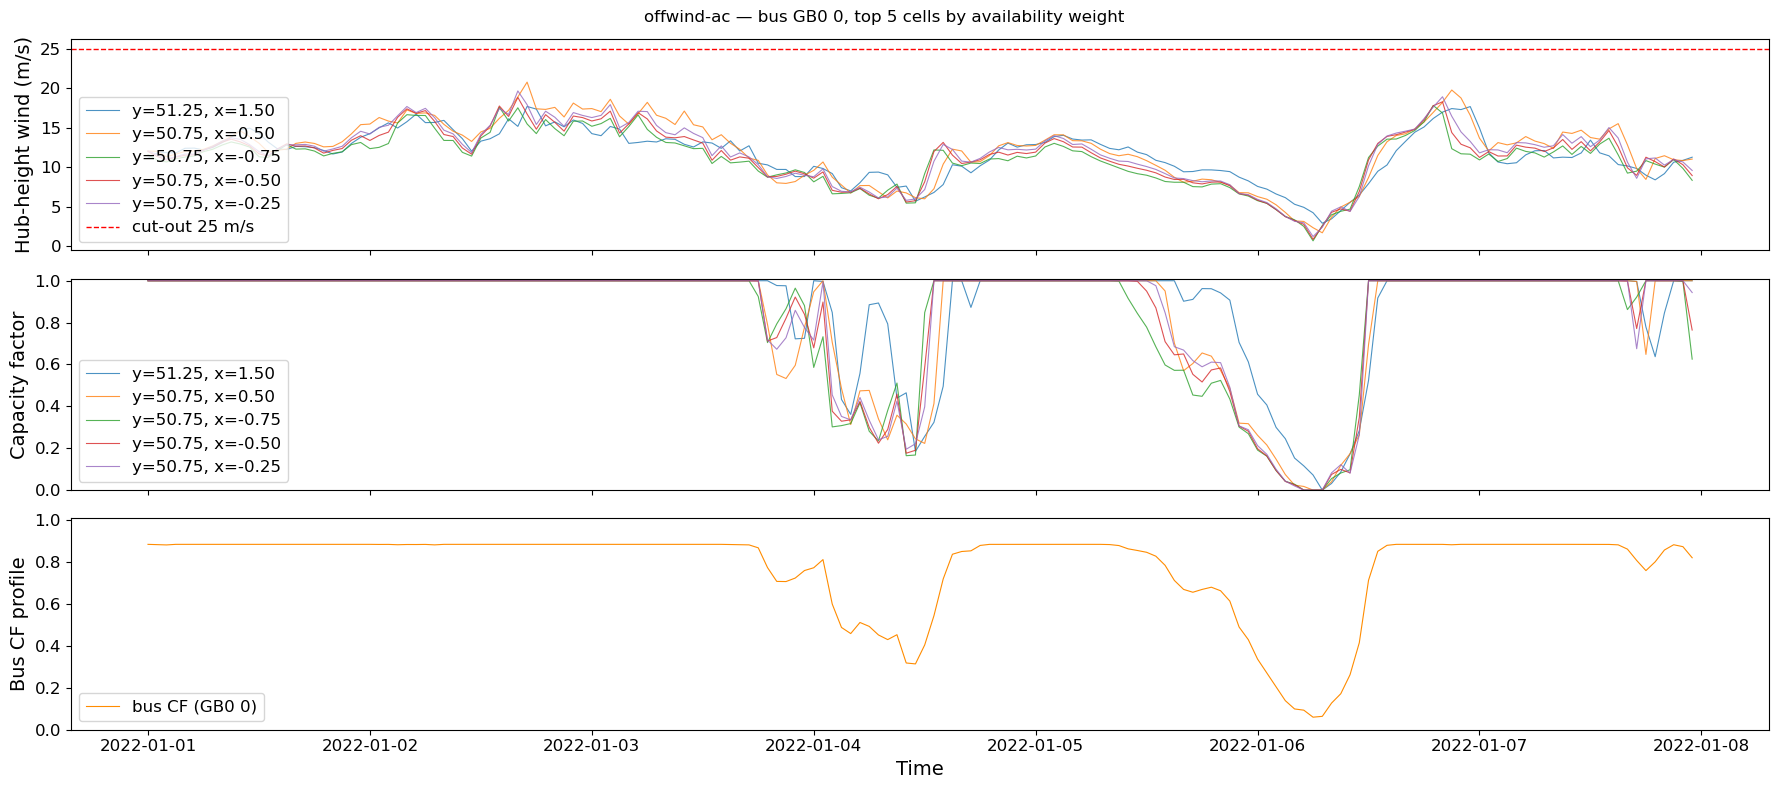

In [122]:
plot_bus_wind_sample("offwind-ac", "GB0 0")


In [32]:
def plot_cell_validation(carrier: str, bus: str) -> None:
    avail_file, turbine = CARRIERS[carrier]
    avail_path   = SCENARIO_DIR / avail_file
    profile_path = SCENARIO_DIR / f"profile_5_{carrier}.nc"
    dmg_path     = SCENARIO_DIR / "damage_profiles" / f"{carrier}_damage_{CLUSTERS}.nc"

    time_window = slice(f"{YEAR + 1}-01-01", f"{YEAR + 1}-02-28")
    ds          = cutout_y2.data.sel(time=time_window)

    availability   = xr.open_dataarray(avail_path)
    avail_mask     = availability.sel(bus=bus) > 0
    V_p_max_masked = ds["wnd_gust10m"].max(dim="time").where(avail_mask)
    arr            = V_p_max_masked.values
    iy, ix         = np.unravel_index(np.nanargmax(arr), arr.shape)
    best_y         = float(V_p_max_masked.y.values[iy])
    best_x         = float(V_p_max_masked.x.values[ix])
    print(f"Highest-gust {carrier} cell: y={best_y}, x={best_x}, peak gust: {arr[iy, ix]:.2f} m/s")

    avail_at_cell = availability.sel(bus=bus).sel(y=best_y, x=best_x, method="nearest")
    print(f"Bus: {bus}  (availability weight at best cell: {float(avail_at_cell):.4f})")

    turbine_cfg = get_windturbineconfig(turbine, add_cutout_windspeed=True)
    hub_height  = turbine_cfg["hub_height"]
    V           = np.array(turbine_cfg["V"])
    cf_values   = np.array(turbine_cfg["POW"]) / float(turbine_cfg["P"])

    wnd100m   = ds["wnd100m"].sel(y=best_y, x=best_x)
    roughness = ds["roughness"].sel(y=best_y, x=best_x)
    wnd_hub   = wnd100m * np.log(hub_height / roughness) / np.log(100.0 / roughness)
    CF_cell   = np.interp(wnd_hub.values, V, cf_values)
    V_p_cell  = ds["wnd_gust10m"].sel(y=best_y, x=best_x)
    F_D_cell  = compute_wind_damage(V_p_cell).values
    time_vals = ds.time.values

    op_existing = 1 - xr.open_dataset(dmg_path)["profile"].sel(bus=bus, time=time_window)
    cf_profile  = xr.open_dataset(profile_path)["profile"].sel(bus=bus, time=time_window).squeeze()

    yellow = "#d4a800"

    fig, axes = plt.subplots(5, 1, figsize=(14, 13), sharex=True)

    axes[0].plot(time_vals, wnd_hub.values, color="steelblue", linewidth=0.8)
    axes[0].axhline(25, color="red", linestyle="--", linewidth=1, label="cut-out 25 m/s")
    axes[0].set_ylabel("")
    axes[0].text(0, 1.01, "Mean Wind speed (m/s)", transform=axes[0].transAxes, ha="left", va="bottom", fontsize=14)
    axes[0].legend(fontsize=12)

    axes[1].plot(time_vals, CF_cell, color=yellow, linewidth=0.8, label="cell CF")
    axes[1].plot(cf_profile.time.values, cf_profile.values,
                 color="steelblue", linewidth=0.8, linestyle="--", label=f"bus CF ({bus})")
    axes[1].set_ylabel("")
    axes[1].text(0, 1.01, "Capacity Profile", transform=axes[1].transAxes, ha="left", va="bottom", fontsize=14)
    axes[1].legend(fontsize=12)

    axes[2].plot(time_vals, V_p_cell.values, color="purple", linewidth=0.8)
    axes[2].axhline(25, color="red", linestyle="--", linewidth=1, label="damage onset (25 m/s)")
    axes[2].set_ylabel("")
    axes[2].text(0, 1.01, "Wind Gust (m/s)", transform=axes[2].transAxes, ha="left", va="bottom", fontsize=14)
    axes[2].legend(fontsize=12)

    axes[3].plot(time_vals, (1 - F_D_cell) * 100, color=yellow, linewidth=0.8, label="cell 1−F_D")
    axes[3].plot(op_existing.time.values, op_existing.values * 100,
                 color="steelblue", linewidth=0.8, linestyle="--", label=f"bus damage profile ({bus})")
    axes[3].set_ylabel("")
    axes[3].text(0, 1.01, "% Operational Capacity", transform=axes[3].transAxes, ha="left", va="bottom", fontsize=14)
    axes[3].set_ylim(0.0, 101)
    axes[3].legend(fontsize=12)

    cf_undamaged_bus = cf_profile.values
    cf_damaged_bus   = cf_profile.values * op_existing.values

    axes[4].plot(cf_profile.time.values, cf_undamaged_bus, color="steelblue", linewidth=0.8, label=f"bus CF (undamaged)")
    axes[4].plot(op_existing.time.values, cf_damaged_bus,  color="green",    linewidth=0.8, label=f"bus CF (damaged)")
    axes[4].set_ylabel("")
    axes[4].text(0, 1.01, "Capacity Profile", transform=axes[4].transAxes, ha="left", va="bottom", fontsize=14)
    axes[4].set_ylim(0.0, 1.01)
    axes[4].set_xlabel("Time")
    axes[4].legend(fontsize=12)

    # fig.suptitle(
    #     f"Cell-level validation — {carrier}, y={best_y}, x={best_x}  "
    #     f"(bus: {bus}), Jan–Feb {YEAR + 1}"
    # )
    print(
        f"Cell-level validation — {carrier}, y={best_y}, x={best_x}  "
         f"(bus: {bus}), Jan–Feb {YEAR + 1}"
         )
    plt.tight_layout()
    plt.show()


Highest-gust offwind-ac cell: y=57.75, x=-5.0, peak gust: 41.46 m/s
Bus: GB0 2  (availability weight at best cell: 0.0228)
Cell-level validation — offwind-ac, y=57.75, x=-5.0  (bus: GB0 2), Jan–Feb 2022


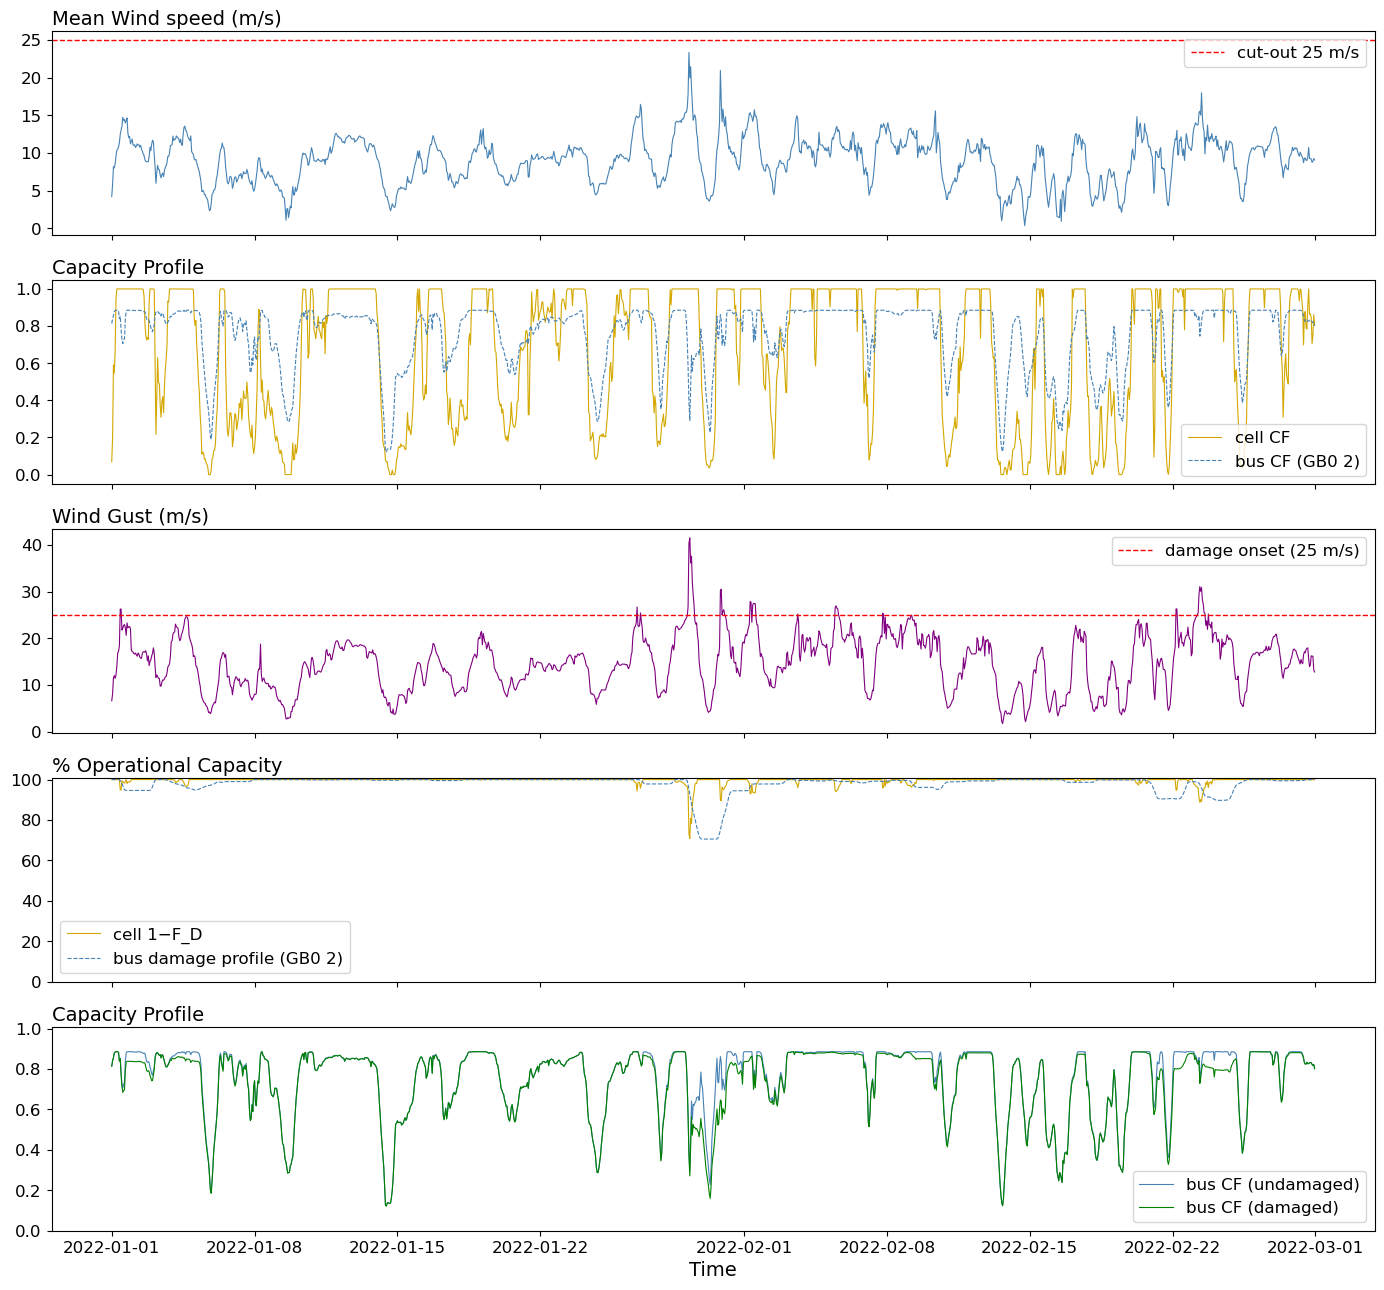

In [33]:
plot_cell_validation("offwind-ac", "GB0 2")

Highest-gust onwind cell: y=54.5, x=-3.25, peak gust: 37.23 m/s
Bus: GB0 1  (availability weight at best cell: 0.3296)


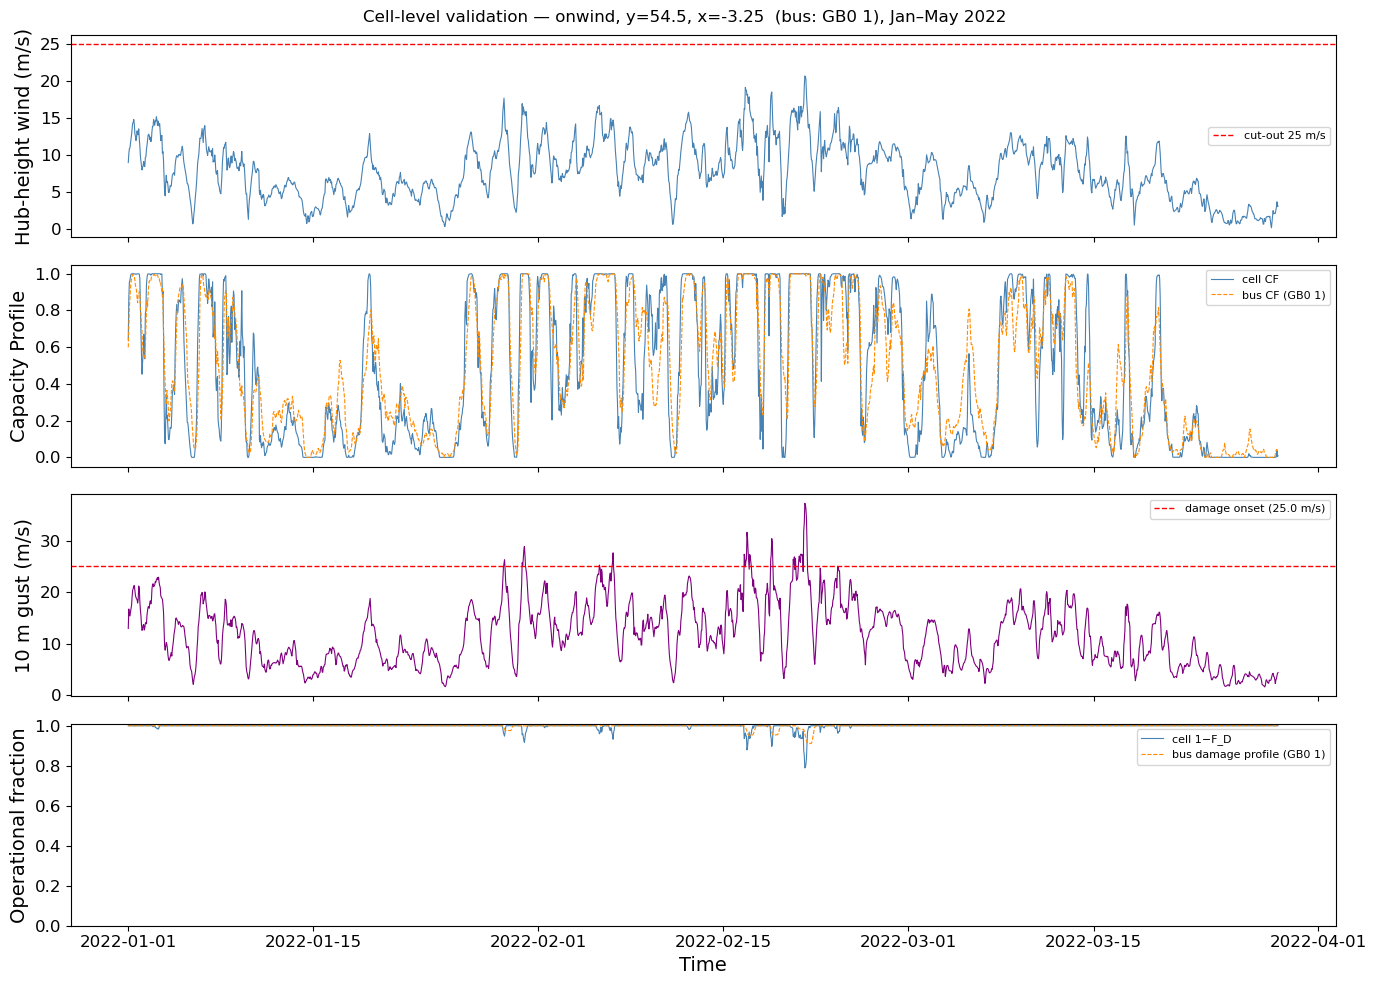

In [17]:
plot_cell_validation("onwind", "GB0 1")

In [55]:

time_window = slice("2021-06-01", "2022-05-31")  # adjust to your snapshot range
jan_mar = slice("2022-01-01", "2022-03-31")

rows = []
for carrier, (avail_file, _) in CARRIERS.items():
    dmg_path = SCENARIO_DIR / "damage_profiles" / f"{carrier}_damage_5.nc"
    if not dmg_path.exists():
        print(f"Missing: {dmg_path}")
        continue

    da = xr.open_dataset(dmg_path)["profile"].sel(time=time_window)

    # weekly sum per bus, then sum across buses
    df = da.to_pandas()                         # (time, bus)
    weekly = df.resample("W").sum()             # sum of F_D within each week
    weekly_total = weekly.sum(axis=1)           # sum across all buses

    for week, val in weekly_total.items():
        rows.append({"carrier": carrier, "week_start": week, "damage_sum": val})


summary = pd.DataFrame(rows).pivot(index="week_start", columns="carrier", values="damage_sum")
print(summary.to_string(float_format="{:.4f}".format))


carrier     offwind-ac  offwind-dc  onwind
week_start                                
2021-06-06      0.0000      0.0000  0.0000
2021-06-13      0.0000      0.0000  0.0000
2021-06-20      0.0000      0.0000  0.0000
2021-06-27      0.0000      0.0000  0.0000
2021-07-04      0.0000      0.0000  0.0000
2021-07-11      0.0008      0.0000  0.0000
2021-07-18      0.0000      0.0000  0.0000
2021-07-25      0.0000      0.0000  0.0000
2021-08-01      0.0727      3.0151  0.0013
2021-08-08      0.0000      0.0000  0.0000
2021-08-15      0.0000      0.0000  0.0000
2021-08-22      0.0000      0.0000  0.0000
2021-08-29      0.0000      0.0000  0.0000
2021-09-05      0.0000      0.0000  0.0000
2021-09-12      0.0000      0.0000  0.0000
2021-09-19      0.0000      0.0000  0.0000
2021-09-26      0.9053      1.2799  0.0205
2021-10-03      0.9432      1.6482  0.0506
2021-10-10      0.3910      0.6021  0.0045
2021-10-17      0.0000      0.0000  0.0000
2021-10-24      0.3077      0.6571  0.0031
2021-10-31 

/tmp/ipykernel_63119/1656929912.py:7: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



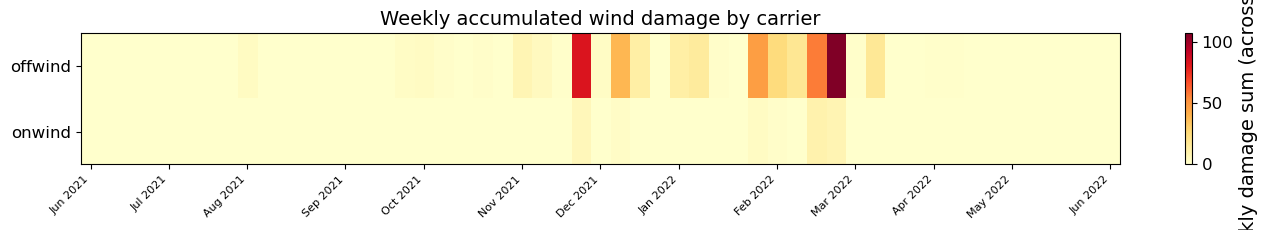

In [18]:


# Merge offwind variants into a single "offwind" row
CARRIER_GROUPS = {
    "offwind-ac": "offwind",
    "offwind-dc": "offwind",
    "offwind-float": "offwind",
}
summary_grouped = summary.rename(columns=CARRIER_GROUPS).groupby(level=0, axis=1).sum()

# Carriers as rows, weeks as columns
heat_data = summary_grouped.T  # (carrier, week)

fig, ax = im = plt.subplots(figsize=(14, len(heat_data) * 0.7 + 1))

im = ax.imshow(
    heat_data.values,
    aspect="auto",
    cmap="YlOrRd",
    interpolation="nearest",
)

# x-axis: monthly ticks
week_dates = heat_data.columns
month_starts = [i for i, d in enumerate(week_dates) if d.day <= 7]
ax.set_xticks(month_starts)
ax.set_xticklabels(
    [week_dates[i].strftime("%b %Y") for i in month_starts],
    rotation=45, ha="right", fontsize=8,
)

# y-axis: carrier names
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index)

plt.colorbar(im, ax=ax, label="Weekly damage sum (across buses)")
ax.set_title("Weekly accumulated wind damage by carrier")
fig.tight_layout()
plt.show()


## Network-level validation

In [9]:

from builders import build_cf_pmax_df, build_agg_cf_pmax_df
from plot_network import iplot_cf_pmax, plot_cf_pmax, iplot_agg_cf_pmax, plot_agg_cf_pmax
from plot_stats import plot_network_map


networks = {label: pypsa.Network(path) for label, path in NETWORK_PATHS.items()}

CARRIER = "offwind-ac"   # onwind | offwind-ac | offwind-dc | offwind-float
BUS     = "GB0 2"        # adjust to a valid GB bus

nc = pypsa.NetworkCollection(list(networks.values()), index=list(networks.keys()))

_color_overrides = {
    "load_shedding": "darkred",
    "oil":           "dimgray",
    "load":          "#4a4a4a",
}

for n in networks.values():
    # Rename the "" carrier to "load" everywhere
    if "" in n.carriers.index:
        n.carriers = n.carriers.rename(index={"": "load"})
        for attr in ["generators", "loads", "links","lines", "storage_units", "stores"]:
            df = getattr(n, attr)
            if not df.empty and "carrier" in df.columns:
                df.loc[df["carrier"] == "", "carrier"] = "load"

    for carrier, color in _color_overrides.items():
        if carrier in n.carriers.index:
            n.carriers.loc[carrier, "color"] = color

    remaining = n.carriers[n.carriers.color.isna() | n.carriers.color.eq("")].index
    n.carriers.loc[remaining, "color"] = "lightgrey"

color_map = networks["base_dis"].carriers.color.to_dict()


INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current:

In [15]:
n.statistics.withdrawal().filter(like="Load").sum()


np.float64(391812258.95335)

In [11]:
n = networks["dis"]
n.generators.groupby(["bus", "carrier"])["marginal_cost"].mean()


bus       carrier      
GB0 0     CCGT                45.315345
          biomass             15.848813
          load_shedding    10000.009388
          nuclear             14.033364
          offwind-ac           0.016000
          offwind-dc           0.019000
          onwind               0.013000
          solar                0.010000
          solar-hsat           0.015000
GB0 0 H2  load_shedding    10000.010447
GB0 1     CCGT                45.198985
          biomass             15.847577
          coal                30.118789
          load_shedding    10000.010145
          nuclear             14.032913
          offwind-ac           0.016000
          offwind-dc           0.019000
          onwind               0.013000
          solar                0.010000
          solar-hsat           0.015000
GB0 1 H2  load_shedding    10000.009032
GB0 2     CCGT                45.199311
          biomass             15.847186
          load_shedding    10000.009191
          nuclea

In [14]:
n = networks["base"]
n.generators.groupby(["bus", "carrier"])["marginal_cost"].mean()

bus    carrier   
GB0 0  CCGT          45.305499
       biomass       15.837851
       nuclear       14.022995
       offwind-ac     0.015000
       offwind-dc     0.017000
       onwind         0.022608
       solar          0.019241
       solar-hsat     0.020339
GB0 1  CCGT          45.189023
       biomass       15.837793
       coal          30.109102
       nuclear       14.022455
       offwind-ac     0.015000
       offwind-dc     0.017000
       onwind         0.022834
       solar          0.020653
       solar-hsat     0.020172
GB0 2  CCGT          45.189434
       biomass       15.838067
       nuclear       14.023259
       offwind-ac     0.015000
       offwind-dc     0.017000
       onwind         0.023363
       ror            0.009166
       solar          0.020206
       solar-hsat     0.020250
GB0 3  CCGT          45.349246
       biomass       15.837830
       coal          30.108693
       nuclear       14.024058
       offwind-ac     0.015000
       offwind-dc    

In [68]:
n.statistics.installed_capacity()

component    carrier             
Generator    Combined-Cycle Gas      3.612290e+04
             Offshore Wind (AC)      2.734902e+04
             Offshore Wind (DC)      1.129039e+04
             Onshore Wind            2.999992e+04
             Run of River            3.636175e+03
             Solar                   1.498082e+04
             biomass                 5.499998e+03
             coal                    1.419802e+04
             nuclear                 1.530600e+04
             solar-hsat              3.001918e+04
Line         AC                      4.474277e+04
Link         DC                      2.750000e+03
             H2 electrolysis         1.048180e+04
             H2 fuel cell            4.071723e+04
StorageUnit  Battery Storage         3.811117e+04
             Pumped Hydro Storage    4.400000e+02
             Reservoir & Dam         2.215000e+02
Store        Hydrogen Storage        9.746673e+06
dtype: float64

In [69]:
n.statistics.optimal_capacity()

component    carrier             
Generator    Combined-Cycle Gas      3.612290e+04
             Offshore Wind (AC)      2.734902e+04
             Offshore Wind (DC)      1.129039e+04
             Onshore Wind            2.999992e+04
             Run of River            3.636175e+03
             Solar                   1.498082e+04
             biomass                 5.499998e+03
             coal                    1.419802e+04
             load_shedding           1.671936e+03
             nuclear                 1.530600e+04
             solar-hsat              3.001918e+04
Line         AC                      4.474277e+04
Link         DC                      2.750000e+03
             H2 electrolysis         1.048180e+04
             H2 fuel cell            4.071723e+04
StorageUnit  Battery Storage         3.811117e+04
             Pumped Hydro Storage    4.400000e+02
             Reservoir & Dam         2.215000e+02
Store        Hydrogen Storage        9.746673e+06
dtype: float64

In [70]:
n = networks["base"]
eb = n.statistics.energy_balance(nice_names=False)
line_eb = eb[eb.index.get_level_values("component") == "Line"]
link_eb = eb[eb.index.get_level_values("component") == "Link"]
print(line_eb.describe())
print(link_eb.describe())


count    1.000000e+00
mean    -3.709391e+06
std               NaN
min     -3.709391e+06
25%     -3.709391e+06
50%     -3.709391e+06
75%     -3.709391e+06
max     -3.709391e+06
dtype: float64
count    4.000000e+00
mean    -7.600087e+06
std      3.812093e+07
min     -4.674819e+07
25%     -3.620881e+07
50%     -8.173921e+06
75%      2.043480e+07
max      3.269569e+07
dtype: float64


In [71]:
n = networks["base"]
eb = n.statistics.energy_balance(nice_names=False)
print(eb[eb.index.get_level_values("component").isin(["Line", "Link"])].isna().sum())


0


## P_max_pu and CF

In [49]:
ts = nc.statistics.capacity_factor(
    groupby=["bus", "carrier"], groupby_time=False, nice_names=False
)

data = build_cf_pmax_df(
    ts, networks,
    bus=BUS, carrier=CARRIER,
    start="2022-02-01", end="2022-02-24",
)

iplot_cf_pmax(data, title=f"CF vs p_max_pu — {CARRIER} @ {BUS}, February 2022")

CF vs p_max_pu — offwind-ac @ GB0 2, Jan - Feb 2022


(<Figure size 800x400 with 1 Axes>, <Axes: ylabel='p.u.'>)

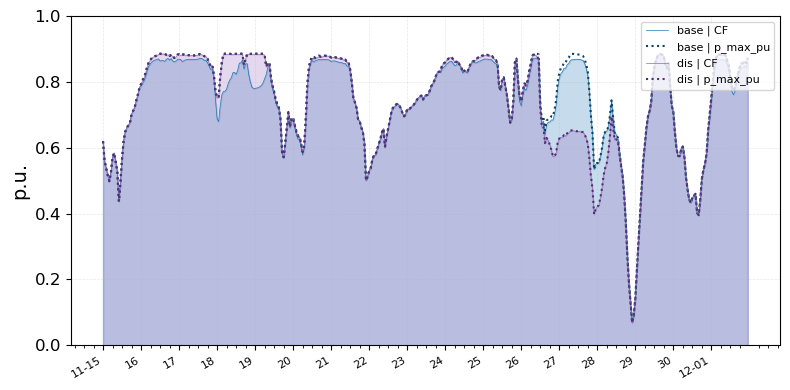

In [53]:
BUS = "GB0 2"
CARRIER = "offwind-ac"
ts = nc.statistics.capacity_factor(
    groupby=["bus", "carrier"], groupby_time=False, nice_names=False
)

data = build_cf_pmax_df(
    ts, {k: networks[k] for k in ["base", "dis"]},
    bus=BUS, carrier=CARRIER,
    start="2021-11-15", end="2021-12-01",
)

plot_cf_pmax(data, title=f"CF vs p_max_pu — {CARRIER} @ {BUS}, Jan - Feb 2022")

CF vs p_max_pu — offwind-dc @ GB0 2, Jan - Feb 2022


(<Figure size 800x400 with 1 Axes>, <Axes: ylabel='p.u.'>)

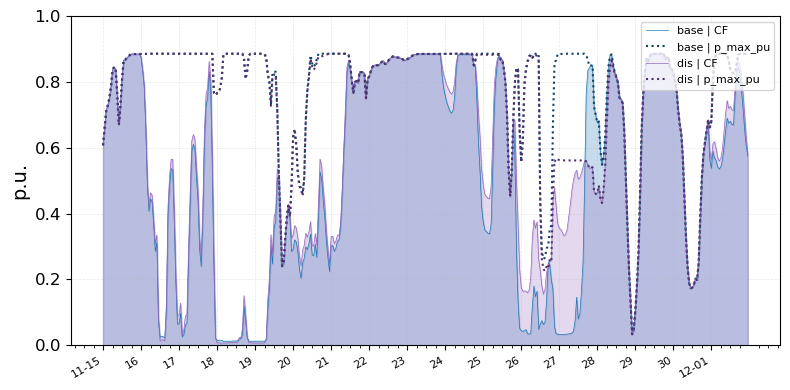

In [54]:
BUS = "GB0 2"
CARRIER = "offwind-dc"
ts = nc.statistics.capacity_factor(
    groupby=["bus", "carrier"], groupby_time=False, nice_names=False
)

data = build_cf_pmax_df(
    ts, {k: networks[k] for k in ["base", "dis"]},
    bus=BUS, carrier=CARRIER,
    start="2021-11-15", end="2021-12-01",
)

plot_cf_pmax(data, title=f"CF vs p_max_pu — {CARRIER} @ {BUS}, Jan - Feb 2022")

CF vs p_max_pu — onwind @ GB0 2, Jan - Feb 2022


(<Figure size 800x400 with 1 Axes>, <Axes: ylabel='p.u.'>)

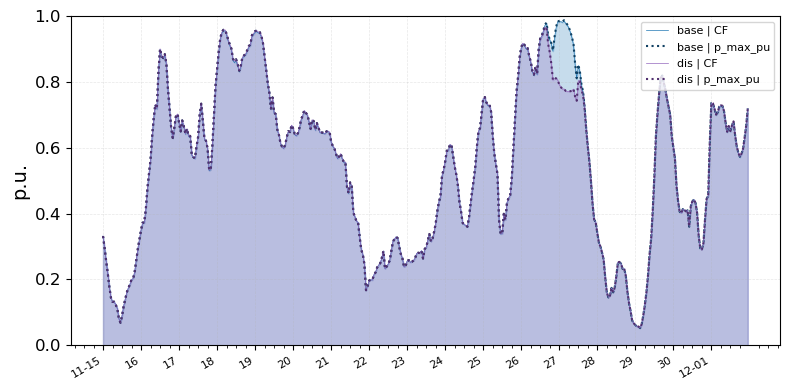

In [55]:
BUS = "GB0 2"
CARRIER = "onwind"
ts = nc.statistics.capacity_factor(
    groupby=["bus", "carrier"], groupby_time=False, nice_names=False
)

data = build_cf_pmax_df(
    ts, {k: networks[k] for k in ["base", "dis"]},
    bus=BUS, carrier=CARRIER,
    start="2021-11-15", end="2021-12-01",
)

plot_cf_pmax(data, title=f"CF vs p_max_pu — {CARRIER} @ {BUS}, Jan - Feb 2022")

CF vs p_max_pu — onwind @ GB1 0, Jan - Feb 2022


(<Figure size 800x400 with 1 Axes>, <Axes: ylabel='p.u.'>)

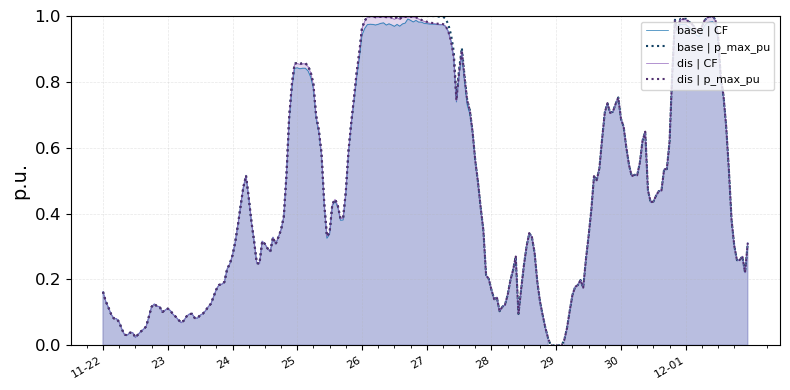

In [57]:
BUS = "GB1 0"
CARRIER = "onwind"
ts = nc.statistics.capacity_factor(
    groupby=["bus", "carrier"], groupby_time=False, nice_names=False
)

data = build_cf_pmax_df(
    ts, {k: networks[k] for k in ["base", "dis"]},
    bus=BUS, carrier=CARRIER,
    start="2021-11-22", end="2021-12-01",
)

plot_cf_pmax(data, title=f"CF vs p_max_pu — {CARRIER} @ {BUS}, Jan - Feb 2022")

In [53]:
BUS = "GB0 2"
CARRIER = "offwind-dc"
ts = nc.statistics.capacity_factor(
    groupby=["bus", "carrier"], groupby_time=False, nice_names=False
)

data = build_cf_pmax_df(
    ts, networks,
    bus=BUS, carrier=CARRIER,
    start="2022-01-25", end="2022-02-07",
)

iplot_cf_pmax(data, title=f"CF vs p_max_pu — {CARRIER} @ {BUS}, February 2022")

In [24]:
# monthly (default, same as before)
data = build_agg_cf_pmax_df(networks, carrier=CARRIER, bus=BUS)
iplot_agg_cf_pmax(data)

In [25]:
# weekly, January only
data = build_agg_cf_pmax_df(networks,bus= BUS, carrier=CARRIER, freq="W", start="2022-01-01", end="2022-02-28")
iplot_agg_cf_pmax(data, freq="W")

In [27]:
# single total bar for full period
data = build_agg_cf_pmax_df(networks, carrier=CARRIER, freq="total")
iplot_agg_cf_pmax(data, freq="total")

In [19]:
data

,base | CF,base | p_max_pu,cap | CF,cap | p_max_pu,dis | CF,dis | p_max_pu
2021-06-01,0.473239,0.505641,0.471492,0.503253,0.47592,0.503253


In [28]:
# Per-bus — ts from groupby=["bus", "carrier"]
CARRIER = "onwind"

# monthly (default, same as before)
data = build_agg_cf_pmax_df(networks, carrier=CARRIER, bus=BUS)
iplot_agg_cf_pmax(data)

In [21]:
data

,base | CF,base | p_max_pu,cap | CF,cap | p_max_pu,dis | CF,dis | p_max_pu
snapshot,,,,,,
2021-06-01,0.232044,0.232528,0.232010,0.232528,0.232264,0.232528
2021-07-01,0.084685,0.084914,0.084780,0.084914,0.084855,0.084914
2021-08-01,0.161079,0.161339,0.161029,0.161339,0.161149,0.161339
2021-09-01,0.234973,0.235300,0.234936,0.235286,0.235148,0.235286
2021-10-01,0.449564,0.450207,0.449452,0.450205,0.449801,0.450205
2021-11-01,0.500059,0.500410,0.495767,0.496189,0.495996,0.496189
2021-12-01,0.378678,0.378741,0.378166,0.378259,0.378250,0.378259
2022-01-01,0.539565,0.542340,0.535547,0.538565,0.538394,0.538565
2022-02-01,0.709972,0.711130,0.706020,0.707363,0.706568,0.707363


Monthly CF vs p_max_pu — onwind


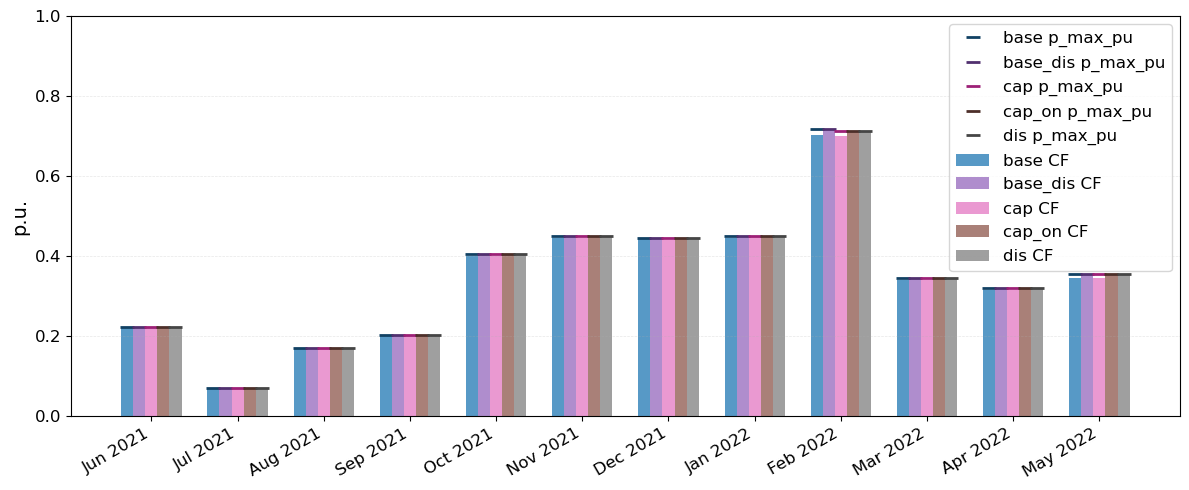

In [132]:
CARRIER = "onwind"
data = build_agg_cf_pmax_df(networks, carrier=CARRIER, bus=BUS)
# data = build_agg_cf_pmax_df(networks, carrier=CARRIER)

fig, ax = plot_agg_cf_pmax(data, title=f"Monthly CF vs p_max_pu — {CARRIER}")


In [33]:
BUS

'GB0 2'

Monthly CF vs p_max_pu — offwind-ac


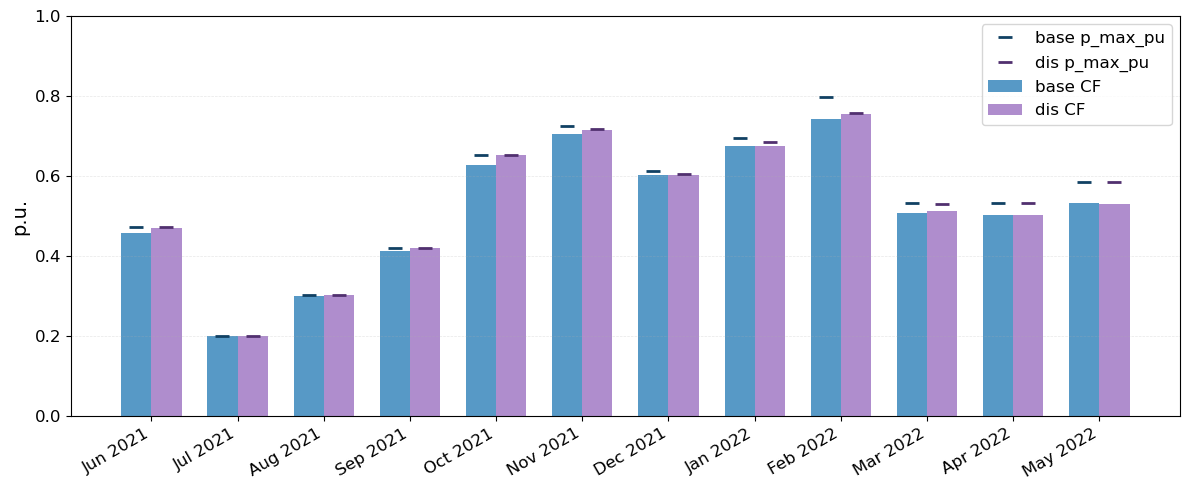

In [128]:
BUS = "GB1 0"
CARRIER = "offwind-ac"
data = build_agg_cf_pmax_df({k: networks[k] for k in ["base", "dis"]}, carrier=CARRIER, bus=BUS)

fig, ax = plot_agg_cf_pmax(data, title=f"Monthly CF vs p_max_pu — {CARRIER}")


Monthly CF vs p_max_pu — onwind


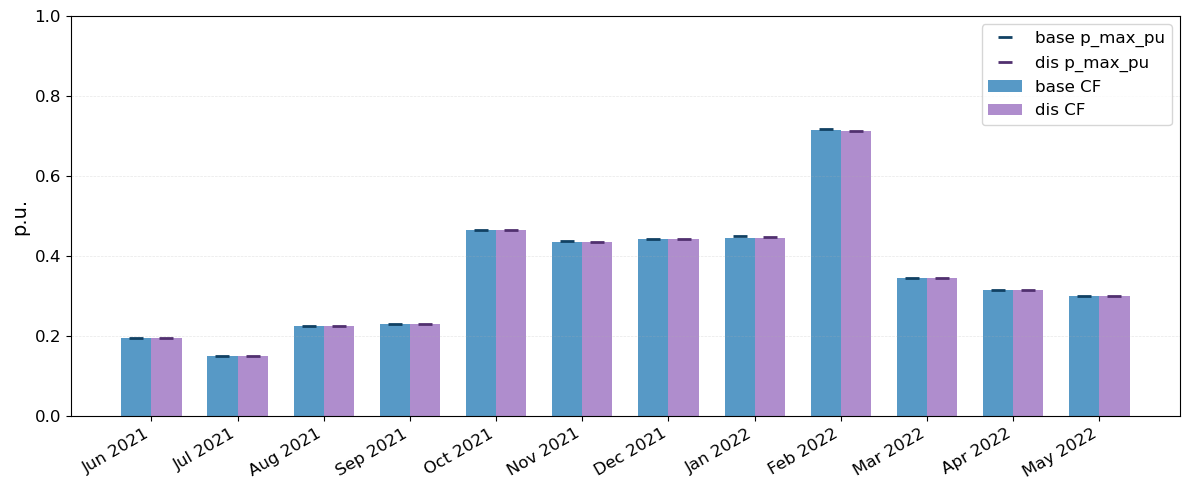

In [129]:
CARRIER = "onwind"
data = build_agg_cf_pmax_df({k: networks[k] for k in ["base", "dis"]}, carrier=CARRIER)

fig, ax = plot_agg_cf_pmax(data, title=f"Monthly CF vs p_max_pu — {CARRIER}")


Monthly CF vs p_max_pu — offwind-ac


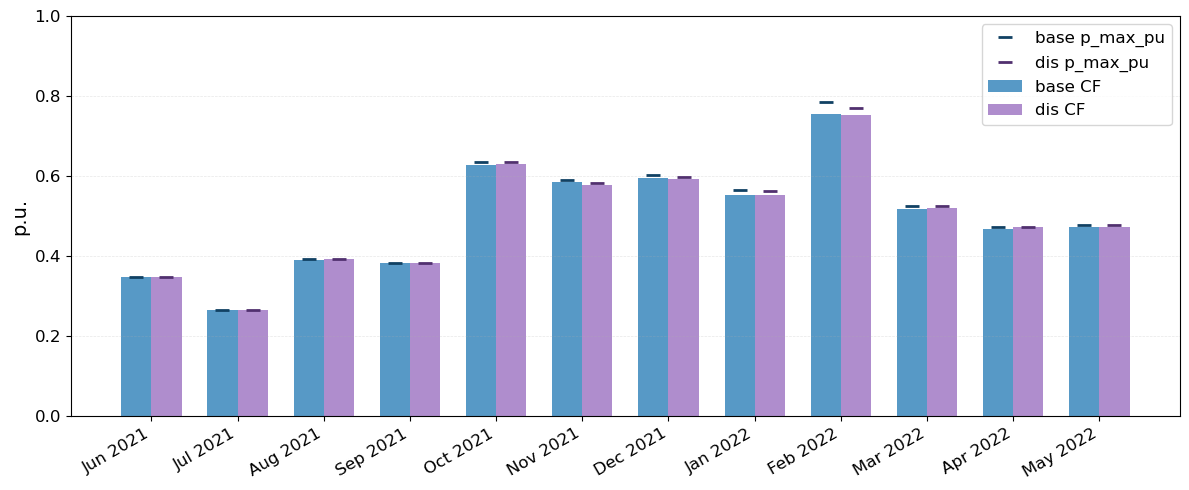

In [134]:
CARRIER = "offwind-ac"
data = build_agg_cf_pmax_df({k: networks[k] for k in ["base", "dis"]}, carrier=CARRIER)

fig, ax = plot_agg_cf_pmax(data, title=f"Monthly CF vs p_max_pu — {CARRIER}")


Monthly CF vs p_max_pu — offwind-dc


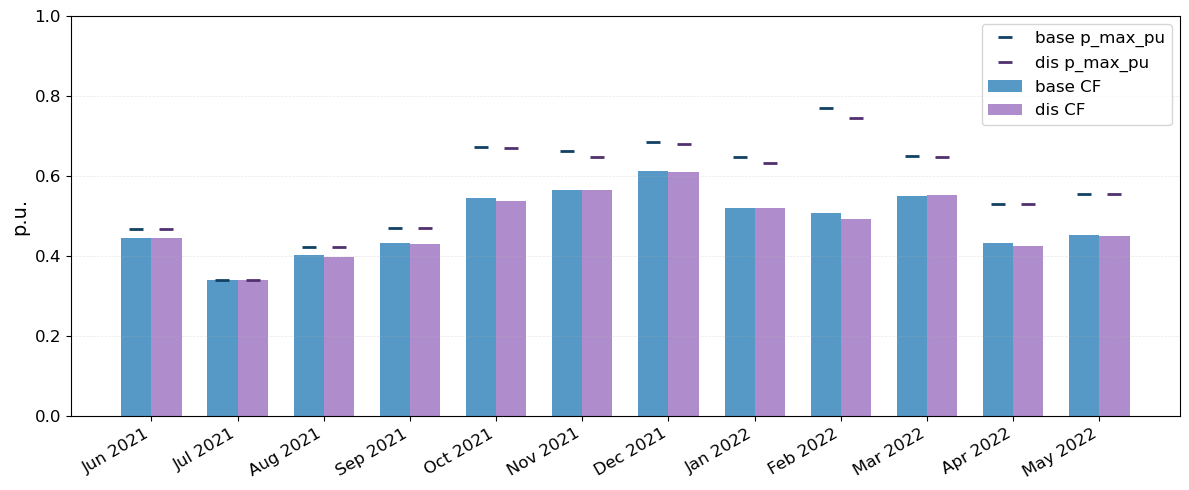

In [135]:
CARRIER = "offwind-dc"
data = build_agg_cf_pmax_df({k: networks[k] for k in ["base", "dis"]}, carrier=CARRIER)

fig, ax = plot_agg_cf_pmax(data, title=f"Monthly CF vs p_max_pu — {CARRIER}")


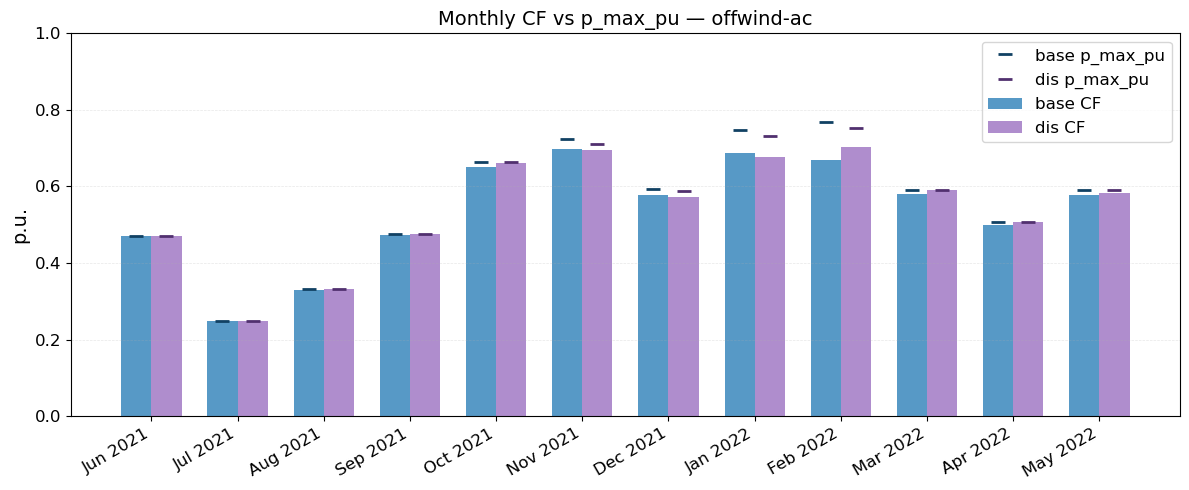

In [29]:
BUS = "GB0 2"
CARRIER = "offwind-ac"
data = build_agg_cf_pmax_df({k: networks[k] for k in ["base", "dis"]}, bus=BUS, carrier=CARRIER)

fig, ax = plot_agg_cf_pmax(data, title=f"Monthly CF vs p_max_pu — {CARRIER}")


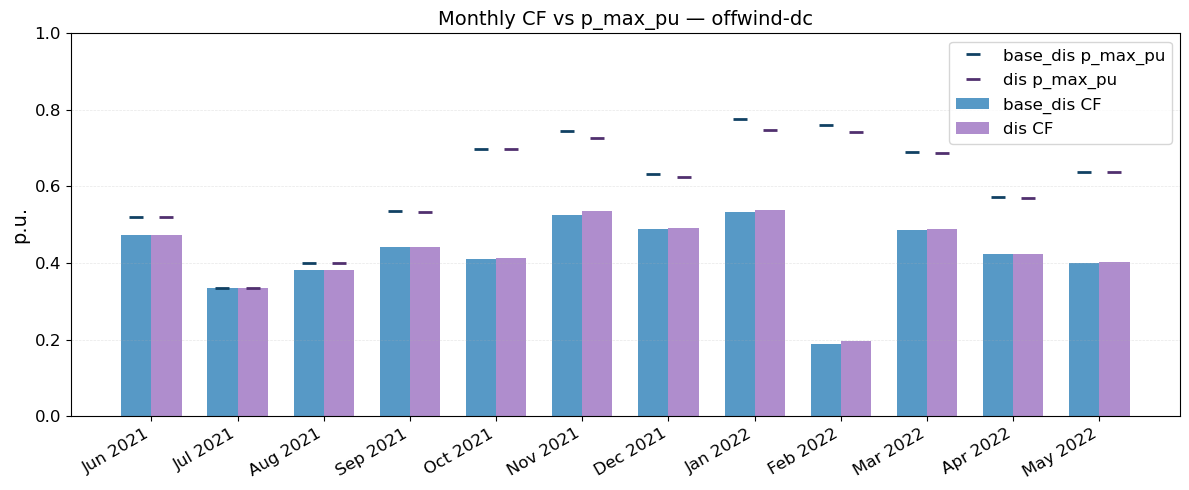

In [32]:
BUS = "GB0 2"
CARRIER = "offwind-dc"
data = build_agg_cf_pmax_df({k: networks[k] for k in ["base_dis", "dis"]}, bus=BUS, carrier=CARRIER)

fig, ax = plot_agg_cf_pmax(data, title=f"Monthly CF vs p_max_pu — {CARRIER}")


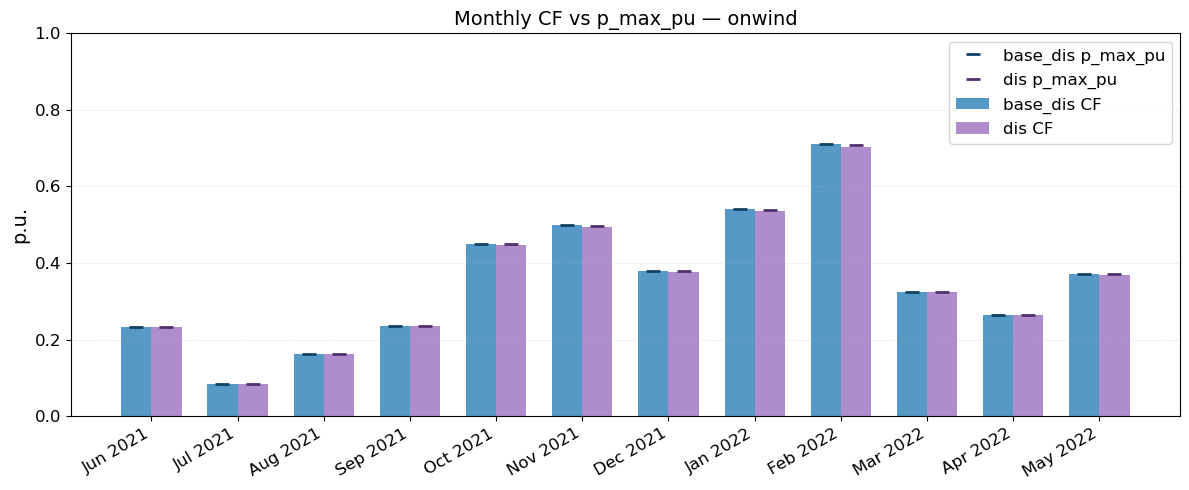

In [31]:
BUS = "GB0 2"
CARRIER = "onwind"
data = build_agg_cf_pmax_df({k: networks[k] for k in ["base_dis", "dis"]}, bus=BUS, carrier=CARRIER)

fig, ax = plot_agg_cf_pmax(data, title=f"Monthly CF vs p_max_pu — {CARRIER}")


## Statistics

## network flows map

In [11]:
def get_eb(n, components=("Generator", "Load", "StorageUnit")):
    return (
        n.statistics.energy_balance(
            groupby=["bus", "carrier"],
            components=list(components),
            nice_names=False,
        )
        .groupby(["bus", "carrier"])
        .sum()
    )

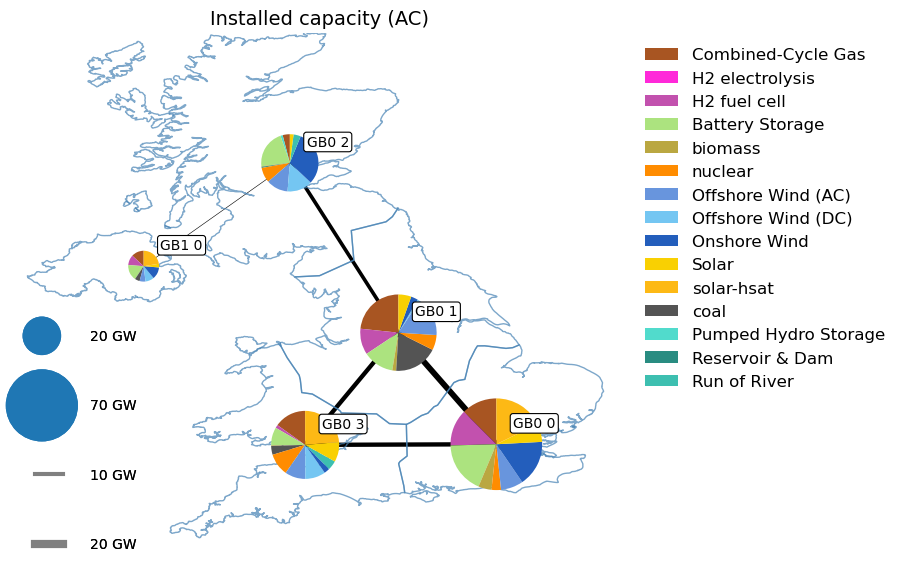

In [12]:
import geopandas as gpd
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
from pypsa.plot import add_legend_circles, add_legend_lines
from pypsa.plot.maps.static import HandlerCircle
from pypsa.geo import compute_bbox

regions = gpd.read_file(
    pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS["cap"] / "regions_onshore_base_s_5.geojson"
)

line_widths = (n.lines.s_nom / n.lines.s_nom.max() * 0.1).clip(lower=0.01)
link_widths = (n.links.p_nom / n.links.p_nom.max() * 0.1).clip(lower=0.01) if not n.links.empty else 0.0

fig, ax = plt.subplots(figsize=(8, 8))

bus_area_fraction = 0.05
n.statistics.installed_capacity.plot.map(
    bus_carrier="AC",
    title="Installed capacity (AC)",
    bus_area_fraction=bus_area_fraction,
    branch_area_fraction=0.09,
    draw_legend_circles=False,
    draw_legend_lines=False,
    geomap=False,
    line_width=line_widths,
    link_width=link_widths,
    ax=ax,
)

regions.boundary.plot(ax=ax, color="steelblue", linewidth=1.0, alpha=0.7)

ax.set_aspect("equal")

xl, yl = ax.get_xlim(), ax.get_ylim()
pad = 2
ax.set_xlim(xl[0] - pad, xl[1] + pad)
ax.set_ylim(yl[0] - pad, yl[1] + pad)

# ── Scaling factor ────────────────────────────────────────────────────────────
bus_size_mc = n.statistics.installed_capacity(
    bus_carrier="AC", groupby=["bus", "carrier"], nice_names=False
)
(x1, y1), (x2, y2) = compute_bbox(n.buses.x, n.buses.y, margin=0.05)
bbox_area = (x2 - x1) * (y2 - y1)
scaling_factor = bus_area_fraction * bbox_area / bus_size_mc.abs().sum()

# ── Bus labels ────────────────────────────────────────────────────────────────
ac_buses = n.buses[n.buses.carrier == "AC"]
for bus, row in ac_buses.iterrows():
    ax.annotate(
        bus,
        xy=(row.x, row.y),
        xytext=(12, 10), textcoords="offset points",
        fontsize=10, ha="left", va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="black", linewidth=0.8),
        zorder=10,
    )

# ── Combined legend ───────────────────────────────────────────────────────────
fig.canvas.draw()
pts_per_data = (
    ax.get_window_extent().width / fig.dpi * 72
    / (ax.get_xlim()[1] - ax.get_xlim()[0])
)

handles, labels = [], []

# Installed capacity (circles)
for v in [20000, 70000]:
    handles.append(Circle((0, 0), radius=(v * scaling_factor) ** 0.5))
    labels.append(f"{v/1000:.0f} GW")

# Section separator + line capacity
# handles.append(Line2D([], [], linestyle="none"))
# labels.append("Line capacity")
for v in [10000, 20000]:
    handles.append(Line2D([0], [0], linewidth=v / n.lines.s_nom.max() * 0.1 * pts_per_data, color="gray"))
    labels.append(f"{v/1000:.0f} GW")

leg = ax.legend(
    handles, labels,
    handler_map={Circle: HandlerCircle()},
    bbox_to_anchor=(0.02, 0.02),
    loc="lower left", frameon=False, fontsize=10,
    labelspacing=4, handletextpad=2,
)
fig.add_artist(leg)


Installed capacity (AC)


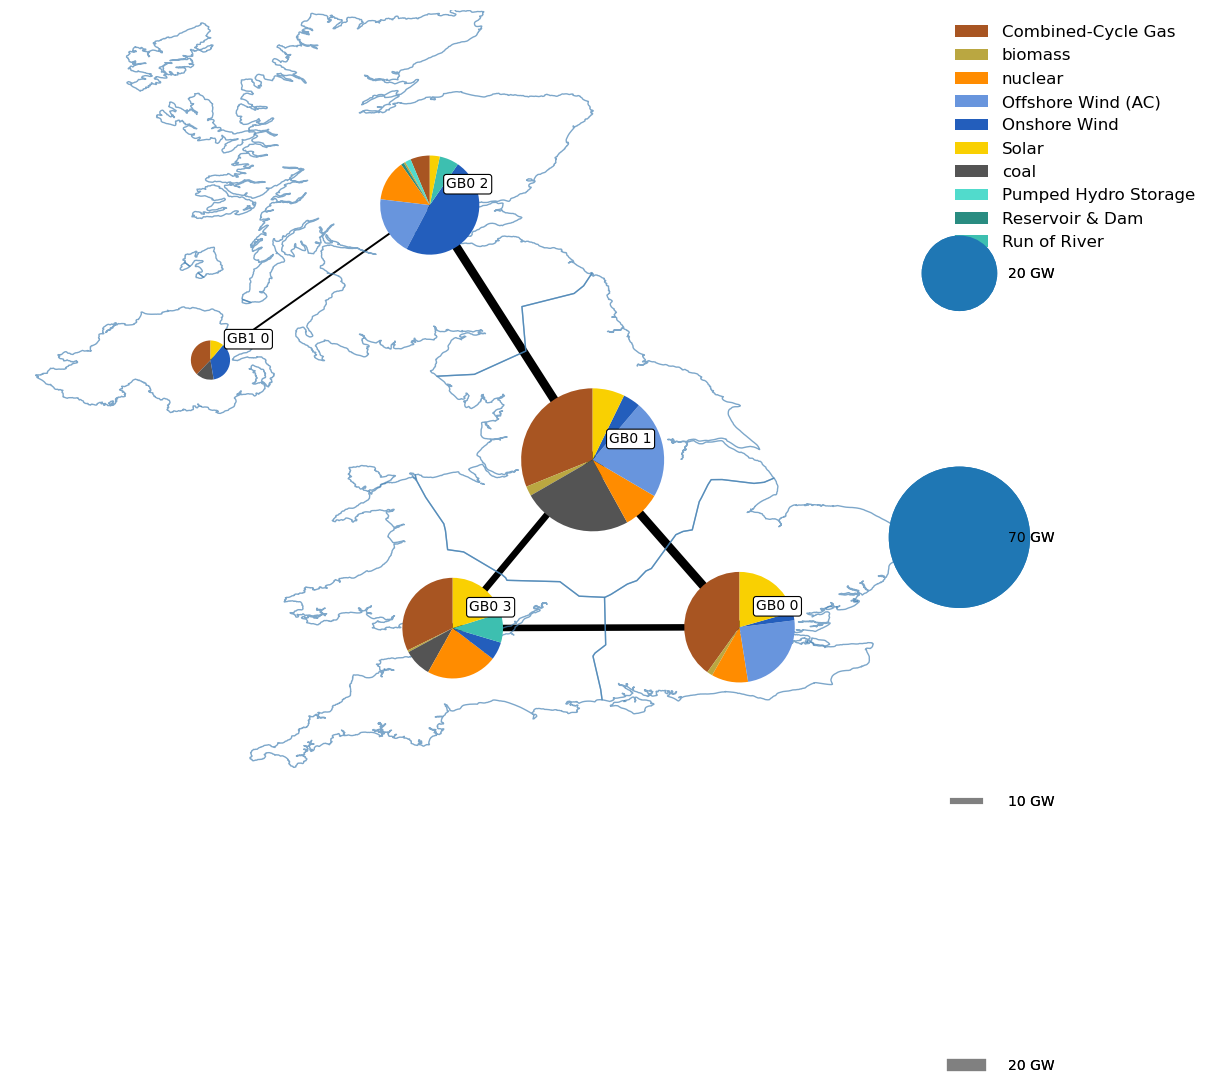

In [ ]:

regions = gpd.read_file(
    pypsa_eur_root / "resources" / CONFIG_NAME / SCENARIO_VARIANTS["cap"] / "regions_onshore_base_s_5.geojson"
)
n = networks["cap"]

fig, ax = plot_network_map(
    n, regions,
    stat="installed_capacity",
    bus_area_fraction=0.05,
    branch_area_fraction=0.07,
    legend_circles=[20000, 70000],
    legend_lines=[10000, 20000],
    legend_spacing= 8,
    legend_bbox=(1.0, 0.7),
    title="Installed capacity (AC)",
    figsize = (12,17)
)

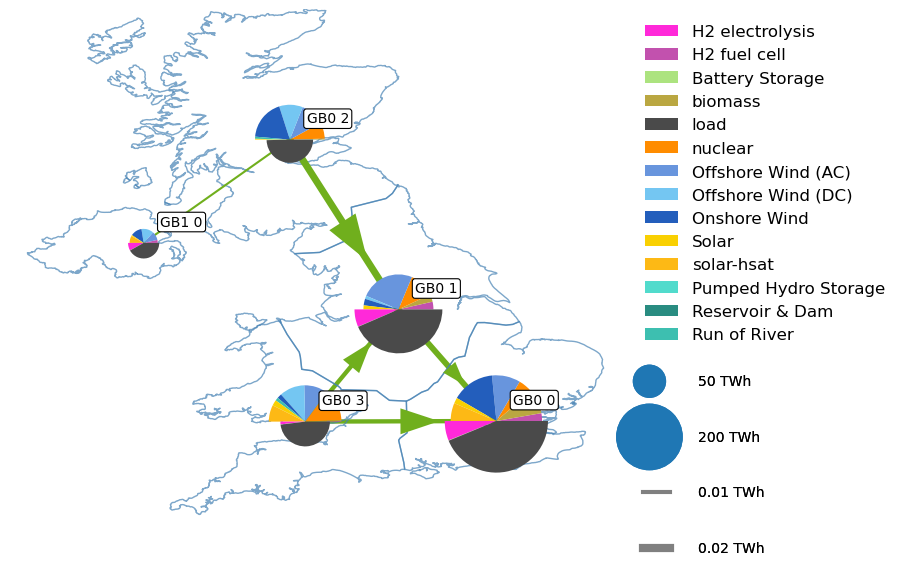

In [68]:
n = networks["base"]

fig, ax = plot_network_map(
    n, regions,
    stat="energy_balance",
    legend_circles=[50_000_000, 200_000_000],
    legend_lines=[10000, 20000],
    legend_unit="TWh",
    legend_multiplier=1e-6,
    legend_spacing= 3,
    legend_bbox=(1.0, 0.35),
    title="",
)

# Render DC transmission links manually — they were excluded from branch_components
# to avoid a NaN colour crash when mixed link types (e.g. H2 electrolysis) are present.
dc_links = n.links[n.links.carrier == "DC"].copy()
if not dc_links.empty:
    cap_col = "p_nom_opt" if "p_nom_opt" in dc_links.columns and dc_links["p_nom_opt"].notna().any() else "p_nom"
    max_cap = dc_links[cap_col].max()
    for _, link in dc_links.iterrows():
        try:
            x0, y0 = n.buses.loc[link.bus0, "x"], n.buses.loc[link.bus0, "y"]
            x1, y1 = n.buses.loc[link.bus1, "x"], n.buses.loc[link.bus1, "y"]
        except KeyError:
            continue
        lw = 0.5 + 4.5 * link[cap_col] / max_cap
        ax.plot([x0, x1], [y0, y1], color="#70af1d", linewidth=lw,
                solid_capstyle="round", zorder=4)
    # ax.plot([], [], color="slategray", linewidth=2.5, label="DC link")
    # ax.legend(loc="lower right")


### Stats Bar

In [23]:
import importlib
import plot_stats
from plot_stats import plot_network_map


In [24]:
from plot_stats import compute_stats_diff, format_stats_df, iplot_stats_bar, plot_stats_bar, plot_network_map
grouper = ["bus", "carrier", "bus_carrier"]
stats = nc.statistics(groupby=grouper, nice_names=False)
stats["Expanded Capacity"] = stats["Optimal Capacity"] - stats["Installed Capacity"]

diff = compute_stats_diff(stats, base="base")
diff = format_stats_df(diff, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])

fc_efficiency = networks['base'].links.loc[
    networks['base'].links.carrier == "H2 fuel cell", "efficiency"
].mean()

In [25]:
SUP_CARRIERS = [
        'biomass', 'nuclear', 'offwind-ac', 'offwind-dc',
       'onwind', 'solar', 'solar-hsat', 'load_shedding', 'ror', 'hydro']
CHARGE_CARRIERS = ['H2 electrolysis','H2 fuel cell','battery', 'PHS']

RE_CARRIERS = ['biomass', 'offwind-ac', 'offwind-dc', 'onwind', 'solar', 'solar-hsat', 'ror', 'biomass']
STOR_CARRIERS = ['H2 fuel cell']

GRID_CARRIERS = [
        'AC', 'DC', 'H2'
        ]

### SOC

In [26]:
nc.storage_units_t.state_of_charge

network                     base                                             \
name                   GB0 2 PHS    GB0 2 hydro GB0 0 battery GB0 1 battery   
snapshot                                                                      
2021-06-01 00:00:00   283.379257  146197.365796   2032.170949   1392.882884   
2021-06-01 01:00:00   532.024161  146222.213186   3422.185658   2491.268683   
2021-06-01 02:00:00   755.590580  146247.051290   3577.581724   3310.711634   
2021-06-01 03:00:00   959.631240  146271.879401   3277.602023   3988.796564   
2021-06-01 04:00:00  1147.064882  146296.698629   1938.200582   4292.943515   
...                          ...            ...           ...           ...   
2022-05-31 19:00:00  1089.142673  146682.847180  20928.083730   7099.872597   
2022-05-31 20:00:00   871.262848  146552.461048  13225.927820   5229.675862   
2022-05-31 21:00:00   626.299269  146423.267949   6285.573790   3530.936101   
2022-05-31 22:00:00   343.828975  146296.181696   2593.220756   1933.310950   
2022-05-31 23:00:00     0.003229  146172.509893      0.003138      0.003053   

network                                                           base_dis  \
name                GB0 2 battery GB0 3 battery GB1 0 battery    GB0 2 PHS   
snapshot                                                                     
2021-06-01 00:00:00   3955.599803    447.618967    666.935861   307.723113   
2021-06-01 01:00:00   8402.588325    649.485179   1317.903128   584.039117   
2021-06-01 02:00:00  13141.002384    754.277033   1928.134366   836.439933   
2021-06-01 03:00:00  18051.057244    754.281185   2439.706287  1069.023461   
2021-06-01 04:00:00  22368.055860    754.307612   2779.301048  1281.482283   
...                           ...           ...           ...          ...   
2022-05-31 19:00:00   5157.596805   8076.547203   1911.657398  1190.729448   
2022-05-31 20:00:00   3559.708256   7407.429997   1386.643137   948.390853   
2022-05-31 21:00:00   2164.087551   4270.788941    888.813392   678.435733   
2022-05-31 22:00:00   1132.239311   2238.298296    444.796103   374.243326   
2022-05-31 23:00:00      0.002509      0.002981      0.001396     0.001047   

network                                           ...        cap_on  \
name                   GB0 2 hydro GB0 0 battery  ... GB0 2 battery   
snapshot                                          ...                 
2021-06-01 00:00:00  139485.898657   2402.576413  ...   3492.378910   
2021-06-01 01:00:00  139510.750864   4099.054494  ...   7342.919770   
2021-06-01 02:00:00  139535.593790   4397.557776  ...  11510.319434   
2021-06-01 03:00:00  139560.426724   4097.635966  ...  15944.319560   
2021-06-01 04:00:00  139585.250777   2758.195094  ...  19882.213243   
...                            ...           ...  ...           ...   
2022-05-31 19:00:00  140110.040548  20260.395823  ...   5174.804257   
2022-05-31 20:00:00  139943.823334  12812.222454  ...   3669.216218   
2022-05-31 21:00:00  139778.822977   6074.120427  ...   2365.815519   
2022-05-31 22:00:00  139617.404393   2501.801691  ...   1258.965680   
2022-05-31 23:00:00  139461.037954      0.002541  ...      0.000194   

network                                                  dis                 \
name                GB0 3 battery GB1 0 battery    GB0 2 PHS    GB0 2 hydro   
snapshot                                                                      
2021-06-01 00:00:00    129.520247    674.116387   283.379257  146197.365796   
2021-06-01 01:00:00    182.980513   1331.968624   556.942787  146222.216753   
2021-06-01 02:00:00    222.800786   1948.488653   807.834466  146247.058555   
2021-06-01 03:00:00    222.801312   2465.167841  1039.103365  146271.890233   
2021-06-01 04:00:00    222.803215   2808.561680  1250.301639  146296.713028   
...                           ...           ...          ...            ...   
2022-05-31 19:00:00   8131.916330   1892.901271  1154.697374  146460.842188   
2022-05-31 20:0

In [26]:
nc.stores_t.e.filter(like="H2")

network                      base                                              \
name                     GB0 0 H2      GB0 1 H2       GB0 2 H2       GB0 3 H2   
snapshot                                                                        
2021-06-01 00:00:00  1.303044e+06  1.014385e+06  251002.234774  113311.556937   
2021-06-01 01:00:00  1.303880e+06  1.015061e+06  251483.175475  113518.212151   
2021-06-01 02:00:00  1.304716e+06  1.015738e+06  251964.115869  113724.867428   
2021-06-01 03:00:00  1.305551e+06  1.016414e+06  252445.056031  113931.522732   
2021-06-01 04:00:00  1.306387e+06  1.017090e+06  252925.996012  114138.178012   
...                           ...           ...            ...            ...   
2022-05-31 19:00:00  1.298865e+06  1.011004e+06  248597.546011  112278.282861   
2022-05-31 20:00:00  1.299701e+06  1.011680e+06  249078.482159  112484.937484   
2022-05-31 21:00:00  1.300536e+06  1.012357e+06  249559.418811  112691.592276   
2022-05-31 22:00:00  1.301372e+06  1.013033e+06  250040.356130  112898.246904   
2022-05-31 23:00:00  1.302208e+06  1.013709e+06  250521.293693  113104.901812   

network                                     cap                               \
name                     GB1 0 H2      GB0 0 H2      GB0 1 H2       GB0 2 H2   
snapshot                                                                       
2021-06-01 00:00:00  48002.176135  1.260621e+06  1.045620e+06  251576.935020   
2021-06-01 01:00:00  48099.495130  1.261388e+06  1.046383e+06  252059.665874   
2021-06-01 02:00:00  48196.814129  1.262156e+06  1.047146e+06  252542.396436   
2021-06-01 03:00:00  48294.133193  1.262923e+06  1.047909e+06  253025.126787   
2021-06-01 04:00:00  48391.452359  1.263691e+06  1.048672e+06  253507.856984   
...                           ...           ...           ...            ...   
2022-05-31 19:00:00  47837.090889  1.256784e+06  1.041804e+06  249163.322300   
2022-05-31 20:00:00  47802.327534  1.257552e+06  1.042567e+06  249646.040597   
2022-05-31 21:00:00  47770.474353  1.258319e+06  1.043330e+06  250128.760671   
2022-05-31 22:00:00  47807.540243  1.259086e+06  1.044093e+06  250611.482108   
2022-05-31 23:00:00  47904.857109  1.259854e+06  1.044857e+06  251094.203902   

network                                                    dis                 \
name                      GB0 3 H2      GB1 0 H2      GB0 0 H2       GB0 1 H2   
snapshot                                                                        
2021-06-01 00:00:00  100899.540621  60944.545819  1.366931e+06  877664.643034   
2021-06-01 01:00:00  101082.533615  61035.760901  1.367767e+06  878340.840659   
2021-06-01 02:00:00  101265.526665  61126.975989  1.368603e+06  879017.038284   
2021-06-01 03:00:00  101448.519797  61218.191162  1.369439e+06  879693.235909   
2021-06-01 04:00:00  101631.512977  61309.406468  1.370275e+06  880369.433533   
...                            ...           ...           ...            ...   
2022-05-31 19:00:00   99984.578020  60807.681428  1.362752e+06  874283.654916   
2022-05-31 20:00:00  100167.571173  60771.178792  1.363588e+06  874959.852539   
2022-05-31 21:00:00  100350.563650  60736.862611  1.364424e+06  875636.050162   
2022-05-31 22:00:00  100533.555764  60762.110664  1.365260e+06  876312.247785   
2022-05-31 23:00:00  100716.547670  60853.330687  1.366095e+06  876988.445409   

network                                                          
name                      GB0 2 H2       GB0 3 H2      GB1 0 H2  
snapshot                                                         
2021-06-01 00:00:00  251008.945234  155750.720173  45479.622681  
2021-06-01 01:00:00  251489.899526  155957.385509  45576.952419  
2021-06-01 02:00:00  251970.853819  156164.050845  45674.282158  
2021-06-01 03:00:00  252451.808111  156370.716181  45771.611897  
2021-06-01 04:00:00  252932.762404  156577.381518  45868.941635  
...                            ...            ...           ...  
2022-05-31 19:0

### Costs check

In [55]:
CARRIER  = "wind"          # or use str.startswith for partial match
BUS      = "GB0 0"           # set to None to skip bus filter
NETWORKS = ["base", "dis"]   # set to None for all

cols = ["bus", "carrier", "marginal_cost", "capital_cost", "p_nom", "p_nom_opt"]

frames = []
for name, n in networks.items():
    if NETWORKS and name not in NETWORKS:
        continue
    df = n.generators[cols].copy()
    df.insert(0, "network", name)

    mask = df["carrier"].str.contains(CARRIER)
    if BUS:
        mask &= df["bus"] == BUS
    frames.append(df[mask])

pd.concat(frames)


,network,bus,carrier,marginal_cost,capital_cost,p_nom,p_nom_opt
name,,,,,,,
GB0 0 0 offwind-dc,base,GB0 0,offwind-dc,0.019,201067.039268,0.000000,0.184722
GB0 0 0 offwind-ac,base,GB0 0,offwind-ac,0.016,185087.634365,6871.000000,7110.534536
GB0 0 0 onwind,base,GB0 0,onwind,0.013,94128.969871,682.700000,14674.016071
GB0 0 0 offwind-dc,dis,GB0 0,offwind-dc,0.019,201067.039268,0.184722,0.184722
GB0 0 0 offwind-ac,dis,GB0 0,offwind-ac,0.016,185087.634365,7110.534536,7110.534536
GB0 0 0 onwind,dis,GB0 0,onwind,0.013,94128.969871,14674.016071,14674.016071


In [ ]:
# Filter to just offwind-ac and offwind-dc
offwind = (
    nc.generators
    .loc[nc.generators.carrier.isin(["soalr", "solar", "offwind-ac", "offwind-dc"]),
         ["carrier", "marginal_cost", "capital_cost"]]
    .reset_index()   # brings 'network' and 'name' into columns
)

# Extract bus key by removing the carrier suffix from the generator name
offwind["bus_key"] = offwind["name"].str.rsplit(" ", n=1).str[0]

# Pivot marginal_cost to wide format: one column per carrier
mc_diff = (
    offwind
    .pivot_table(index=["network", "bus_key"], columns="carrier", values="marginal_cost")
    .assign(mc_diff=lambda df: df["offwind-ac"] - df["offwind-dc"])
)

mc_diff


carrier           offwind-ac  offwind-dc  mc_diff
network  bus_key                                 
base     GB0 0 0       0.015       0.017   -0.002
         GB0 1 0       0.015       0.017   -0.002
         GB0 2 0       0.015       0.017   -0.002
         GB0 3 0       0.015       0.017   -0.002
         GB1 0 0       0.015       0.017   -0.002
base_dis GB0 0 0       0.015       0.017   -0.002
         GB0 1 0       0.015       0.017   -0.002
         GB0 2 0       0.015       0.017   -0.002
         GB0 3 0       0.015       0.017   -0.002
         GB1 0 0       0.015       0.017   -0.002
cap      GB0 0 0       0.015       0.017   -0.002
         GB0 1 0       0.015       0.017   -0.002
         GB0 2 0       0.015       0.017   -0.002
         GB0 3 0       0.015       0.017   -0.002
         GB1 0 0       0.015       0.017   -0.002
cap_on   GB0 0 0       0.015       0.017   -0.002
         GB0 1 0       0.015       0.017   -0.002
         GB0 2 0       0.015       0.017   -0.002
         GB0 3 0       0.015       0.017   -0.002
         GB1 0 0       0.015       0.017   -0.002
dis      GB0 0 0       0.015       0.017   -0.002
         GB0 1 0       0.015       0.017   -0.002
         GB0 2 0       0.015       0.017   -0.002
         GB0 3 0       0.015       0.017   -0.002
         GB1 0 0       0.015       0.017   -0.002

In [102]:
n = networks["base"]
phs = n.storage_units[n.storage_units.carrier == "PHS"]
phs[["p_nom", "p_nom_opt", "max_hours", "efficiency_store", "efficiency_dispatch"]]


,p_nom,p_nom_opt,max_hours,efficiency_store,efficiency_dispatch
name,,,,,
GB0 2 PHS,440.0,440.0,15.909091,0.866025,0.866025


## Statistics diffs

In [27]:
grouper = ["bus", "carrier", "bus_carrier"]

stats = nc.statistics(groupby=grouper, nice_names=False)
stats["Expanded Capacity"] = stats["Optimal Capacity"] - stats["Installed Capacity"]
diff = compute_stats_diff(stats, base="base")
diff = format_stats_df(diff, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])


In [59]:
diff.columns

Index(['techgroup', 'network', 'bus', 'tech', 'bus_carrier',
       'optimal capacity', 'installed capacity', 'supply', 'withdrawal',
       'energy balance', 'transmission', 'capacity factor', 'curtailment',
       'capital expenditure', 'operational expenditure', 'revenue',
       'market value', 'expanded capacity', 'optimal_capacity_diff',
       'installed_capacity_diff', 'supply_diff', 'withdrawal_diff',
       'energy_balance_diff', 'transmission_diff', 'capacity_factor_diff',
       'curtailment_diff', 'capital_expenditure_diff',
       'operational_expenditure_diff', 'revenue_diff', 'market_value_diff',
       'expanded_capacity_diff'],
      dtype='object')

In [34]:
# diff[diff['tech'] == 'H2 electrolysis']

In [58]:
diff.techgroup.unique()

array(['Generator', 'Line', 'Link', 'Load', 'StorageUnit', 'Store'],
      dtype=object)

TypeError: no numeric data to plot

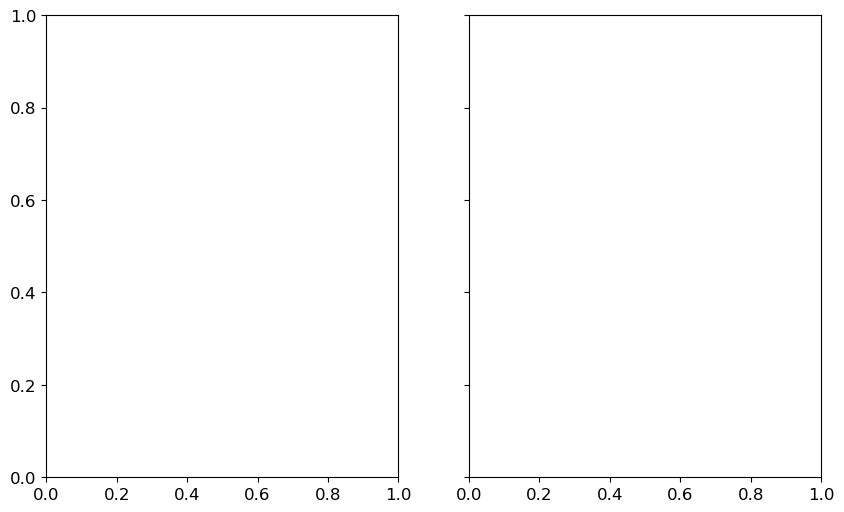

In [28]:
plot_stats_bar(
    diff[
        diff["techgroup"].isin(["Line", "Link"]) 
        & (diff["tech"] != "H2 electrolysis")
        & (diff["bus_carrier"] == "AC")
    ],
    column="expanded capacity",
    networks=["base", "cap"],
    multiplier=1,
    title="Expanded Capacity (MW)",
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: title={'center': 'base'}, xlabel='Bus', ylabel='Optimal Capacity (MW)'>,
        <Axes: title={'center': 'cap'}, xlabel='Bus'>], dtype=object))

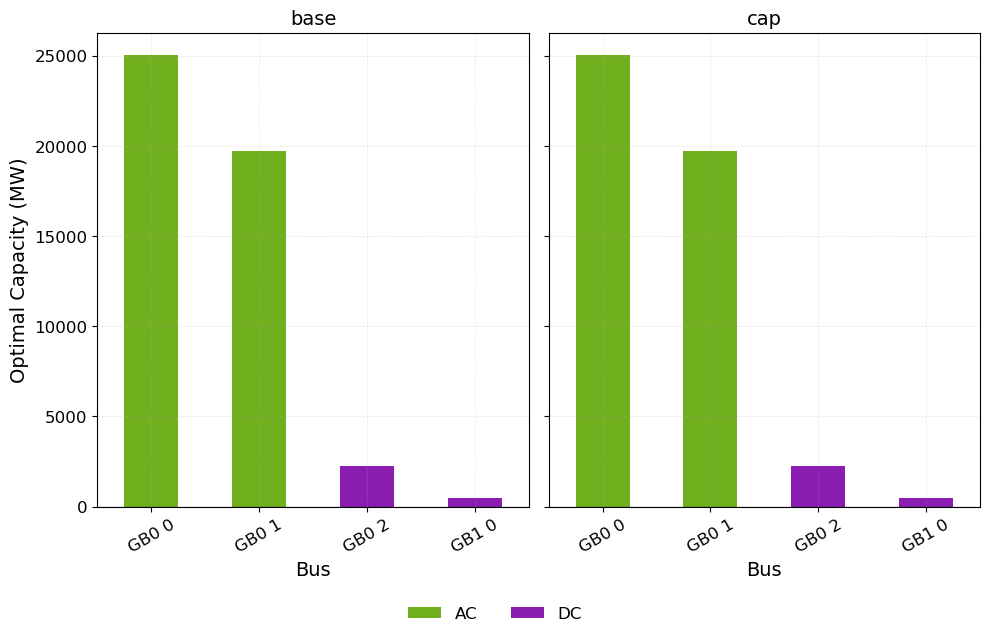

In [61]:
plot_stats_bar(
    diff[
        diff["techgroup"].isin(["Line", "Link"]) 
        & (diff["tech"] != "H2 electrolysis")
        & (diff["bus_carrier"] == "AC")
    ],
    column="optimal capacity",
    networks=["base", "cap"],
    multiplier=1,
    title="Optimal Capacity (MW)",
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

TypeError: no numeric data to plot

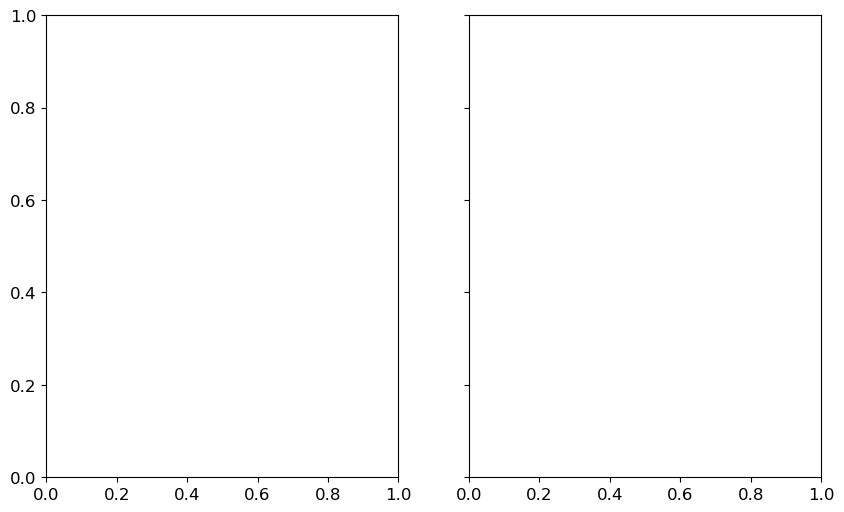

In [61]:
plot_stats_bar(
    diff[
        diff["techgroup"].isin(["Line", "Link"]) 
        & (diff["tech"] != "H2 electrolysis")
        & (diff["bus_carrier"] == "AC")
    ],
    column="expanded capacity",
    networks=["base", "cap"],
    multiplier=1,
    title="Expanded Capacity (MW)",
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

(<Figure size 600x600 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, ylabel='Δ Curtailment (GWh)'>])

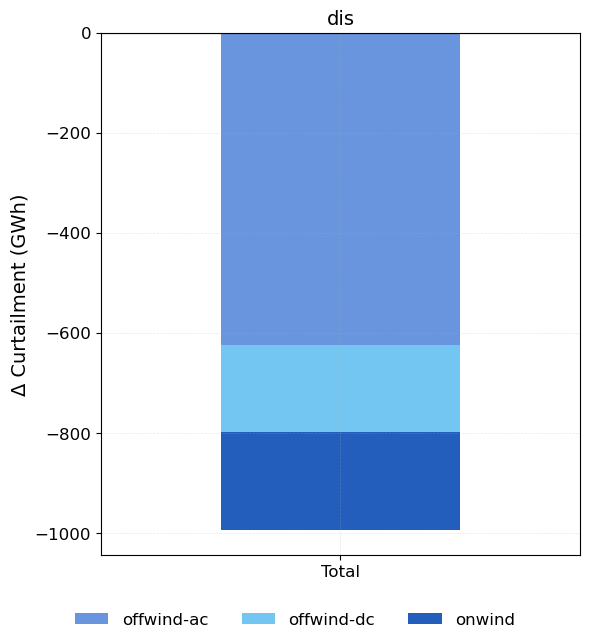

In [62]:
CARRIERS_TO_PLOT = ["onwind", "offwind-ac", "offwind-dc"]

plot_stats_bar(
    diff[
        diff["tech"].isin(CARRIERS_TO_PLOT) &
        (diff["bus_carrier"] == "AC")
    ],
    column="curtailment_diff",
    networks=["dis"],
    multiplier=1e-3,
    aggregate=True,
    title="\u0394 Curtailment (GWh)",
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(6, 6)
)


In [44]:
diff[diff['tech'] == 'H2 electrolysis']

,techgroup,network,bus,tech,bus_carrier,optimal capacity,installed capacity,supply,withdrawal,energy balance,...,withdrawal_diff,energy_balance_diff,transmission_diff,capacity_factor_diff,curtailment_diff,capital_expenditure_diff,operational_expenditure_diff,revenue_diff,market_value_diff,expanded_capacity_diff
240,Link,base,GB0 0,H2 electrolysis,AC,5631.25040,0.00000,0.0,2.380171e+07,-2.380171e+07,...,0.00000,0.00000,0.0,0.000000,0.0,0.000000e+00,0.00000,0.000000e+00,NaN,0.00000
242,Link,base,GB0 1,H2 electrolysis,AC,3903.97270,0.00000,0.0,1.847212e+07,-1.847212e+07,...,0.00000,0.00000,0.0,0.000000,0.0,0.000000e+00,0.00000,0.000000e+00,NaN,0.00000
245,Link,base,GB0 2,H2 electrolysis,AC,0.16498,0.00000,0.0,8.815854e+02,-8.815854e+02,...,0.00000,0.00000,0.0,0.000000,0.0,0.000000e+00,0.00000,0.000000e+00,NaN,0.00000
247,Link,base,GB0 3,H2 electrolysis,AC,325.33116,0.00000,0.0,1.633690e+06,-1.633690e+06,...,0.00000,0.00000,0.0,0.000000,0.0,0.000000e+00,0.00000,0.000000e+00,NaN,0.00000
250,Link,base,GB1 0,H2 electrolysis,AC,621.08095,0.00000,0.0,2.839800e+06,-2.839800e+06,...,0.00000,0.00000,0.0,0.000000,0.0,0.000000e+00,0.00000,0.000000e+00,NaN,0.00000
252,Link,base_dis,GB0 0,H2 electrolysis,AC,5631.98884,5631.98884,0.0,2.371714e+07,-2.371714e+07,...,-84569.94328,84569.94328,0.0,-0.001777,0.0,9.290320e+04,232380.05099,1.270425e+08,NaN,-5631.25040
254,Link,base_dis,GB0 1,H2 electrolysis,AC,3902.38411,3902.38411,0.0,1.854697e+07,-1.854697e+07,...,74856.80878,-74856.80878,0.0,0.002410,0.0,-1.998606e+05,189212.81841,1.210890e+08,NaN,-3903.97270
257,Link,base_dis,GB0 2,H2 electrolysis,AC,0.15805,0.15805,0.0,8.285737e+02,-8.285737e+02,...,-53.01170,53.01170,0.0,-0.011532,0.0,-8.718408e+02,8.59010,3.162609e+03,NaN,-0.16498
259,Link,base_dis,GB0 3,H2 electrolysis,AC,325.93788,325.93788,0.0,1.632588e+06,-1.632588e+06,...,-1102.06623,1102.06623,0.0,-0.001453,0.0,7.633208e+04,16856.78050,1.275098e+07,NaN,-325.33116
262,Link,base_dis,GB1 0,H2 electrolysis,AC,621.31367,621.31367,0.0,2.849667e+06,-2.849667e+06,...,9867.56211,-9867.56211,0.0,0.001617,0.0,2.927935e+04,30746.34113,2.226734e+07,NaN,-621.08095


In [21]:
SUP_CARRIERS = [
        'biomass', 'nuclear', 'offwind-ac', 'offwind-dc',
       'onwind', 'solar', 'solar-hsat', 'load_shedding', 'ror', 'hydro']
CHARGE_CARRIERS = ['H2 electrolysis','H2 fuel cell','battery', 'PHS']

RE_CARRIERS = ['biomass', 'offwind-ac', 'offwind-dc', 'onwind', 'solar', 'solar-hsat', 'ror', 'biomass']
STOR_CARRIERS = ['H2 fuel cell']

GRID_CARRIERS = [
        'AC', 'DC', 'H2'
        ]

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'base'}, xlabel='Bus', ylabel='Installed Capacity(GW)'>])

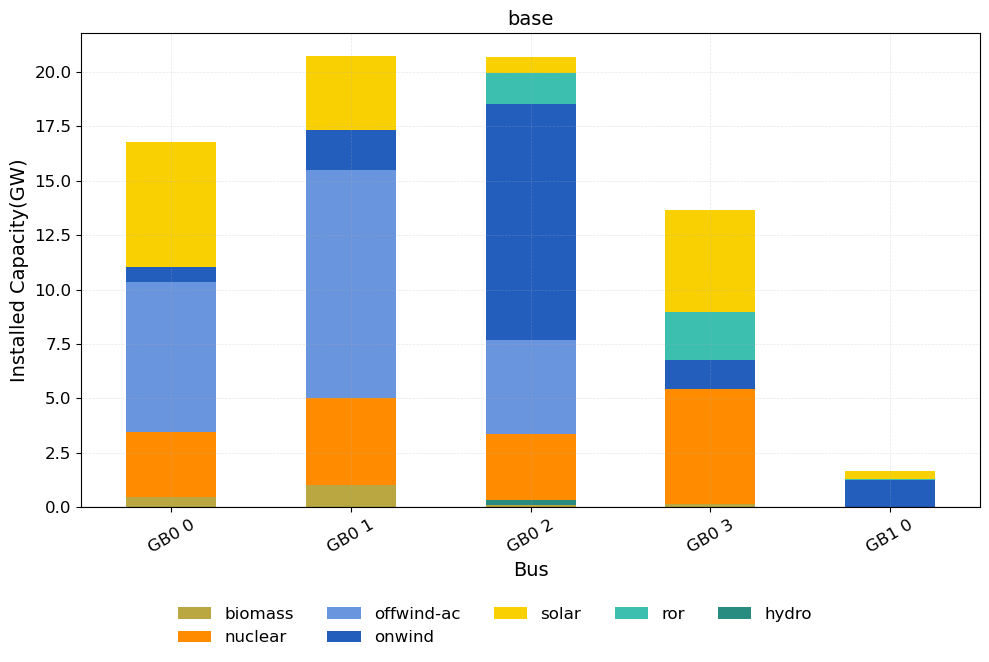

In [91]:
plot_stats_bar(
    diff[
        diff["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS) &
        # diff_on["techgroup"].isin(["Generator", "StorageUnit"]) &
        (diff["bus_carrier"] == "AC")
    ],
    column="installed capacity",
    multiplier=1e-3,
    title="Installed Capacity(GW)",
    networks=["base"],
    color_map=networks["base_dis"].carriers.color.to_dict(),
    figsize=(10, 6)
    )

(<Figure size 800x800 with 1 Axes>,
 [<Axes: title={'center': 'base'}, xlabel='Bus', ylabel='Expanded Capacity (GW)'>])

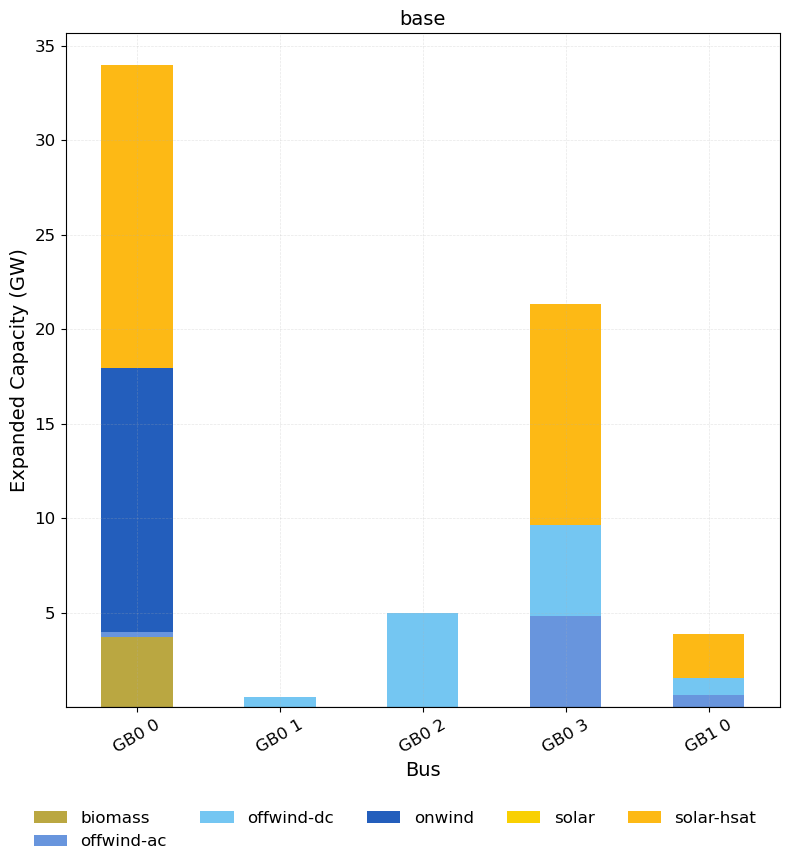

In [29]:
fc_efficiency = networks['base'].links.loc[
    networks['base'].links.carrier == "H2 fuel cell", "efficiency"
].mean()

plot_stats_bar(
    diff[diff["tech"].isin(SUP_CARRIERS)],
    column="expanded capacity",
    multiplier=1e-3,
    carrier_multipliers={"H2 fuel cell": fc_efficiency},
    title="Expanded Capacity (GW)",
    networks=["base"],
    color_map=color_map,
    figsize=(8, 8),
)


(<Figure size 800x800 with 1 Axes>,
 [<Axes: title={'center': 'base'}, xlabel='Bus', ylabel='Optimal Capacity (GW)'>])

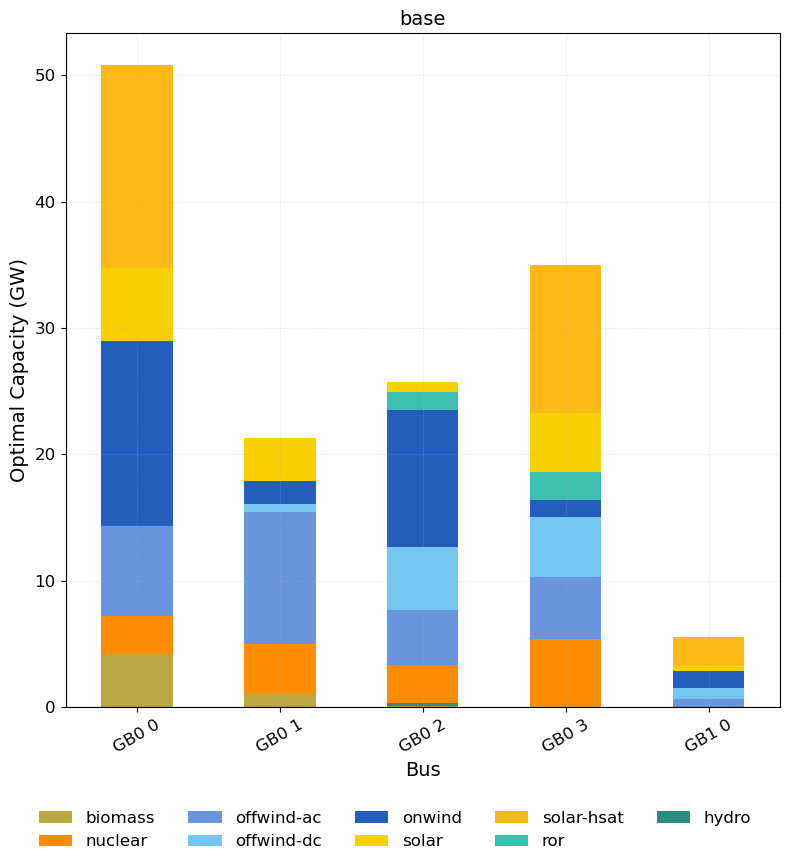

In [93]:
plot_stats_bar(
    diff[
        diff["tech"].isin(SUP_CARRIERS)
        # diff["techgroup"].isin(["Generator", "StorageUnit"])
        # & (diff["bus_carrier"] == "AC")
    ],
    column="optimal capacity",
    multiplier=1e-3,
    carrier_multipliers={"H2 fuel cell": fc_efficiency},
    title="Optimal Capacity (GW)",
    networks=["base"],
    # aggregate = True,
    color_map=color_map,
    figsize=(8, 8)
)

In [103]:
CHARGE_CARRIERS

['H2 electrolysis', 'H2 fuel cell', 'battery', 'PSH']

(<Figure size 800x600 with 1 Axes>,
 [<Axes: title={'center': 'base'}, xlabel='Bus', ylabel='Optimal Capacity (GW)'>])

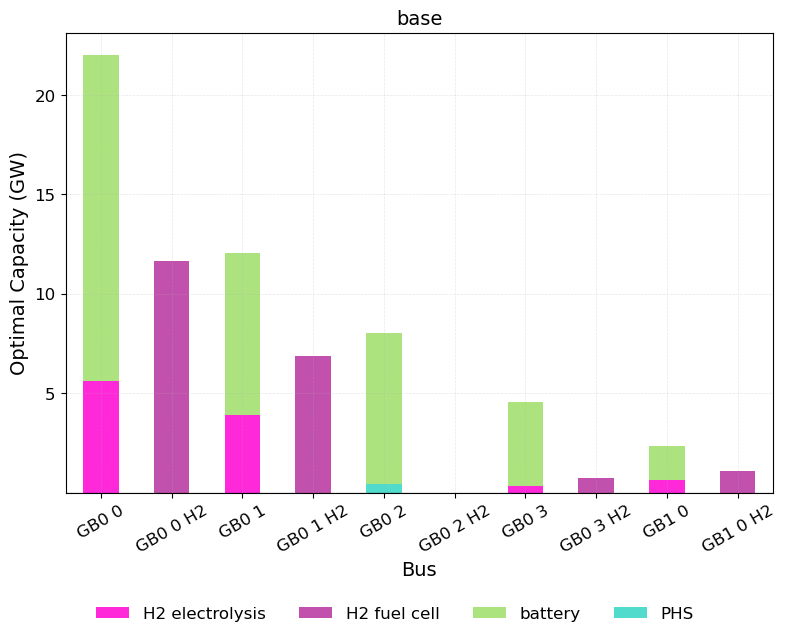

In [105]:
fc_efficiency = networks['base'].links.loc[
    networks['base'].links.carrier == "H2 fuel cell", "efficiency"
].mean()

plot_stats_bar(
    diff[
        diff["tech"].isin(CHARGE_CARRIERS)
        # diff["techgroup"].isin(["Generator", "StorageUnit"])
        # & (diff["bus_carrier"] == "AC")
    ],
    column="optimal capacity",
    multiplier=1e-3,
    carrier_multipliers={"H2 fuel cell": fc_efficiency},
    title="Optimal Capacity (GW)",
    networks=["base"],
    # aggregate = True,
    color_map=color_map,
    figsize=(8, 6)
)

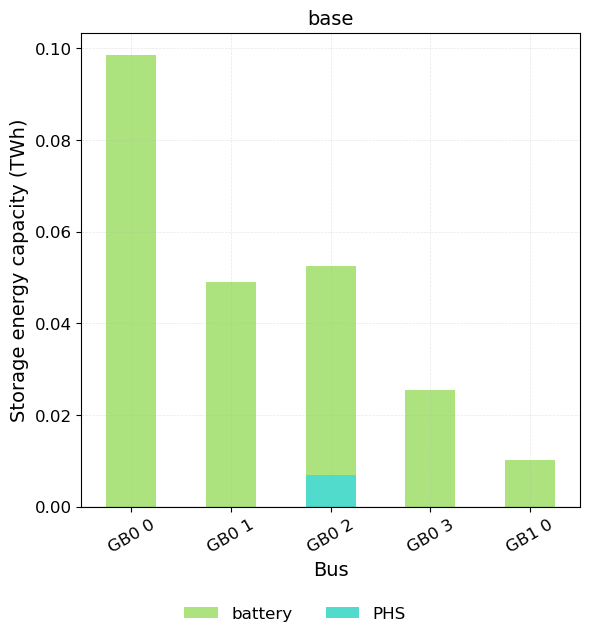

In [95]:
storage_stats = nc.statistics.optimal_capacity(groupby=grouper, nice_names=False, storage=True)
storage_stats = storage_stats.loc[storage_stats.index.get_level_values("component").isin(["Store", "StorageUnit"])]
storage_stats = storage_stats.to_frame("Optimal Capacity")

storage_stats = compute_stats_diff(storage_stats, base="base")
storage_df    = format_stats_df(storage_stats, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])
storage_df = storage_df[~storage_df["bus_carrier"].isin(["H2"]) & (storage_df["tech"] != "hydro")]

fig, axes = plot_stats_bar(
    storage_df,
    column="optimal capacity",
    networks=["base"],
    color_map=n.carriers.color.to_dict(),
    multiplier=1e-6,
    title="Storage energy capacity (TWh)",
    figsize=(6, 6)
)


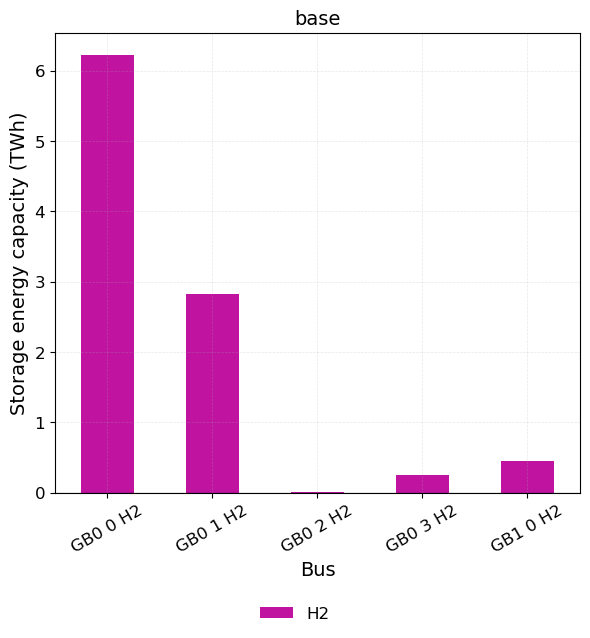

In [137]:
storage_stats = nc.statistics.optimal_capacity(groupby=grouper, nice_names=False, storage=True)
storage_stats = storage_stats.loc[storage_stats.index.get_level_values("component").isin(["Store", "StorageUnit"])]
storage_stats = storage_stats.to_frame("Optimal Capacity")

storage_stats = compute_stats_diff(storage_stats, base="base")
storage_df    = format_stats_df(storage_stats, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])
storage_df = storage_df[storage_df["bus_carrier"].isin(["H2"])]

fig, axes = plot_stats_bar(
    storage_df,
    column="optimal capacity",
    networks=["base"],
    color_map=n.carriers.color.to_dict(),
    multiplier=1e-6,
    title="Storage energy capacity (TWh)",
    figsize=(6, 6)
)


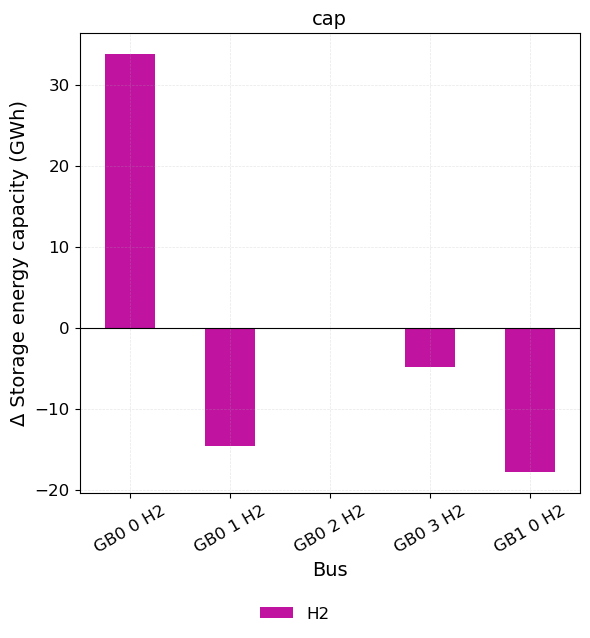

In [138]:
fig, axes = plot_stats_bar(
    storage_df,
    column="optimal_capacity_diff",
    networks=["cap"],
    color_map=n.carriers.color.to_dict(),
    multiplier=1e-3,
    title="\u0394 Storage energy capacity (GWh)",
    figsize=(6, 6),
    aggregate=False
)


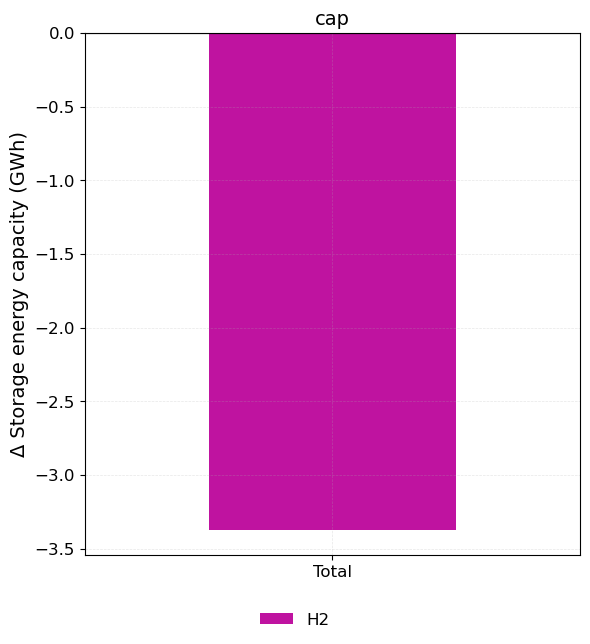

In [98]:
fig, axes = plot_stats_bar(
    storage_df,
    column="optimal_capacity_diff",
    networks=["cap"],
    color_map=n.carriers.color.to_dict(),
    multiplier=1e-3,
    title="\u0394 Storage energy capacity (GWh)",
    figsize=(6, 6),
    aggregate=True
)


In [101]:
CHARGE_CARRIERS

['H2 electrolysis', 'H2 fuel cell', 'battery', 'PSH']

(<Figure size 800x600 with 1 Axes>,
 [<Axes: title={'center': 'cap'}, xlabel='Bus', ylabel='Δ Expanded Capacity (GW)'>])

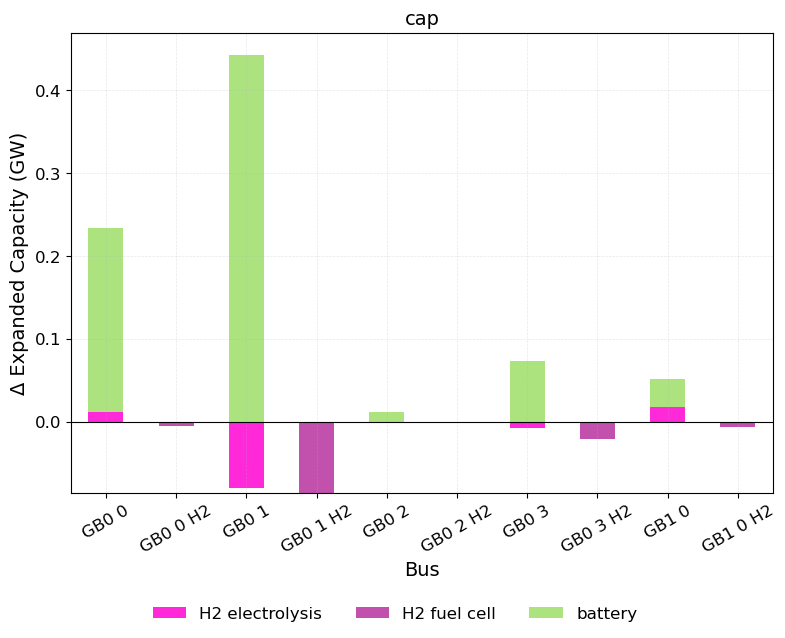

In [153]:
fc_efficiency = networks['base'].links.loc[
    networks['base'].links.carrier == "H2 fuel cell", "efficiency"
].mean()

plot_stats_bar(
    diff[
        diff["tech"].isin(CHARGE_CARRIERS)
        # diff["techgroup"].isin(["Generator", "StorageUnit"])
        # & (diff["bus_carrier"] == "AC")
    ],
    column="expanded_capacity_diff",
    multiplier=1e-3,
    carrier_multipliers={"H2 fuel cell": fc_efficiency},
    title="\u0394 Expanded Capacity (GW)",
    networks=["cap"],
    # aggregate = True,
    color_map=color_map,
    figsize=(8, 6)
)

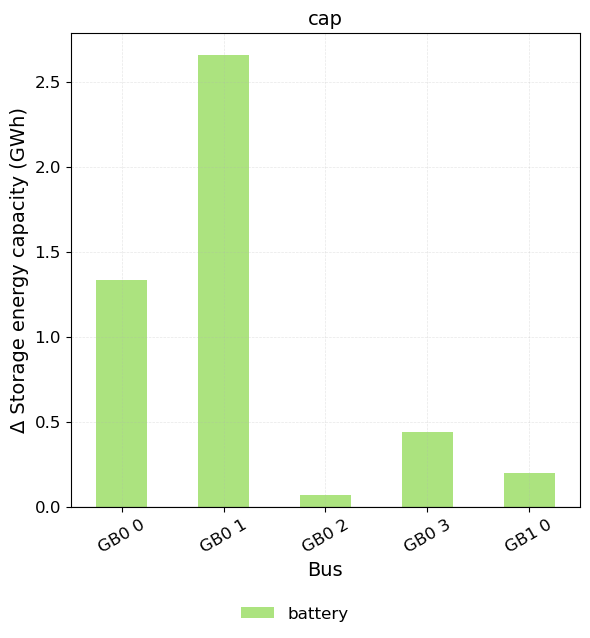

In [99]:
storage_stats = nc.statistics.optimal_capacity(groupby=grouper, nice_names=False, storage=True)
storage_stats = storage_stats.loc[storage_stats.index.get_level_values("component").isin(["Store", "StorageUnit"])]
storage_stats = storage_stats.to_frame("Optimal Capacity")

storage_stats = compute_stats_diff(storage_stats, base="base")
storage_df    = format_stats_df(storage_stats, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])
storage_df = storage_df[~storage_df["bus_carrier"].isin(["H2"]) & (storage_df["tech"] != "hydro")]


fig, axes = plot_stats_bar(
    storage_df,
    column="optimal_capacity_diff",
    networks=["cap"],
    color_map=n.carriers.color.to_dict(),
    multiplier=1e-3,
    title="\u0394 Storage energy capacity (GWh)",
    figsize=(6, 6),
    aggregate=False
)

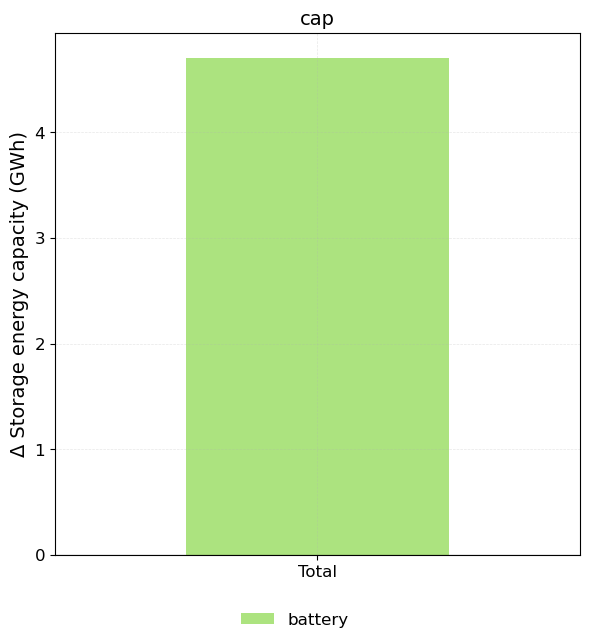

In [100]:
storage_stats = nc.statistics.optimal_capacity(groupby=grouper, nice_names=False, storage=True)
storage_stats = storage_stats.loc[storage_stats.index.get_level_values("component").isin(["Store", "StorageUnit"])]
storage_stats = storage_stats.to_frame("Optimal Capacity")

storage_stats = compute_stats_diff(storage_stats, base="base")
storage_df    = format_stats_df(storage_stats, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])
storage_df = storage_df[~storage_df["bus_carrier"].isin(["H2"]) & (storage_df["tech"] != "hydro")]


fig, axes = plot_stats_bar(
    storage_df,
    column="optimal_capacity_diff",
    networks=["cap"],
    color_map=n.carriers.color.to_dict(),
    multiplier=1e-3,
    title="\u0394 Storage energy capacity (GWh)",
    figsize=(6, 6),
    aggregate=True
)

(<Figure size 800x600 with 1 Axes>,
 [<Axes: title={'center': 'cap'}, xlabel='Bus', ylabel='Δ Expanded Capacity (MW)'>])

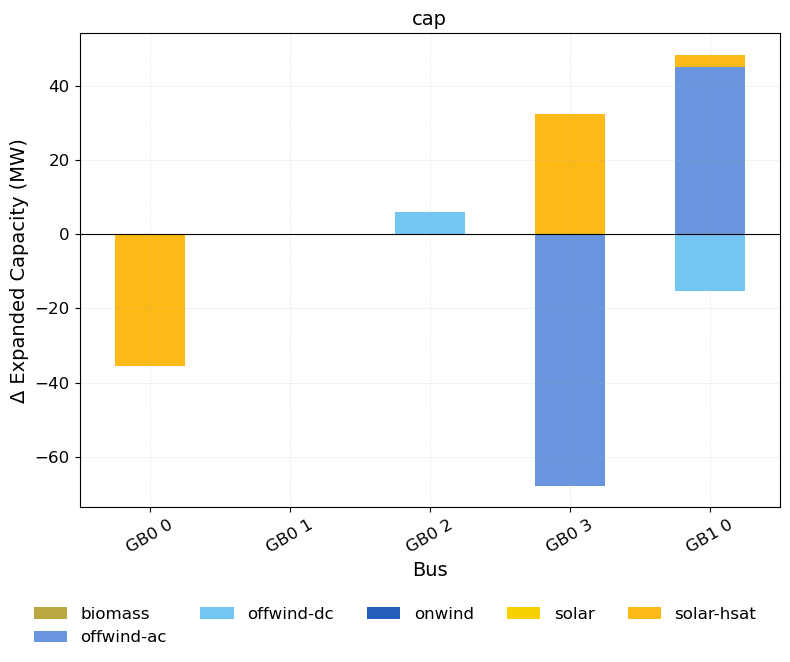

In [101]:
plot_stats_bar(
    diff[
        diff["tech"].isin(SUP_CARRIERS)
        # diff["techgroup"].isin(["Generator", "StorageUnit"])
        & (diff["bus_carrier"] == "AC")
    ],
    column="expanded_capacity_diff",
    # multiplier=1e-3,
    title="\u0394 Expanded Capacity (MW)",
    networks=["cap"],
    carrier_multipliers={"H2 fuel cell": fc_efficiency},
    # aggregate = True,
    color_map=color_map,
    figsize=(8, 6)
)

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'base'}, xlabel='Bus', ylabel='Supply (TWh)'>])

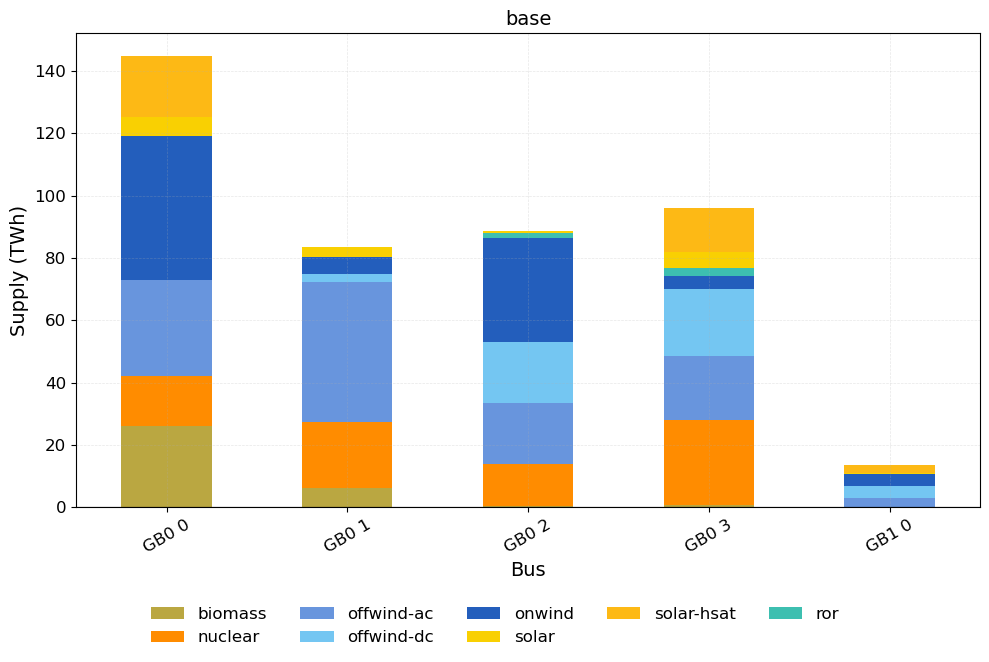

In [73]:
plot_stats_bar(
    diff[
        diff["tech"].isin(SUP_CARRIERS) &
        # diff_on["techgroup"].isin(["Generator", "StorageUnit"]) &
        (diff["bus_carrier"] == "AC")
    ],
    column="supply",
    multiplier=1e-6,
    title="Supply (TWh)",
    networks=["base"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
    )

(<Figure size 600x600 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, xlabel='Bus', ylabel='energy balance diff (GWh)'>])

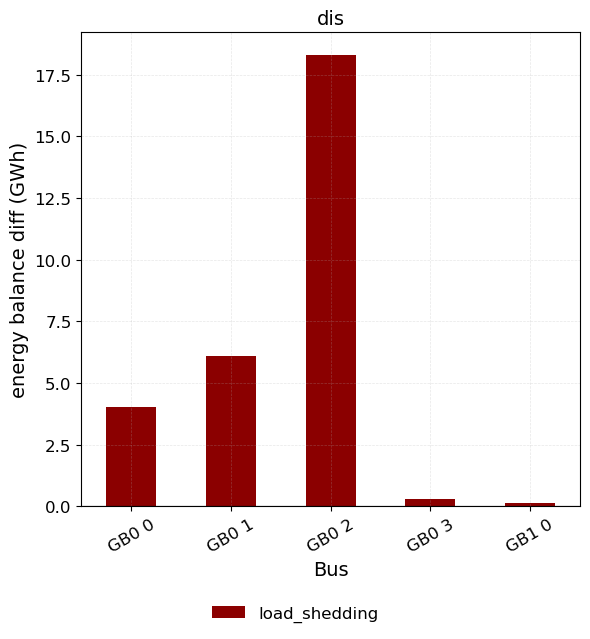

In [79]:
plot_stats_bar(
    diff[
        diff["tech"].isin(["load_shedding"]) 
        # diff_on["techgroup"].isin(["Generator", "StorageUnit"])
        & (diff["bus_carrier"] == "AC")
    ],
    column="energy_balance_diff",
    multiplier=1e-3,
    title="energy balance diff (GWh)",
    networks=["dis"],
    color_map=networks["dis"].carriers.color.to_dict(),
    figsize=(6, 6)
    )

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, ylabel='energy balance diff (GWh)'>])

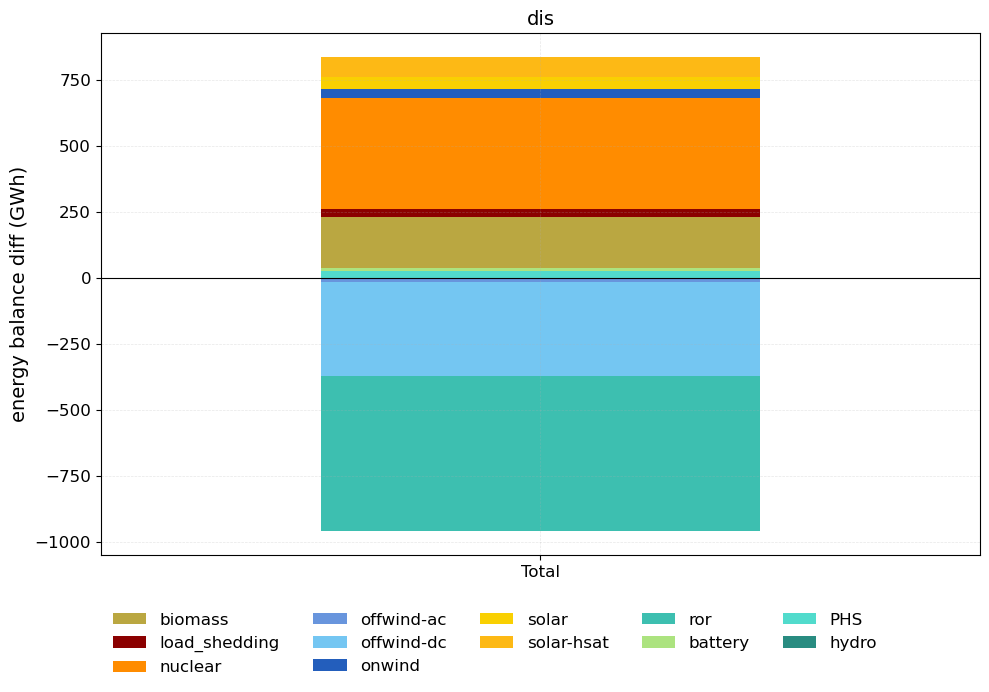

In [109]:
plot_stats_bar(
    diff[
        # diff["tech"].isin(["offwind-ac","offwind-dc","onwind"]) 
        diff["techgroup"].isin(["Generator", "StorageUnit"]) &
        (diff["bus_carrier"] == "AC")
    ],
    column="energy_balance_diff",
    multiplier=1e-3,
    title="energy balance diff (GWh)",
    networks=["dis"],
    aggregate=True,
    color_map=networks["dis"].carriers.color.to_dict(),
    figsize=(10, 6)
    )

In [67]:
CHARGE_CARRIERS

['H2 electrolysis', 'H2 fuel cell', 'battery', 'PSH']

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, xlabel='Bus', ylabel='Energy Balance Difference (GWh)'>])

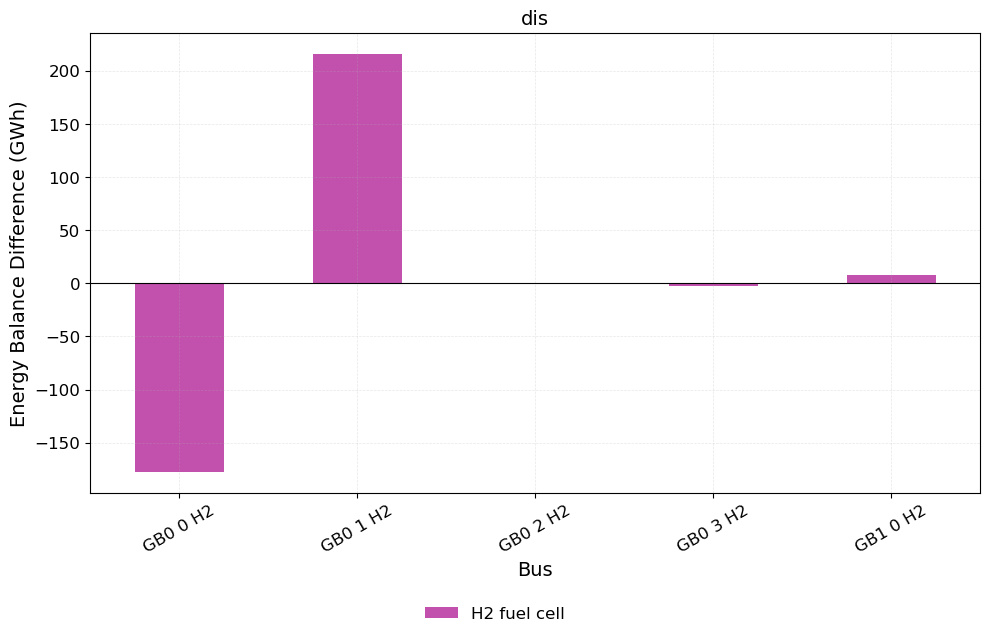

In [106]:
diff = compute_stats_diff(stats, base="base")
diff = format_stats_df(diff, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])
plot_stats_bar(
    diff[
        diff["tech"].isin(STOR_CARRIERS) 
        # & (diff["tech"] != "H2 electrolysis")
        # & (diff["bus_carrier"] == "AC")
    ],
    column="energy_balance_diff",
    networks=["dis"],
    multiplier=1e-3,
    aggregate=False,
    title="Energy Balance Difference (GWh)",
    color_map=color_map,
    figsize=(10, 6)
)

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, xlabel='Bus', ylabel='Energy Balance Difference (GWh)'>])

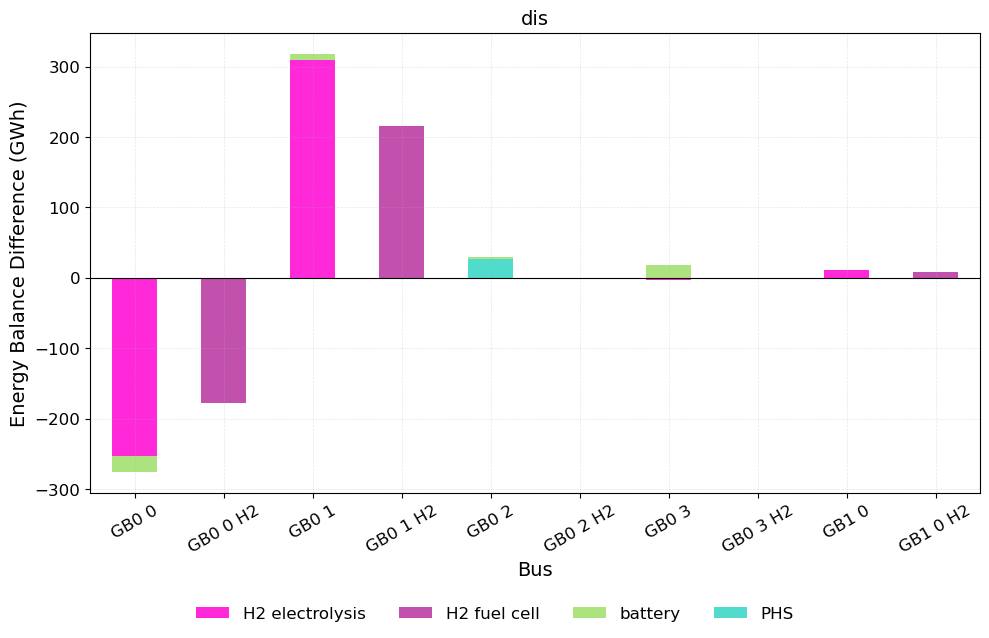

In [30]:
diff = compute_stats_diff(stats, base="base")
diff = format_stats_df(diff, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])
plot_stats_bar(
    diff[
        diff["tech"].isin(CHARGE_CARRIERS) 
        # & (diff["tech"] != "H2 electrolysis")
        # & (diff["bus_carrier"] == "AC")
    ],
    column="energy_balance_diff",
    networks=["dis"],
    multiplier=1e-3,
    aggregate=False,
    title="Energy Balance Difference (GWh)",
    color_map=color_map,
    figsize=(10, 6)
)

(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: title={'center': 'base'}, ylabel='Energy Balance Difference (GWh)'>,
        <Axes: title={'center': 'dis'}>], dtype=object))

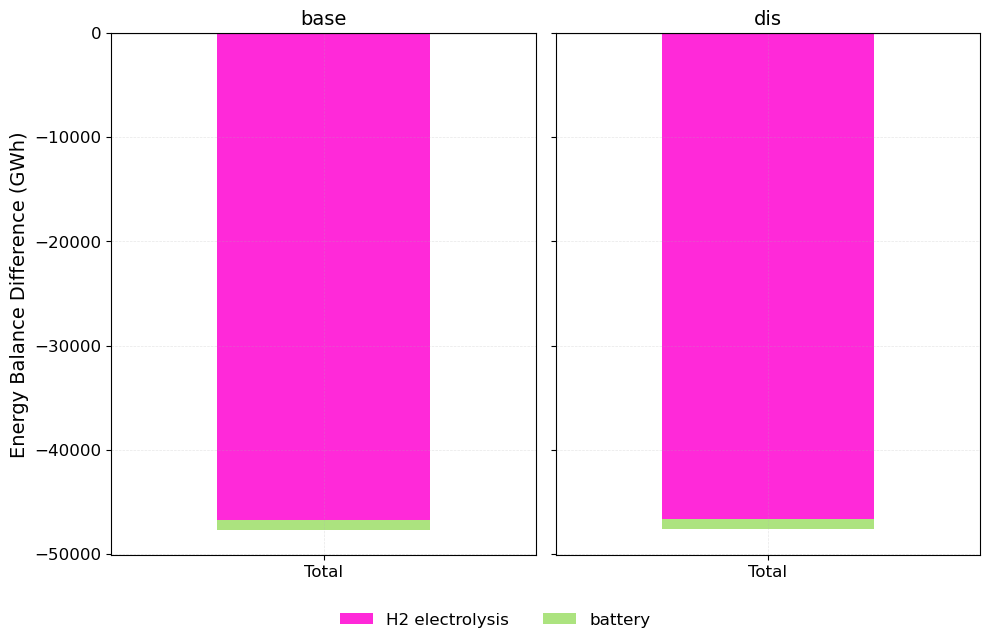

In [76]:
diff = compute_stats_diff(stats, base="base")
diff = format_stats_df(diff, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])
plot_stats_bar(
    diff[
        diff["tech"].isin(CHARGE_CARRIERS) 
        # & (diff["tech"] != "H2 electrolysis")
        & (diff["bus_carrier"] == "AC")
    ],
    column="energy balance",
    networks=["base", "dis"],
    multiplier=1e-3,
    aggregate=True,
    title="Energy Balance Difference (GWh)",
    color_map=color_map,
    figsize=(10, 6)
)

(<Figure size 600x600 with 2 Axes>,
 array([<Axes: title={'center': 'dis'}, ylabel='Energy Balance Difference (GWh)'>,
        <Axes: title={'center': 'cap'}>], dtype=object))

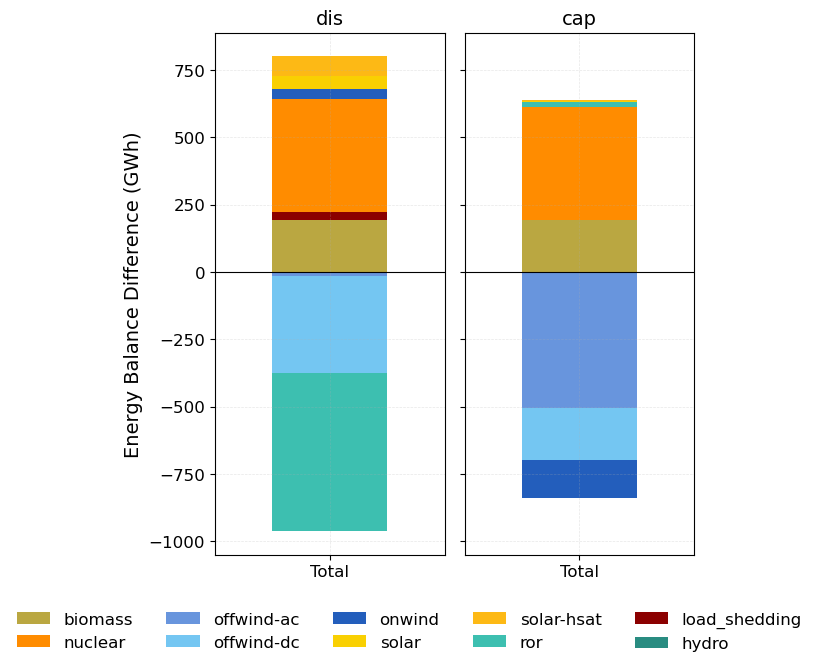

In [102]:
diff = compute_stats_diff(stats, base="base")
diff = format_stats_df(diff, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])
plot_stats_bar(
    diff[
        diff["tech"].isin(SUP_CARRIERS) 
        # & (diff["tech"] != "H2 electrolysis")
        & (diff["bus_carrier"] == "AC")
    ],
    column="energy_balance_diff",
    networks=["dis", "cap"],
    multiplier=1e-3,
    aggregate=True,
    title="Energy Balance Difference (GWh)",
    color_map=color_map,
    figsize=(6, 6)
)

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'base'}, xlabel='Bus', ylabel='withdrawal (TWh)'>])

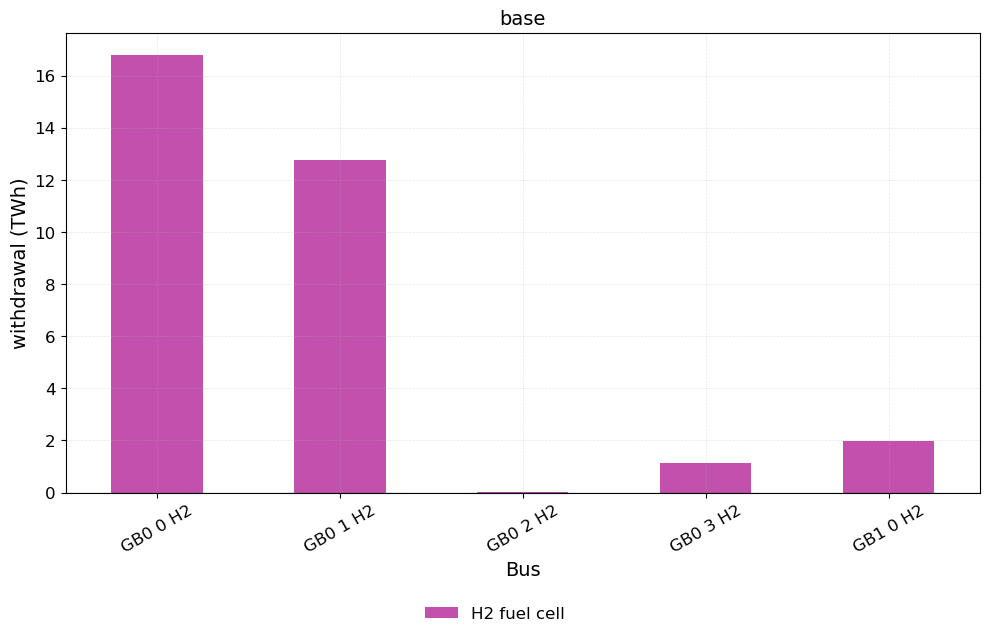

In [110]:
plot_stats_bar(
    diff[
        diff["tech"].isin(STOR_CARRIERS) &
        # diff["techgroup"].isin(["Generator", "StorageUnit"]) &
        (diff["bus_carrier"].isin(["AC", "H2"]))
    ],
    column="withdrawal",
    multiplier=1e-6,
    title="withdrawal (TWh)",
    networks=["base"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
    )

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, ylabel='withdrawal_diff (GWh)'>])

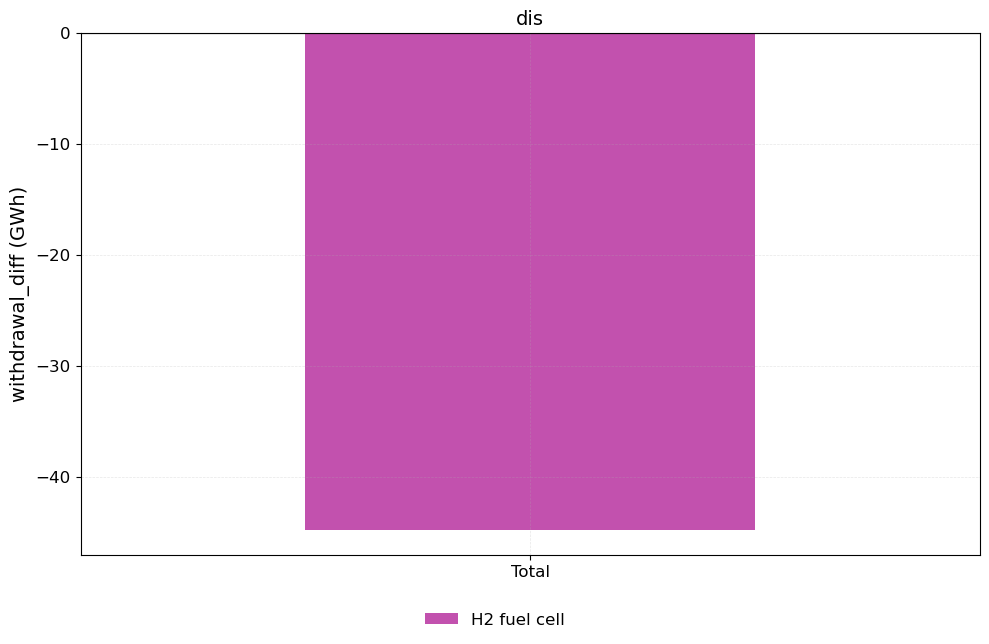

In [116]:
plot_stats_bar(
    diff[
        diff["tech"].isin(STOR_CARRIERS) &
        # diff["techgroup"].isin(["Generator", "StorageUnit"]) &
        (diff["bus_carrier"].isin(["AC", "H2"]))
    ],
    column="withdrawal_diff",
    multiplier=1e-3,
    title="withdrawal_diff (GWh)",
    networks=["dis"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6),
    aggregate=True
    )

In [119]:
CHARGE_CARRIERS

['H2 electrolysis', 'H2 fuel cell', 'battery', 'PHS']

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, ylabel='energy_balance_diff (GWh)'>])

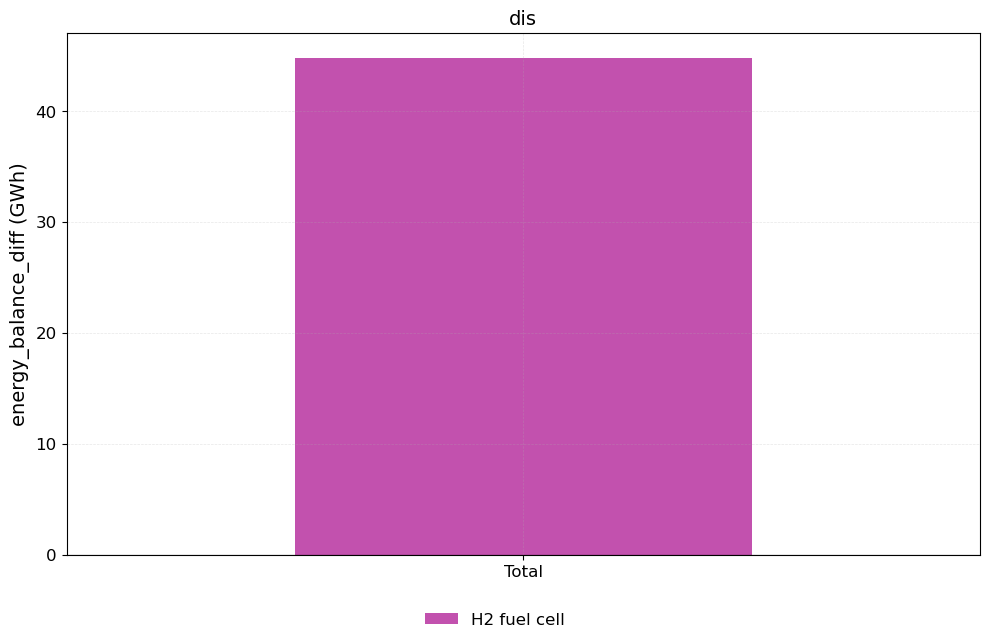

In [124]:
plot_stats_bar(
    diff[
        diff["tech"].isin(['H2 fuel cell']) &
        # diff["techgroup"].isin(["Generator", "StorageUnit"]) &
        (diff["bus_carrier"].isin(["AC", "H2"]))
    ],
    column="energy_balance_diff",
    multiplier=1e-3,
    title="energy_balance_diff (GWh)",
    networks=["dis"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6),
    aggregate=True
    )

In [114]:
STOR_CARRIERS

['H2 fuel cell']

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'dis'}, ylabel='withdrawal_diff (GWh)'>])

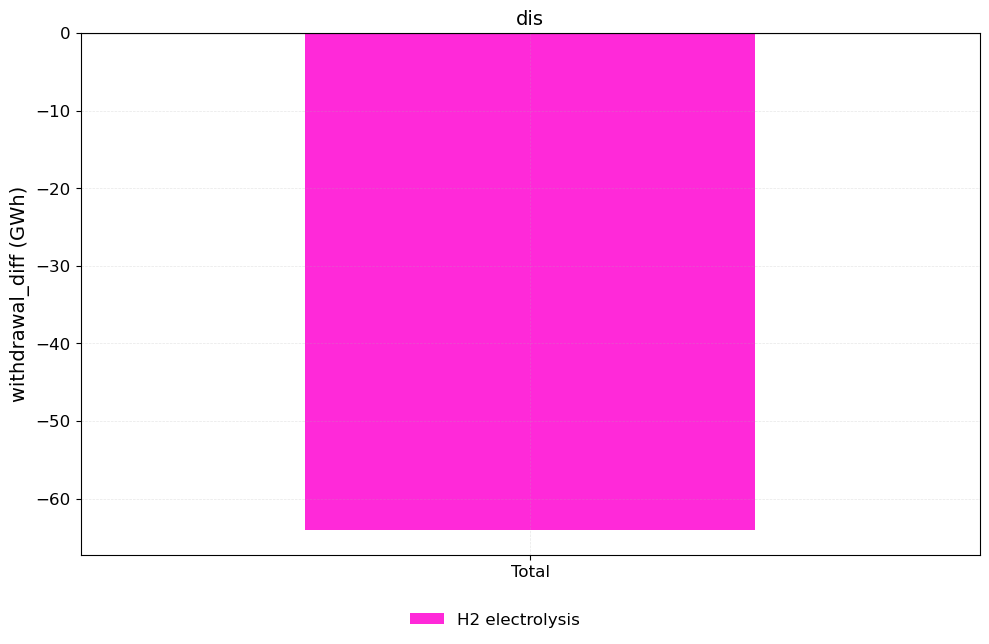

In [123]:
plot_stats_bar(
    diff[
        diff["tech"].isin(['H2 electrolysis']) &
        # diff["techgroup"].isin(["Generator", "StorageUnit"]) &
        (diff["bus_carrier"].isin(["AC", "H2"]))
    ],
    column="withdrawal_diff",
    multiplier=1e-3,
    title="withdrawal_diff (GWh)",
    networks=["dis"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6),
    aggregate=True
    )

(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: title={'center': 'dis'}, xlabel='Bus', ylabel='Energy Balance Difference (TWh)'>,
        <Axes: title={'center': 'cap'}, xlabel='Bus'>], dtype=object))

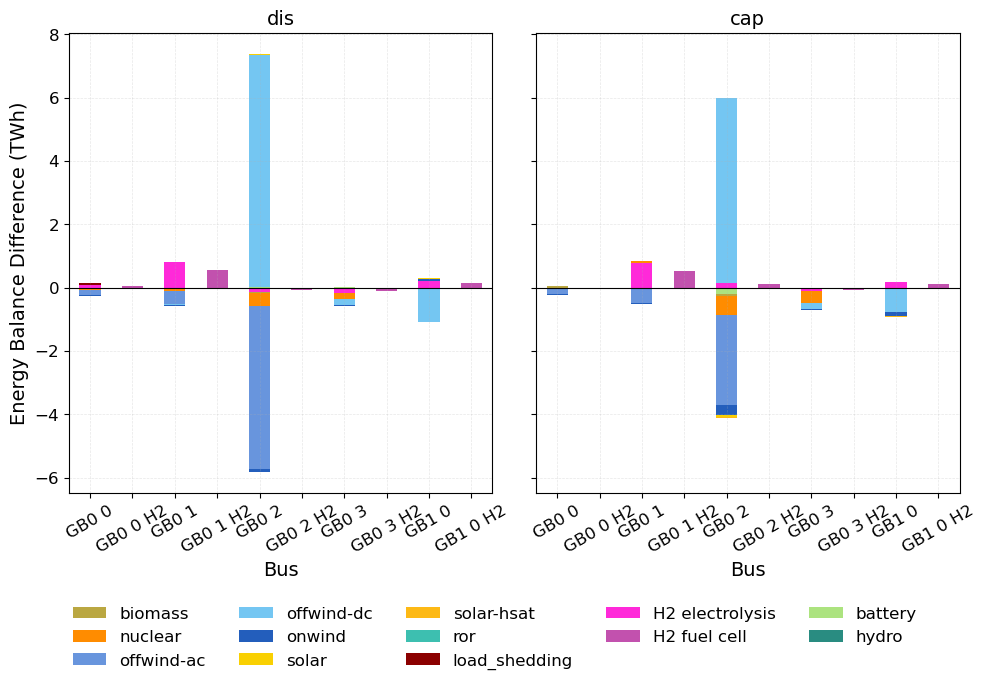

In [ ]:
plot_stats_bar(
    diff[
        diff["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS + STOR_CARRIERS)
        # (diff["bus_carrier"] == "AC")
    ],
    column="energy_balance_diff",
    multiplier=1e-6,
    title="Energy Balance Difference (TWh)",
    networks=["dis", "cap"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
    )

(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: title={'center': 'dis'}, xlabel='Bus', ylabel='Supply Difference (TWh)'>,
        <Axes: title={'center': 'cap'}, xlabel='Bus'>], dtype=object))

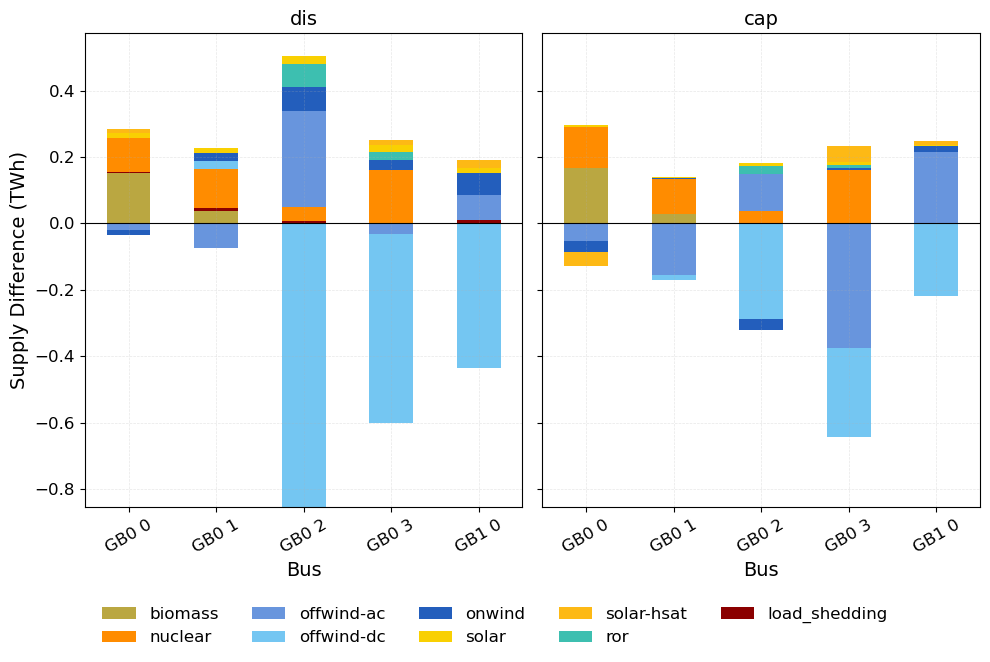

In [70]:
plot_stats_bar(
    diff[
        diff["tech"].isin(SUP_CARRIERS) &
        (diff["bus_carrier"] == "AC")
    ],
    column="supply_diff",
    multiplier=1e-6,
    title="Supply Difference (TWh)",
    networks=["dis", "cap"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
    )

In [43]:
diff.columns

Index(['techgroup', 'network', 'bus', 'tech', 'bus_carrier',
       'optimal capacity', 'installed capacity', 'supply', 'withdrawal',
       'energy balance', 'transmission', 'capacity factor', 'curtailment',
       'capital expenditure', 'operational expenditure', 'revenue',
       'market value', 'expanded capacity', 'optimal_capacity_diff',
       'installed_capacity_diff', 'supply_diff', 'withdrawal_diff',
       'energy_balance_diff', 'transmission_diff', 'capacity_factor_diff',
       'curtailment_diff', 'capital_expenditure_diff',
       'operational_expenditure_diff', 'revenue_diff', 'market_value_diff',
       'expanded_capacity_diff'],
      dtype='object')

In [44]:
CHARGE_CARRIERS

['H2 electrolysis', 'battery']

In [73]:
plot_stats_bar(
    diff_off[
        diff_off["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)
        # diff["techgroup"].isin(["Generator", "StorageUnit"])
        # & (diff["bus_carrier"] == "AC")
    ],
    column="optimal capacity",
    multiplier=1e-3,
    title="Optimal Capacity (GW)",
    networks=["base"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

NameError: name 'diff_off' is not defined

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'base'}, xlabel='Bus', ylabel='Optimal Capacity (GW)'>])

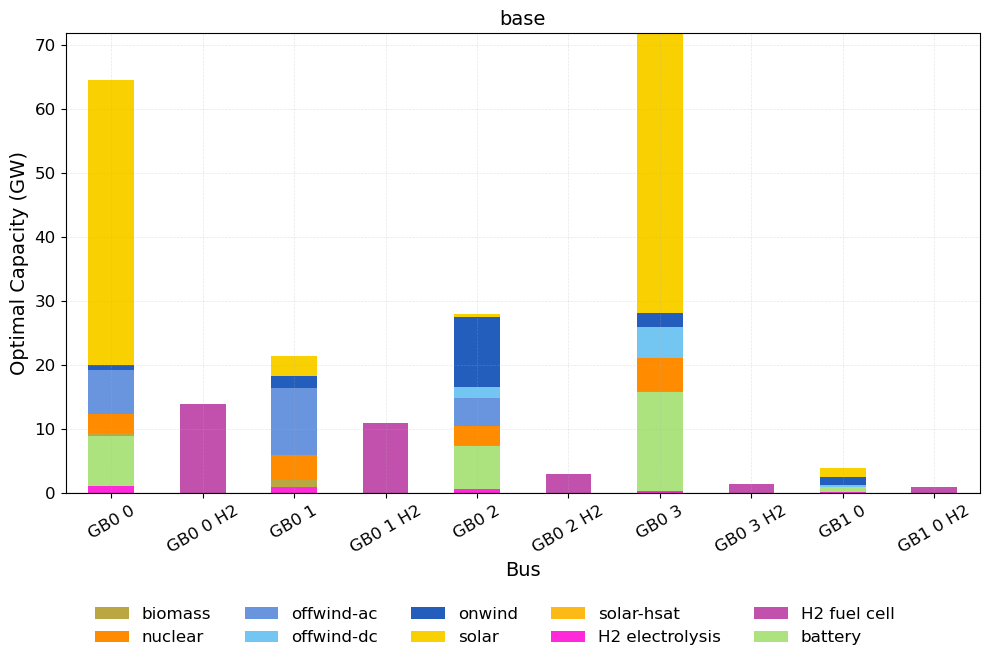

In [ ]:
plot_stats_bar(
    diff[
        diff["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)
        # diff["techgroup"].isin(["Generator", "StorageUnit"])
        # & (diff["bus_carrier"] == "AC")
    ],
    column="optimal capacity",
    multiplier=1e-3,
    title="Optimal Capacity (GW)",
    networks=["base"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'cap'}, xlabel='Bus', ylabel='Optimal Capacity Diff (GW)'>])

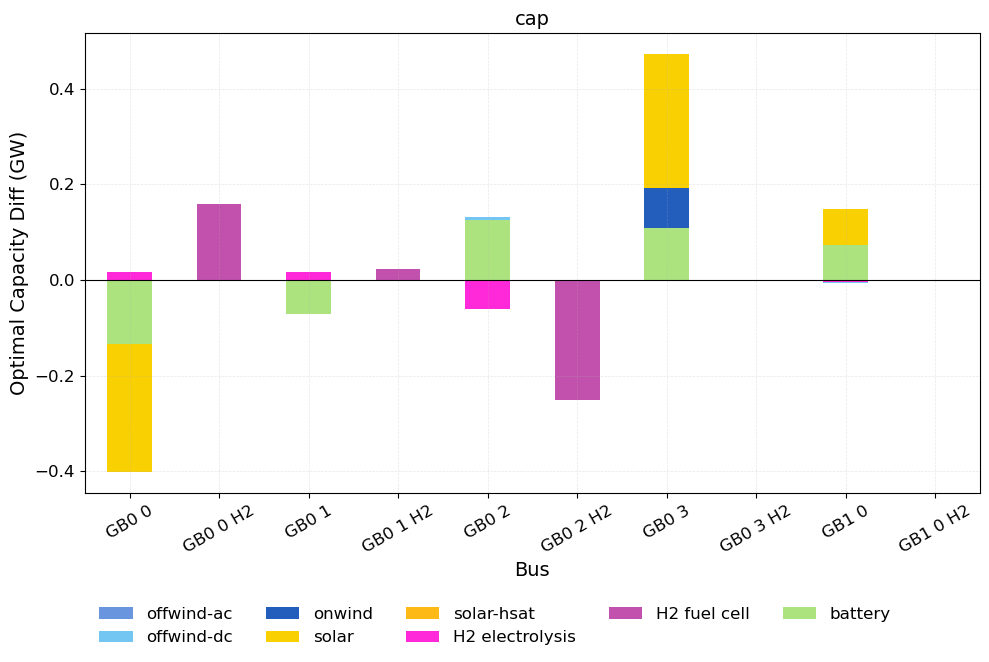

In [42]:
plot_stats_bar(
    diff_off[
        diff_off["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)
        # diff["techgroup"].isin(["Generator", "StorageUnit"])
        # & (diff["bus_carrier"] == "AC")
    ],
    column="optimal_capacity_diff",
    multiplier=1e-3,
    title="Optimal Capacity Diff (GW)",
    networks=["cap"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'base'}, xlabel='Bus', ylabel='Optimal Capacity (GW)'>])

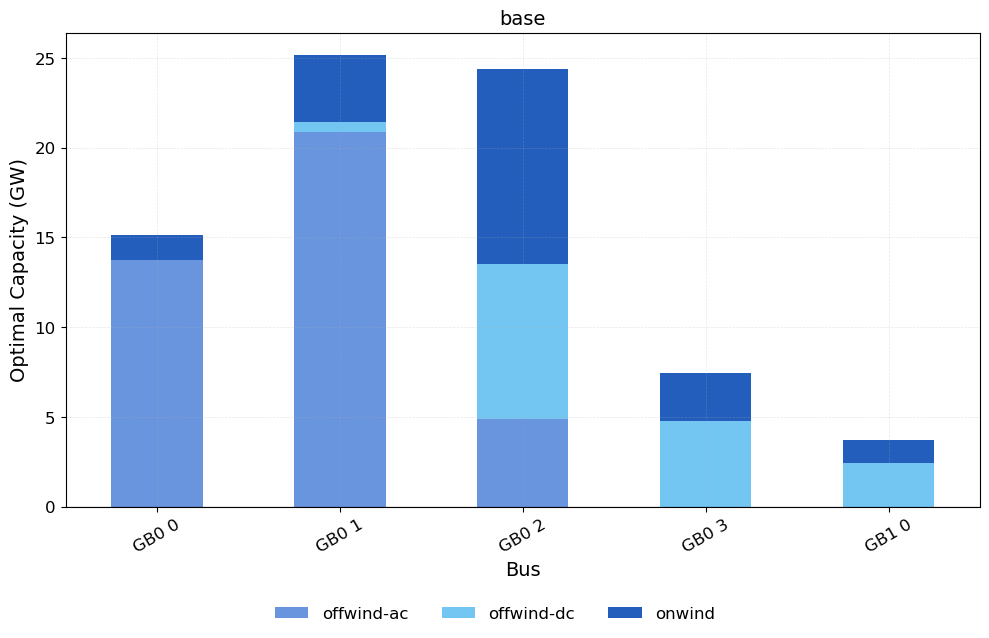

In [63]:
plot_stats_bar(
    diff[
        diff["tech"].isin(CARRIERS_TO_PLOT)
        # diff["techgroup"].isin(["Generator", "StorageUnit"])
        # & (diff["bus_carrier"] == "AC")
    ],
    column="optimal capacity",
    multiplier=1e-3,
    title="Optimal Capacity (GW)",
    networks=["base"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'cap'}, xlabel='Bus', ylabel='Optimal Capacity Diff (GW)'>])

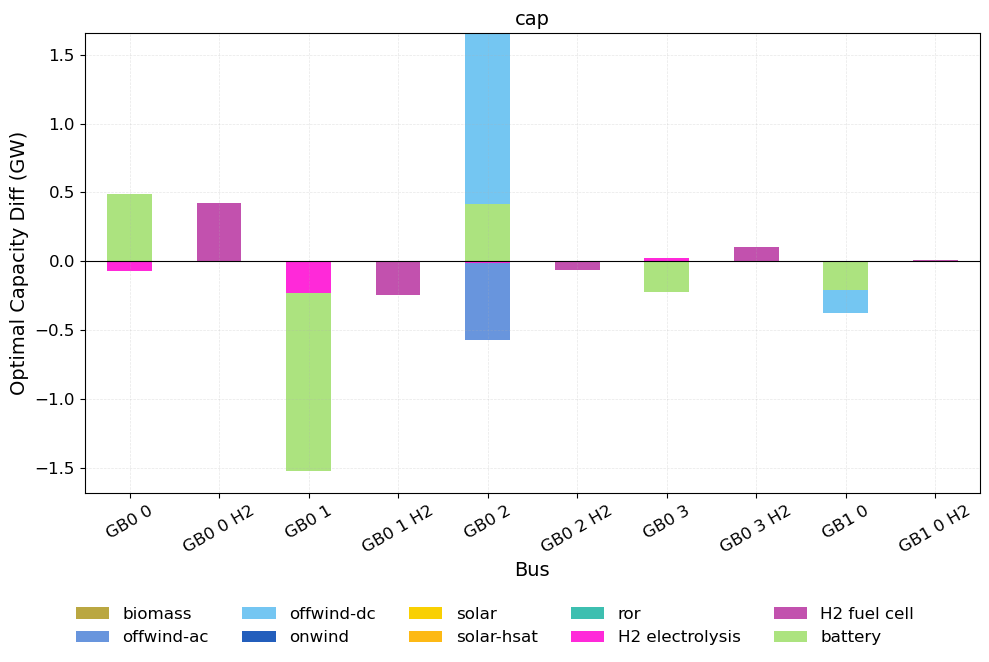

In [62]:
plot_stats_bar(
    diff[
        diff["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)
        # diff["techgroup"].isin(["Generator", "StorageUnit"])
        # & (diff["bus_carrier"] == "AC")
    ],
    column="optimal_capacity_diff",
    multiplier=1e-3,
    title="Optimal Capacity Diff (GW)",
    networks=["cap"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'cap'}, xlabel='Bus', ylabel='Optimal Capacity Diff (GW)'>])

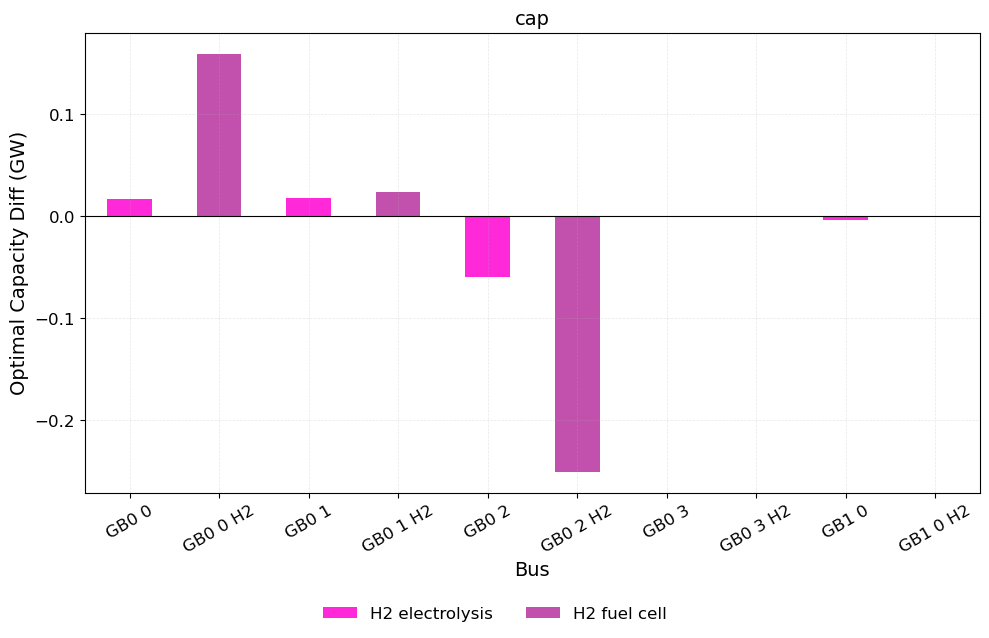

In [43]:
plot_stats_bar(
    diff_off[
        # diff["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)
        diff_off["techgroup"].isin(["Line", "Link"])
        # & (diff["bus_carrier"] == "AC")
    ],
    column="optimal_capacity_diff",
    multiplier=1e-3,
    title="Optimal Capacity Diff (GW)",
    networks=["cap"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'cap_line-on'}, xlabel='Bus', ylabel='Optimal Capacity Diff (GW)'>])

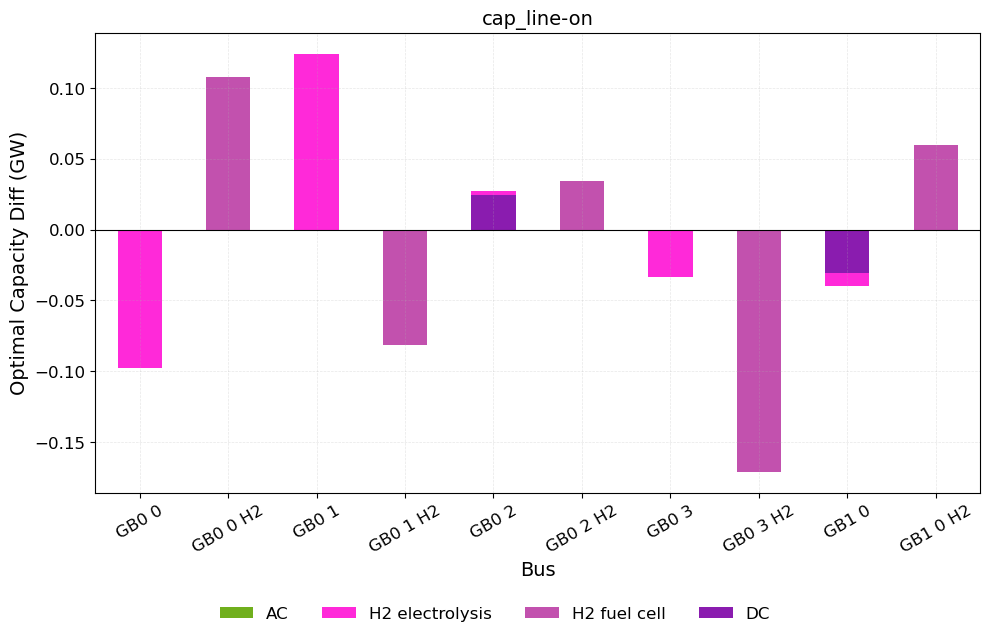

In [44]:
plot_stats_bar(
    diff_on[
        # diff["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)
        diff_on["techgroup"].isin(["Line", "Link"])
        # & (diff["bus_carrier"] == "AC")
    ],
    column="optimal_capacity_diff",
    multiplier=1e-3,
    title="Optimal Capacity Diff (GW)",
    networks=["cap_line-on"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: title={'center': 'base'}, xlabel='Bus', ylabel='Expanded Capacity (GW)'>,
        <Axes: title={'center': 'cap'}, xlabel='Bus'>], dtype=object))

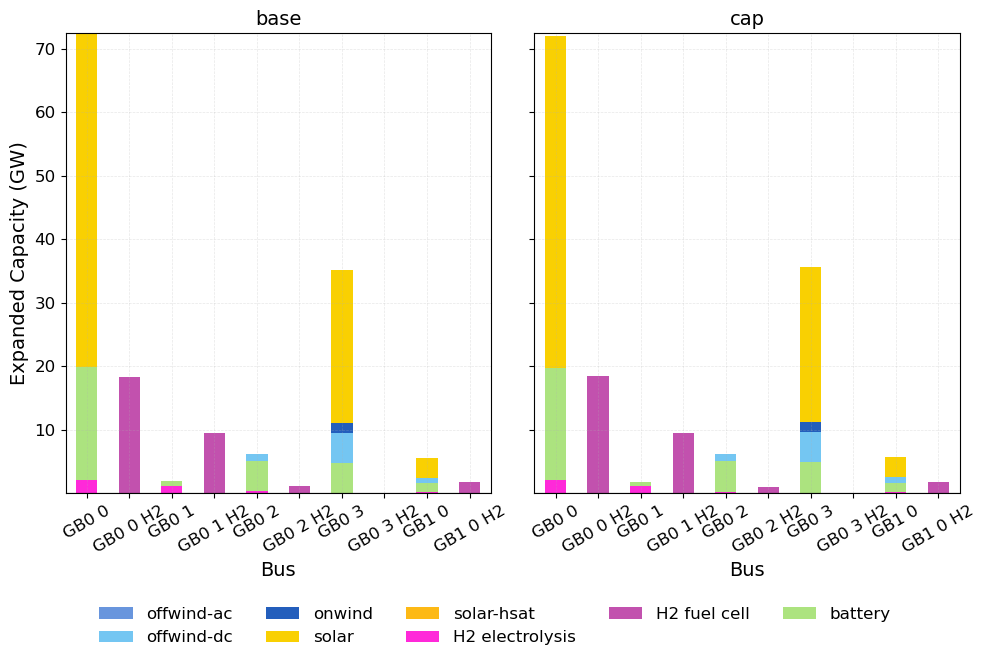

In [45]:
plot_stats_bar(
    diff_off[
        diff_off["tech"].isin(SUP_CARRIERS + CHARGE_CARRIERS)
        # diff["techgroup"].isin(["Generator", "StorageUnit"]) &
        # (diff["bus_carrier"] == "AC")
    ],
    column="expanded capacity",
    multiplier=1e-3,
    title="Expanded Capacity (GW)",
    networks=["base", "cap"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

In [48]:
diff.tech.unique()

array(['CCGT', 'biomass', 'nuclear', 'offwind-ac', 'offwind-dc',
       'offwind-float', 'onwind', 'solar', 'solar-hsat', 'coal',
       'load_shedding', 'AC', 'H2 electrolysis', 'H2 fuel cell', 'DC', '',
       'battery', 'H2'], dtype=object)

In [49]:
CARRIERS_TO_PLOT

['onwind', 'offwind-ac', 'offwind-dc']

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'cap'}, xlabel='Bus', ylabel='expanded_capacity_diff'>])

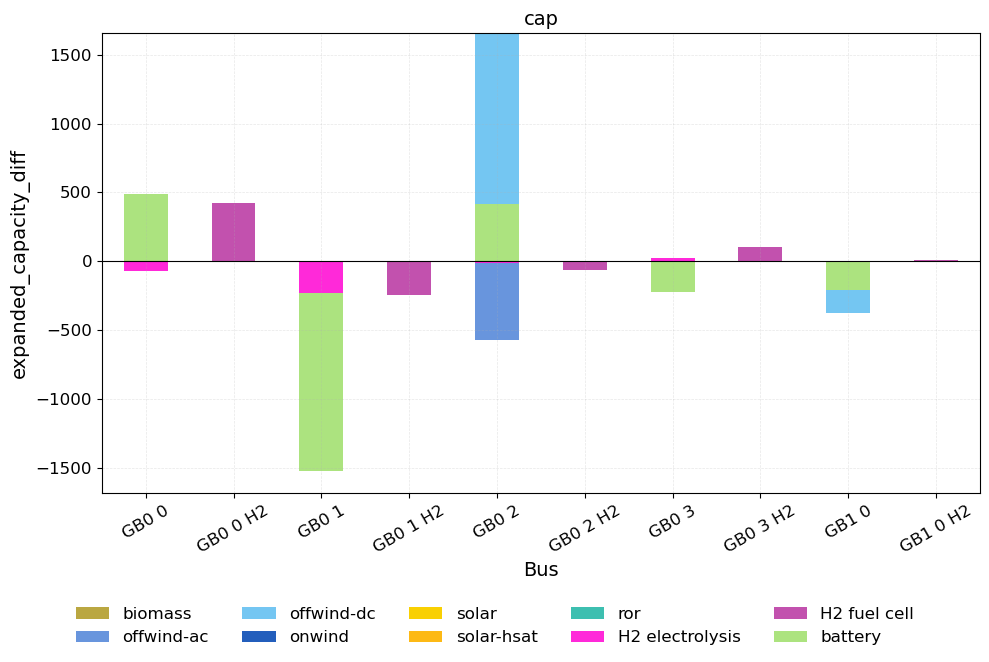

In [82]:
diff2 = compute_stats_diff(stats, base="base")
diff2 = format_stats_df(diff2, index_names=["techgroup", "network", "bus", "tech", "bus_carrier"])


plot_stats_bar(
    diff2[
        # diff2["tech"].isin(CARRIERS_TO_PLOT) &
        diff2["techgroup"].isin(["Generator", "StorageUnit", "Link"])
        # (diff2["bus_carrier"] == "AC")
    ],
    column="expanded_capacity_diff",
    networks=["cap"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'cap'}, xlabel='Bus', ylabel='expanded_capacity_diff'>])

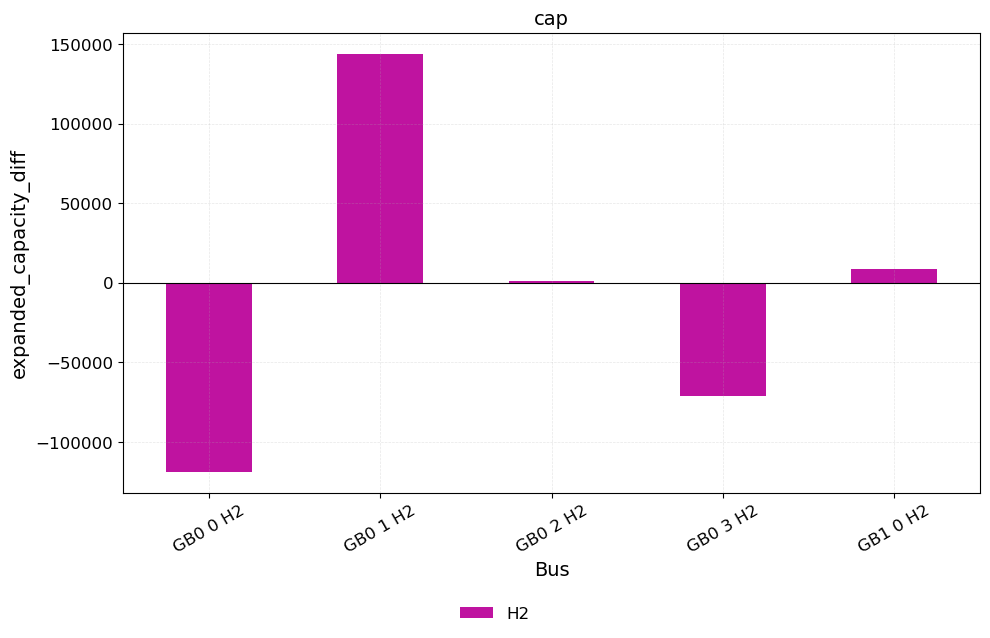

In [171]:
plot_stats_bar(
    diff[
        # diff["tech"].isin(CARRIERS_TO_PLOT) &
        diff["techgroup"].isin(["Store"]) &
        (diff["bus_carrier"] == "H2")
    ],
    column="expanded_capacity_diff",
    networks=["cap"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

In [173]:
diff["techgroup"].unique()

array(['Generator', 'Line', 'Link', 'Load', 'StorageUnit', 'Store'],
      dtype=object)

(<Figure size 1000x600 with 1 Axes>,
 [<Axes: title={'center': 'cap'}, xlabel='Bus', ylabel='expanded_capacity_diff'>])

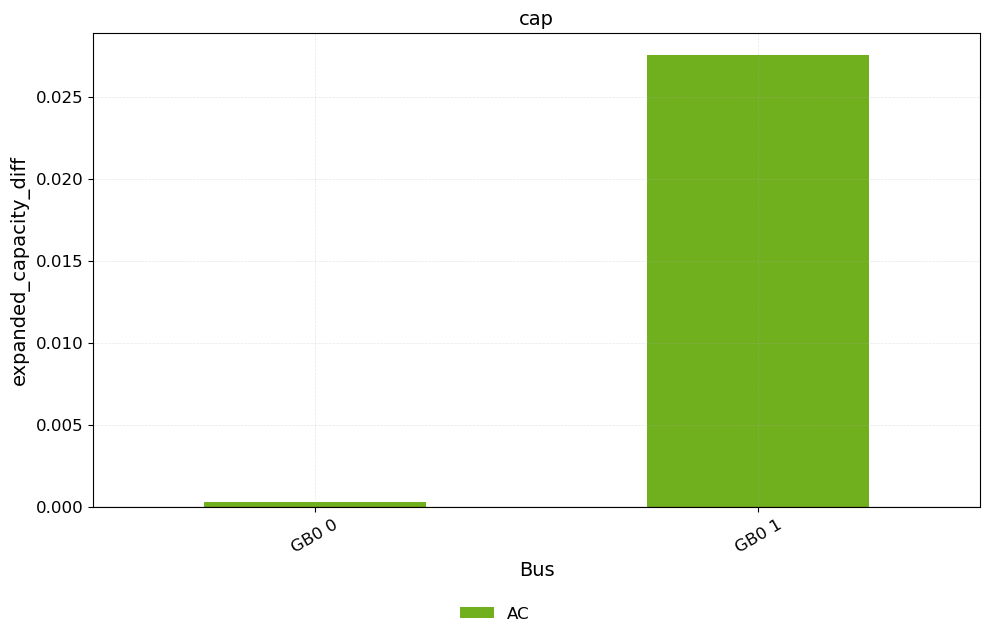

In [180]:
plot_stats_bar(
    diff[
        # diff["tech"].isin(CARRIERS_TO_PLOT) &
        diff["techgroup"].isin(["Line"]) &
        (diff["bus_carrier"] == "AC")
    ],
    column="expanded_capacity_diff",
    networks=["cap"],
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(10, 6)
)

In [51]:
iplot_stats_bar(diff, column="supply_diff", networks=["cap", "dis"], color_map=networks["base"].carriers.color.to_dict(),)

## Energy Balance

In [13]:
def format_ts_df(nc, stat="energy_balance", **stat_kwargs):
    result = getattr(nc.statistics, stat)(
        groupby=["bus", "carrier", "bus_carrier"],
        groupby_time=False,
        nice_names=False,
        **stat_kwargs,
    )
    df = result.reset_index()
    meta_cols = [c for c in df.columns if not isinstance(c, pd.Timestamp)]
    ts_cols   = [c for c in df.columns if isinstance(c, pd.Timestamp)]
    df = df.melt(id_vars=meta_cols, value_vars=ts_cols, var_name="snapshot", value_name="value")
    return df


# _CARRIER_COLOR_OVERRIDES = {"load_shedding": "darkred"}


In [14]:
def format_ts_diff_df(
    networks: dict,
    stat: str = "energy_balance",
    base: str = "base",
    **stat_kwargs,
) -> pd.DataFrame:
    """
    Long-format time-series statistics with a difference column relative to a base network.

    Parameters
    ----------
    networks  : dict of {label: pypsa.Network}
    stat      : statistics method name (default "energy_balance")
    base      : key in networks to use as baseline
    **stat_kwargs : passed through to the statistics call

    Returns
    -------
    DataFrame with columns:
        bus, carrier, bus_carrier, snapshot, value, value_diff
    and an added 'network' column identifying the scenario.
    """
    if base not in networks:
        raise ValueError(f"Base label {base!r} not found in networks.")

    all_dfs = []
    for label, nc in networks.items():
        df = format_ts_df(nc, stat=stat, **stat_kwargs)
        df["network"] = label
        all_dfs.append(df)

    combined = pd.concat(all_dfs, ignore_index=True)

    merge_keys = ["bus", "carrier", "bus_carrier", "snapshot"]
    base_df = (
        combined[combined["network"] == base][merge_keys + ["value"]]
        .rename(columns={"value": "_base_value"})
    )

    combined = combined.merge(base_df, on=merge_keys, how="left")
    combined["_base_value"] = combined["_base_value"].fillna(0)
    combined["value"] = combined["value"].fillna(0)
    combined["value_diff"] = combined["value"] - combined["_base_value"]
    combined.drop(columns="_base_value", inplace=True)

    return combined


In [15]:
ts_diff = format_ts_diff_df(networks, stat="energy_balance", base="base")
ts_diff

,component,bus,carrier,bus_carrier,snapshot,value,network,value_diff
0,Generator,GB0 0,CCGT,AC,2021-06-01 00:00:00,0.00000,base,0.00000
1,Generator,GB0 0,biomass,AC,2021-06-01 00:00:00,4198.99289,base,0.00000
2,Generator,GB0 0,nuclear,AC,2021-06-01 00:00:00,2058.83084,base,0.00000
3,Generator,GB0 0,offwind-ac,AC,2021-06-01 00:00:00,5406.78248,base,0.00000
4,Generator,GB0 0,offwind-dc,AC,2021-06-01 00:00:00,0.16137,base,0.00000
...,...,...,...,...,...,...,...,...
3941995,Store,GB0 0 H2,H2,H2,2022-05-31 23:00:00,743.94429,dis,156.71184
3941996,Store,GB0 1 H2,H2,H2,2022-05-31 23:00:00,1517.36799,dis,378.39082
3941997,Store,GB0 2 H2,H2,H2,2022-05-31 23:00:00,0.32163,dis,0.04044
3941998,Store,GB0 3 H2,H2,H2,2022-05-31 23:00:00,0.00023,dis,-0.08867


In [16]:
def plot_stats_area(
    df,
    *,
    networks,
    bus_carriers,
    date_range=None,
    color_map=None,
    title=None,
    multiplier=1.0,
    show_legend=True,
    aggregate=False,
    facet_col="network",
    facet_row="bus_carrier",
    figsize=(14, 5),
    carrier_order=None,
):
    data = df[df["network"].isin(networks)].copy()
    data = data[data["bus_carrier"].isin(bus_carriers)]
    if date_range is not None:
        start, end = pd.Timestamp(date_range[0]), pd.Timestamp(date_range[1])
        data = data[(data["snapshot"] >= start) & (data["snapshot"] <= end)]
    if multiplier != 1.0:
        data["value"] = data["value"] * multiplier

    effective_map = {**(color_map or {}), **_CARRIER_COLOR_OVERRIDES}

    col_vals = networks     if facet_col == "network" else bus_carriers
    row_vals = bus_carriers if facet_row == "bus_carrier" else networks

    print(" | ".join(str(cv) for cv in col_vals))

    if aggregate:
        row_index = [(rv, None) for rv in row_vals]
    else:
        row_index = [
            (rv, bus)
            for rv in row_vals
            for bus in sorted(data[data[facet_row] == rv]["bus"].unique())
        ]

    n_rows, n_cols = len(row_index), len(col_vals)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharey=False, squeeze=False)

    for row_i, (rv, bus) in enumerate(row_index):
        for col_i, cv in enumerate(col_vals):
            ax = axes[row_i, col_i]
            slice_ = data[(data[facet_col] == cv) & (data[facet_row] == rv)]
            if bus is not None:
                slice_ = slice_[slice_["bus"] == bus]

            pivot = (
                slice_.groupby(["snapshot", "carrier"])["value"]
                .sum()
                .unstack(fill_value=0)
            )

            if pivot.empty:
                ax.set_visible(False)
                continue

            if carrier_order is not None:
                ordered = [c for c in carrier_order if c in pivot.columns]
                rest    = [c for c in pivot.columns if c not in carrier_order]
                pivot   = pivot[ordered + rest]

            for clipped in [pivot.clip(lower=0), pivot.clip(upper=0)]:
                active = clipped.loc[:, (clipped != 0).any()]
                if active.empty:
                    continue
                colors = [effective_map.get(c) or "#aaaaaa" for c in active.columns]
                ax.stackplot(active.index, active.T.values, colors=colors, alpha=0.85)

            ax.axhline(0, color="black", linewidth=0.8)
            ax.grid(True, axis="y", alpha=0.3, linestyle="--", linewidth=0.5)
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
            ax.tick_params(axis="x", rotation=30)

            if col_i == 0:
                row_label = rv if bus is None else f"{rv} | {bus}"
                ax.set_ylabel(f"{row_label}\n{title or 'value'}")

    if show_legend:
        all_carriers = data["carrier"].unique()
        handles = [mpatches.Patch(facecolor=effective_map.get(c) or "#aaaaaa", label=c) for c in all_carriers]
        ncols = min(len(handles), 5)
        fig.tight_layout()
        ax_bottom = min(ax.get_position().y0 for ax in axes[-1])
        fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, ax_bottom - 0.03),
                   bbox_transform=fig.transFigure, ncol=ncols, frameon=False)
    else:
        fig.tight_layout()

    return fig, axes


In [17]:
EXCLUDE_gen_storage = ["coal", "ocgt", "CCGT", "offwind-float"]
ts_eb = format_ts_df(nc, stat="energy_balance")
ts_eb = ts_eb[~ts_eb["carrier"].isin(EXCLUDE_gen_storage)]

In [86]:
ts_eb[(ts_eb["component"] == "Line") & (ts_eb["bus"] == "GB0 1")]["value"].describe()

count    43800.000000
mean      4738.488096
std       2315.834673
min      -3020.079490
25%       3246.362520
50%       4594.227200
75%       6120.462288
max      15473.382630
Name: value, dtype: float64

In [19]:
carrier_order = ['nuclear', 'biomass','ror','offwind-ac', 'offwind-dc', 'onwind', 'solar', 'solar-hsat', 
                 'AC', 'H2 electrolysis', 'H2 fuel cell', '', 'battery', 'hydro', 'PHS',
       'H2', 'load_shedding', 'load']

_CARRIER_COLOR_OVERRIDES = _color_overrides

AC


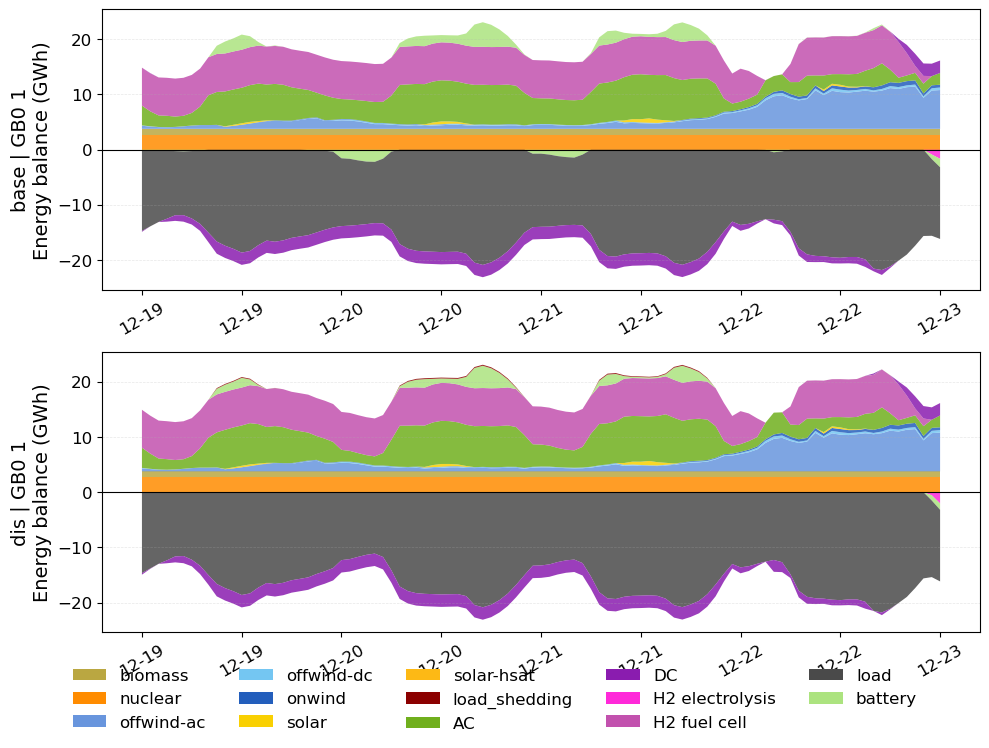

In [36]:
fig, axes = plot_stats_area(
    ts_eb[ts_eb["component"].isin(["Generator", "StorageUnit", "Link", "Store", "Load", "Line"])
          & (ts_eb["bus"] == "GB0 1")
          ],
    networks=["base", "dis"],
    bus_carriers=["AC"],
    facet_col="bus_carrier",
    facet_row="network",
    date_range=("2021-12-19", "2021-12-23"),    
    aggregate=False,
    carrier_order = carrier_order,
    color_map=color_map,
    multiplier=1e-3,
    title="Energy balance (GWh)",
    figsize=(10, 7),
    show_legend=True
)

# effective_map = {**color_map}
# all_carriers = ts_eb[ts_eb["network"].isin(["base"])]["carrier"].unique()
# keep = set(SUP_CARRIERS + CHARGE_CARRIERS + STOR_CARRIERS + ["load"])
# handles = [mpatches.Patch(facecolor=effective_map.get(c, "#aaaaaa"), label=c)
#            for c in carrier_order if c in all_carriers and c in keep]

# fig.legend(handles=handles, loc="upper center",
#            bbox_to_anchor=(0.5, 0.02), bbox_transform=fig.transFigure,
#            ncol=min(len(handles), 5), frameon=False, fontsize=14)
# fig.tight_layout()
plt.show()




In [86]:
CARRIERS_LIST = ["onwind", "offwind-ac", "offwind-dc", "load_shedding"]

AC


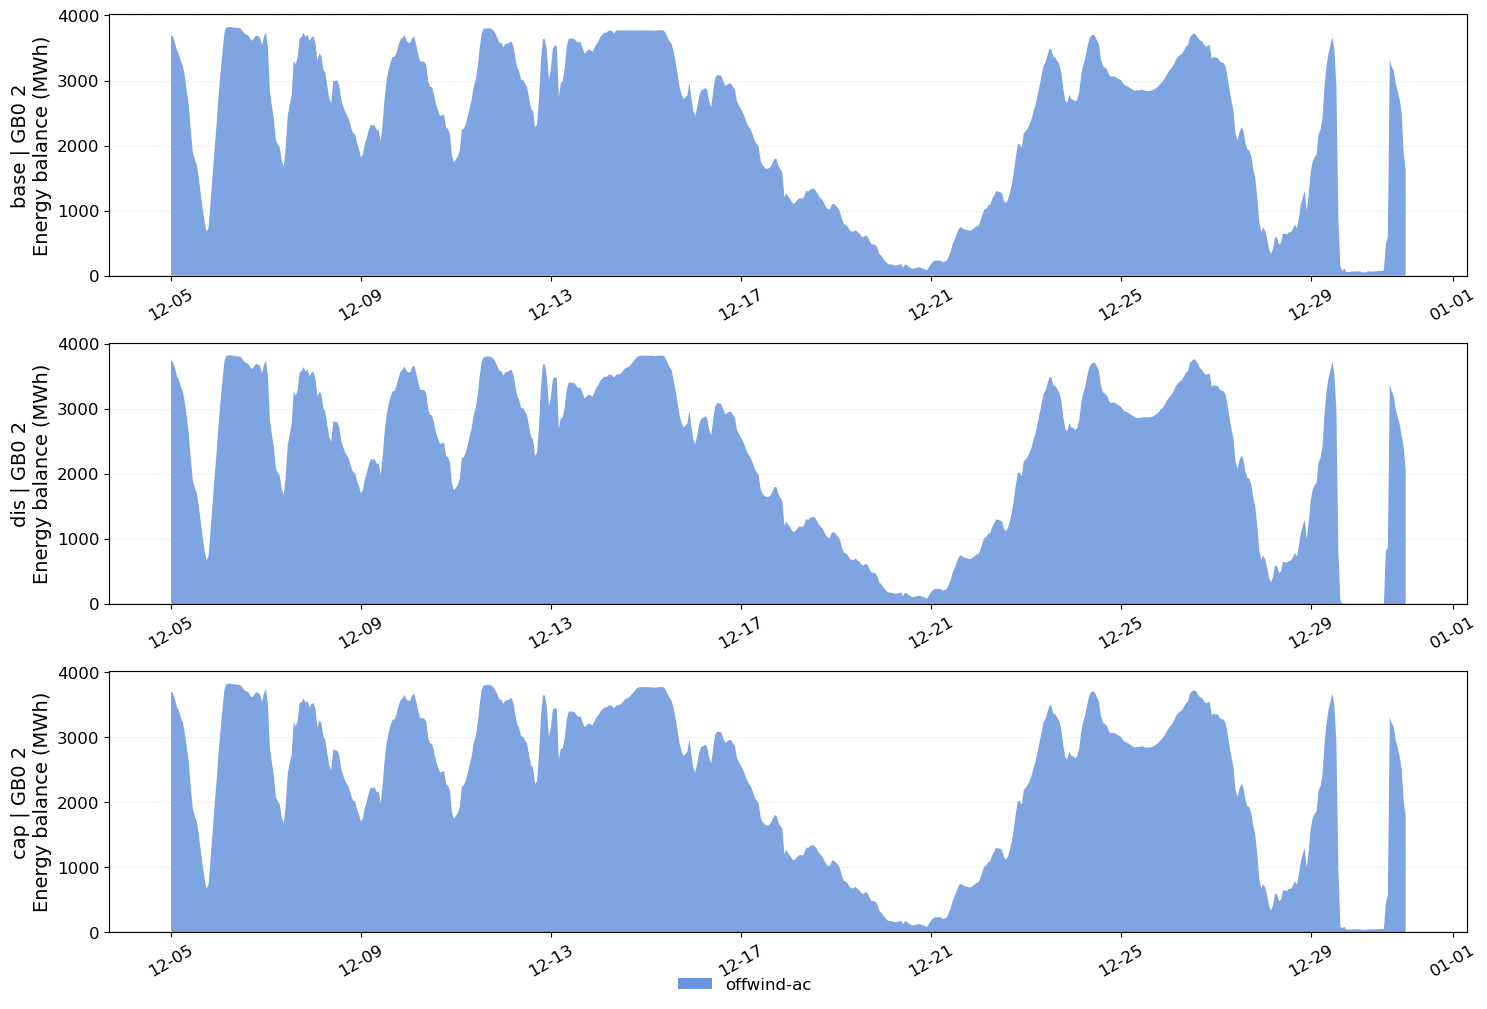

In [112]:
fig, axes = plot_stats_area(
    ts_eb[ts_eb["component"].isin(["Generator", "StorageUnit", "Link", "Store", "Load", "Line"])
          & (ts_eb["bus"] == "GB0 2")
          & ts_eb["carrier"].isin(["offwind-ac"])
    ],
    networks=["base", "dis", "cap"],
    bus_carriers=["AC"],
    facet_col="bus_carrier",
    facet_row="network",
    date_range=("2021-12-05", "2021-12-31"),
    aggregate=False,
    color_map=networks["base"].carriers.color.to_dict(),
    title="Energy balance (MWh)",
    figsize=(15, 10),
)

AC


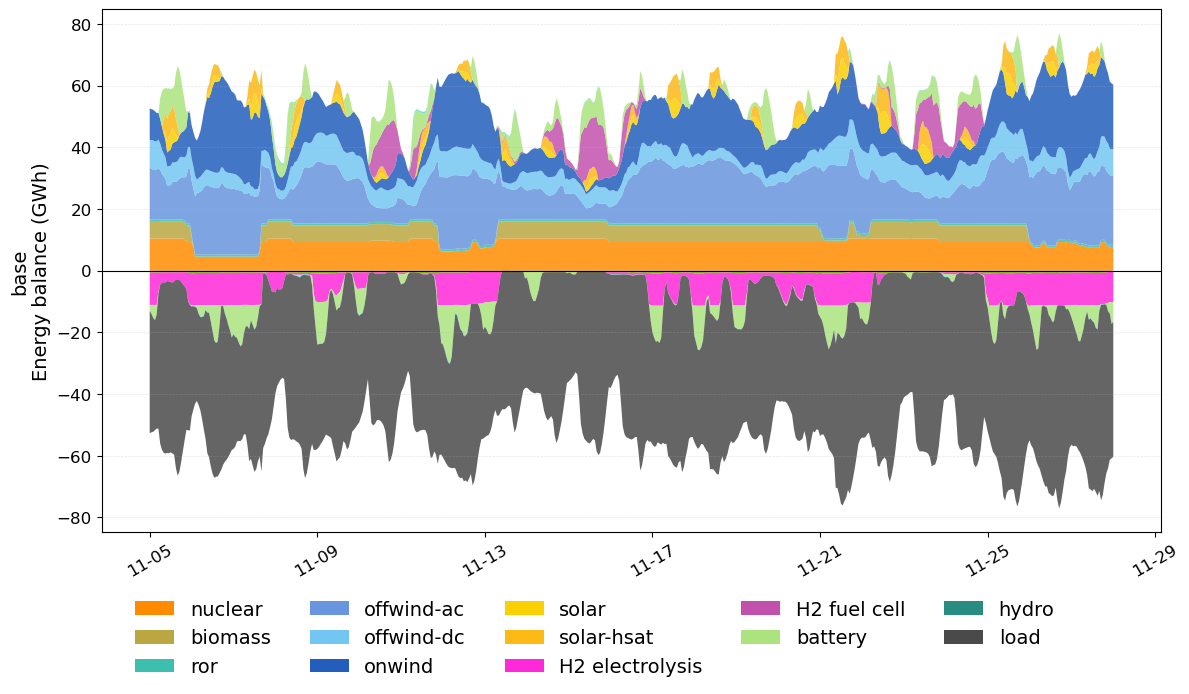

In [98]:
fig, axes = plot_stats_area(
    ts_eb[ts_eb["component"].isin(["Generator", "StorageUnit", "Link", "Store", "Load", "Line"])
        #   & (ts_eb["bus"] == "GB1 0")
        ],
    networks=["base"],
    bus_carriers=["AC"],
    facet_col="bus_carrier",
    facet_row="network",
    date_range=("2021-11-05", "2021-11-28"),
    aggregate=True,
    color_map=networks["base"].carriers.color.to_dict(),
    carrier_order = carrier_order,
    multiplier=1e-3,
    title="Energy balance (GWh)",
    figsize=(12, 6),
    show_legend=False
)
effective_map = {**color_map}
all_carriers = ts_eb[ts_eb["network"].isin(["base"])]["carrier"].unique()
keep = set(SUP_CARRIERS + CHARGE_CARRIERS + STOR_CARRIERS + ["load"])
handles = [mpatches.Patch(facecolor=effective_map.get(c, "#aaaaaa"), label=c)
           for c in carrier_order if c in all_carriers and c in keep]

fig.legend(handles=handles, loc="upper center",
           bbox_to_anchor=(0.5, 0.02), bbox_transform=fig.transFigure,
           ncol=min(len(handles), 5), frameon=False, fontsize=14)
fig.tight_layout()
plt.show()


AC


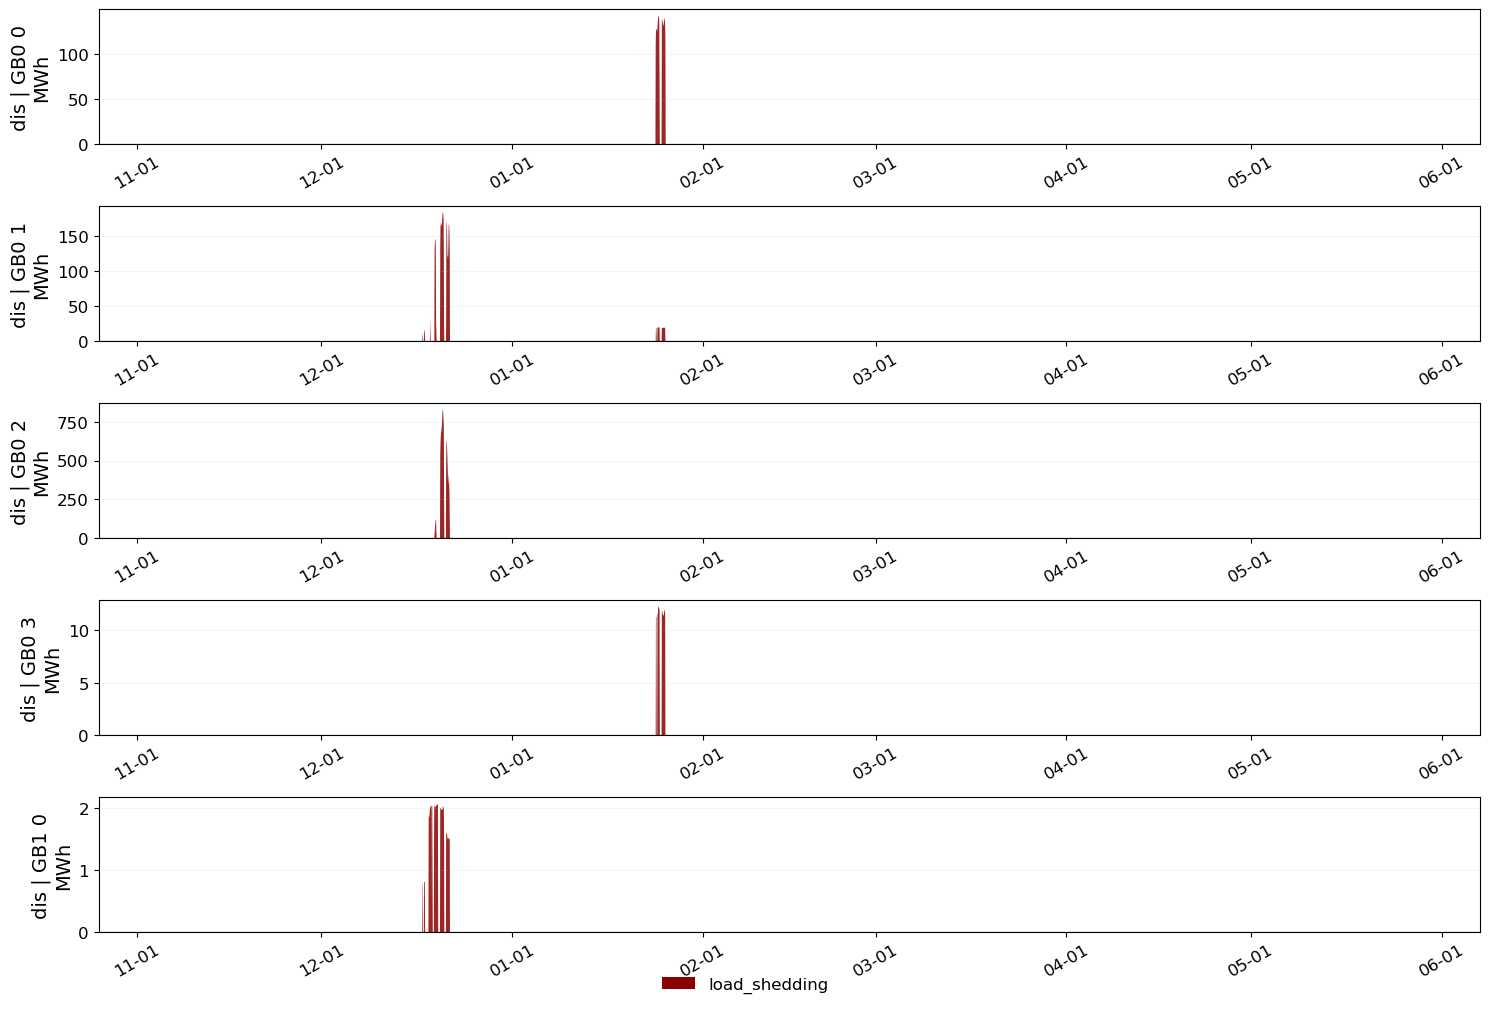

In [96]:
fig, axes = plot_stats_area(
    ts_eb[ts_eb["component"].isin(["Generator", "StorageUnit", "Link", "Store", "Load", "Line"])
        #   & (ts_eb["bus"] == "GB0 0")
          & (ts_eb["carrier"] == "load_shedding")
        ],
    networks=["dis"],
    bus_carriers=["AC"],
    facet_col="bus_carrier",
    facet_row="network",
    date_range=("2021-11-05", "2022-05-28"),
    aggregate=False,
    color_map=networks["base"].carriers.color.to_dict(),
    title="MWh",
    figsize=(15, 10),
)


AC


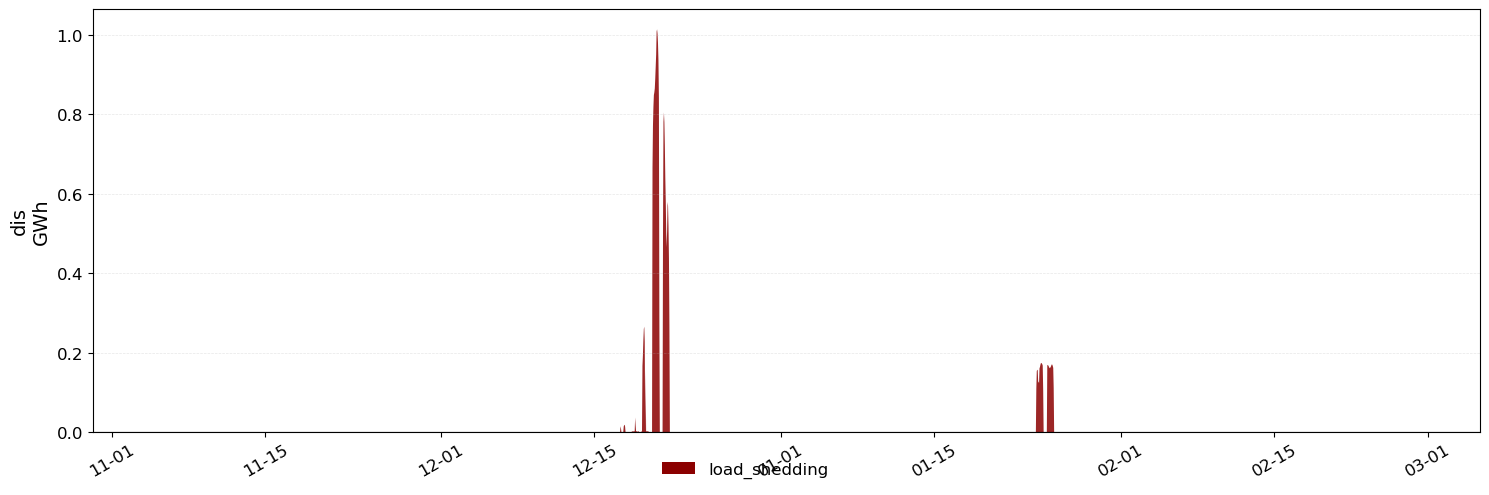

In [117]:
fig, axes = plot_stats_area(
    ts_eb[ts_eb["component"].isin(["Generator", "StorageUnit", "Link", "Store", "Load", "Line"])
        #   & (ts_eb["bus"] == "GB0 0")
          & (ts_eb["carrier"] == "load_shedding")
        ],
    networks=["dis"],
    bus_carriers=["AC"],
    facet_col="bus_carrier",
    facet_row="network",
    date_range=("2021-11-05", "2022-02-28"),
    aggregate=True,
    color_map=networks["base"].carriers.color.to_dict(),
    multiplier=1e-3,
    title="GWh",
    figsize=(15, 5),
)


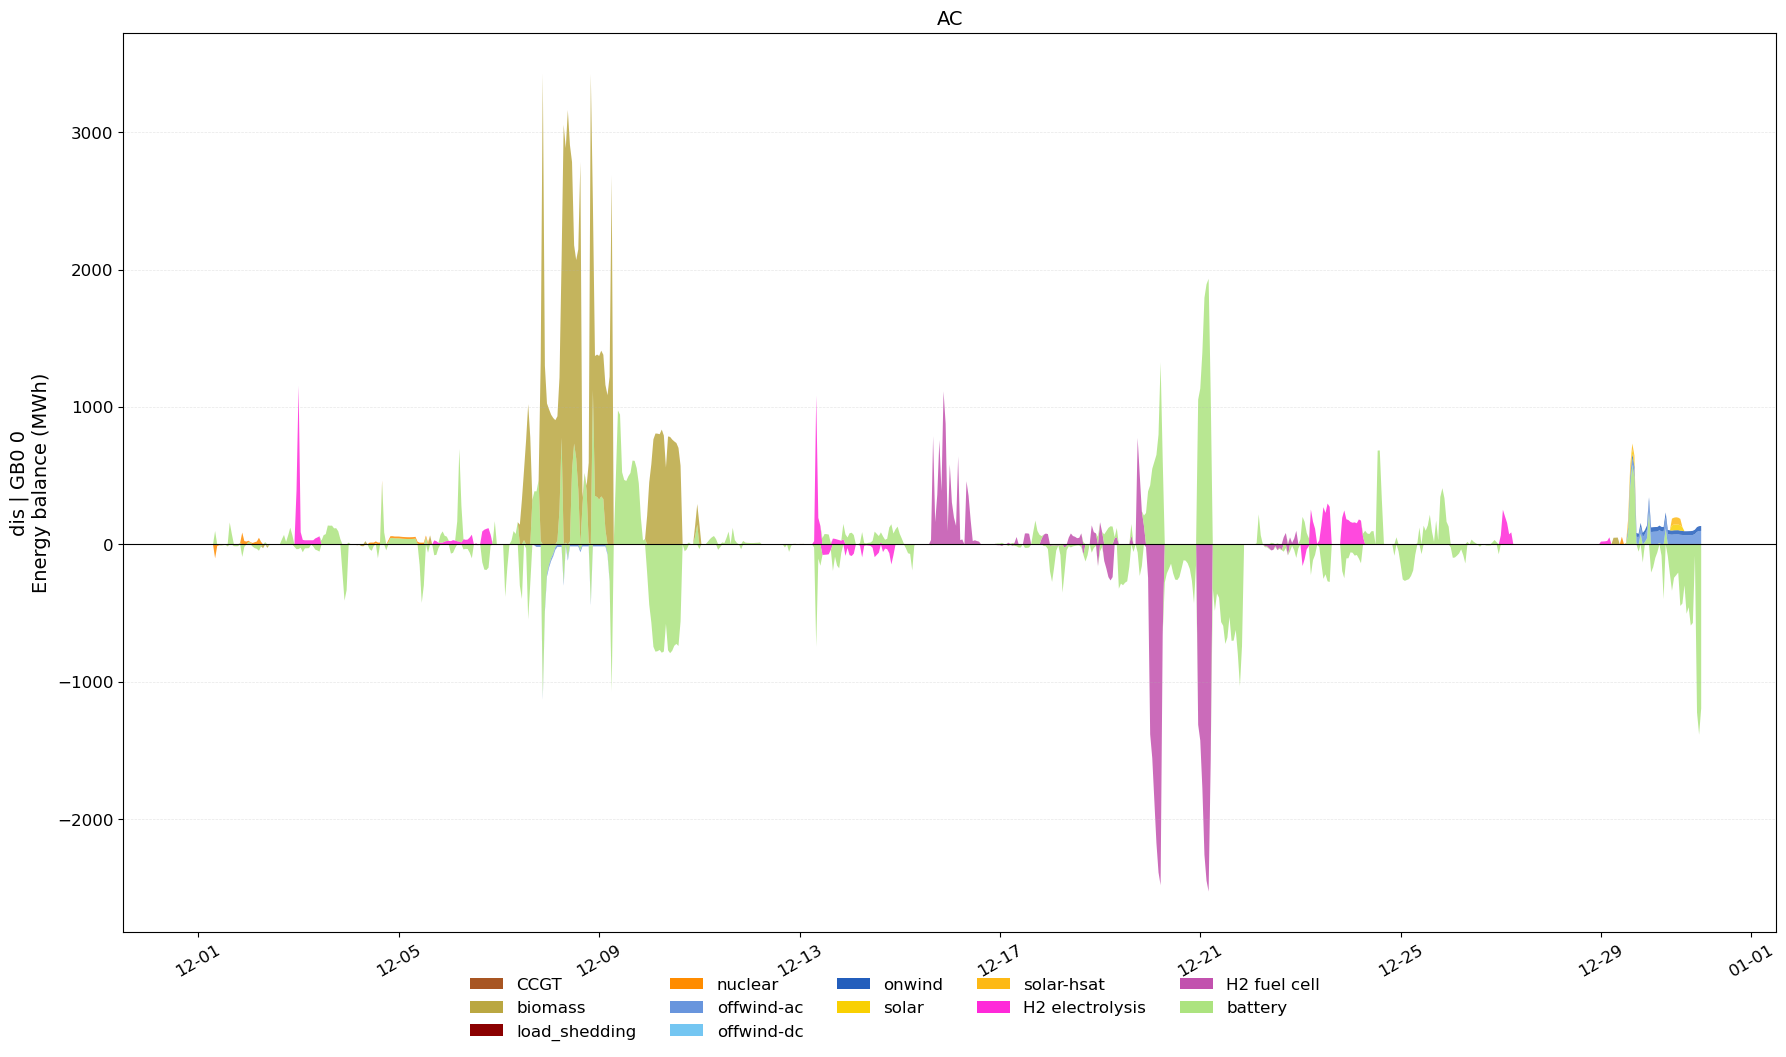

In [88]:
fig, axes = plot_stats_area(
    ts_diff[ts_diff["component"].isin(["Generator", "StorageUnit", "Link", "Store"])
            & (ts_diff["bus"] == "GB0 0")].assign(value=ts_diff["value_diff"]),
    networks=["dis"],
    bus_carriers=["AC"],
    facet_col="bus_carrier",
    facet_row="network",
    date_range=("2021-12-01", "2021-12-31"),
    aggregate=False,
    color_map=networks["base"].carriers.color.to_dict(),
    title="Energy balance (MWh)",
    figsize=(18, 10),
)

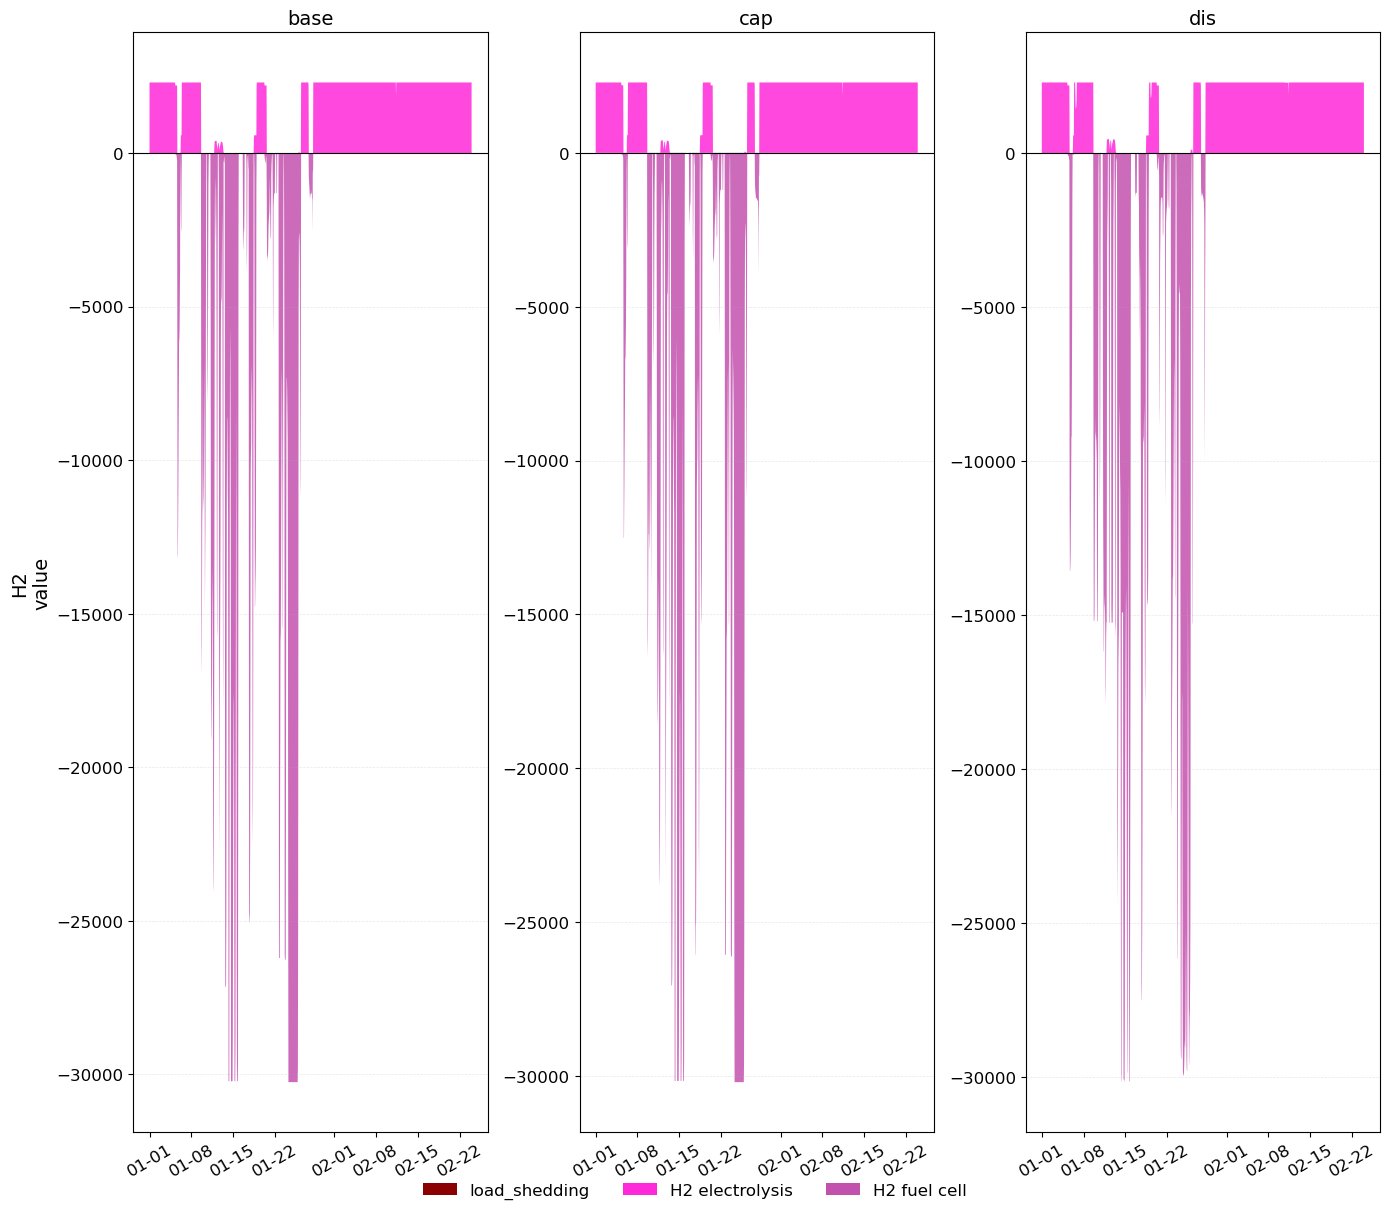

In [ ]:
fig, axes = plot_stats_area(
    ts_eb[
        # ts_eb["component"].isin(["Generator", "StorageUnit"]) &
        ts_eb["bus_carrier"].eq("H2")
    ],
    networks=["base", "cap", "dis"],
    bus_carriers=["H2"],
    date_range=("2022-01-01", "2022-02-24"),
    aggregate=True,
    color_map=networks["base"].carriers.color.to_dict(),
    figsize=(14, 12),
)


# Wind outage metrics entsoe

In [43]:
SNAP_START  = "2021-06-01"
SNAP_END    = "2022-05-31 23:00"

In [95]:
def _load_damage_aligned(
    damage_nc_path: Path,
    base_network: pypsa.Network,
    carrier: str,
    date_range: tuple[str, str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    """
    Load damage profile and align with network generators.

    Returns
    -------
    damage_df   : (time × bus) damage fractions
    p_max_pu_df : (time × bus) p_max_pu time series
    capacities  : bus → p_nom_opt, for buses with p_nom_opt > 0
    """
    damage_df = xr.open_dataset(damage_nc_path)["profile"].to_pandas()
    damage_df.index = pd.to_datetime(damage_df.index)
    if date_range is not None:
        damage_df = damage_df.loc[date_range[0]:date_range[1]]

    gens = base_network.generators[
        (base_network.generators.carrier == carrier) &
        (base_network.generators.p_nom_opt > 0)
    ]
    capacities = pd.Series(gens["p_nom_opt"].values, index=gens["bus"].values)

    common_buses = damage_df.columns.intersection(capacities.index)
    damage_df  = damage_df[common_buses]
    capacities = capacities[common_buses]

    p_max_pu_dict = {}
    for gen_idx, gen in gens[gens["bus"].isin(common_buses)].iterrows():
        if gen_idx in base_network.generators_t.p_max_pu.columns:
            ts = base_network.generators_t.p_max_pu[gen_idx]
        else:
            ts = pd.Series(gen["p_max_pu"], index=damage_df.index)
        ts.index = pd.to_datetime(ts.index)
        p_max_pu_dict[gen["bus"]] = ts.reindex(damage_df.index)

    return damage_df, pd.DataFrame(p_max_pu_dict), capacities


def _aggregate(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    if freq == "h":
        return df
    if freq == "total":
        return pd.DataFrame([df.sum()], index=pd.Index([df.index[0]]))
    return df.resample(freq).sum()


def compute_eoh(
    damage_nc_path: Path,
    base_network: pypsa.Network,
    carrier: str,
    date_range: tuple[str, str] | None = None,
    freq: str = "MS",
    by_bus: bool = False,
) -> pd.DataFrame:
    """
    Equivalent outage hours — count of hours with damage > 0 per period.

    Parameters
    ----------
    freq : "h" | "W" | "MS" | "total"
    by_bus : True → one column per bus; False → capacity-weighted fleet column.

    Returns
    -------
    pd.DataFrame  index=time periods, columns=buses or ["fleet"]
    """
    damage_df, _, capacities = _load_damage_aligned(
        damage_nc_path, base_network, carrier, date_range
    )
    eoh_df = _aggregate(damage_df, freq)

    if by_bus:
        return eoh_df

    fleet = eoh_df.mul(capacities, axis=1).sum(axis=1) / capacities.sum()
    return fleet.rename("fleet").to_frame()


def compute_potential_energy_loss(
    damage_nc_path: Path,
    base_network: pypsa.Network,
    carrier: str,
    date_range: tuple[str, str] | None = None,
    freq: str = "MS",
    by_bus: bool = False,
) -> pd.DataFrame:
    """
    Potential energy loss (MWh) — energy that would have been generated without damage.

    PEL = damage_fraction × p_max_pu × p_nom_opt, aggregated per period.

    Parameters
    ----------
    freq : "h" | "W" | "MS" | "total"
    by_bus : True → one column per bus; False → fleet total (sum across buses).

    Returns
    -------
    pd.DataFrame  index=time periods, columns=buses or ["fleet"]
    """
    damage_df, p_max_pu_df, capacities = _load_damage_aligned(
        damage_nc_path, base_network, carrier, date_range
    )
    pel_df = _aggregate(damage_df * p_max_pu_df * capacities, freq)

    if by_bus:
        return pel_df

    return pel_df.sum(axis=1).rename("fleet").to_frame()


In [96]:
SCENARIO_DIR

PosixPath('/home/lois/pypsa-eur/pypsa-eur/resources/2021-GB/weather_year_2021_win_dis_LGLP')

In [101]:
CARRIER = "offwind-ac"
dmg_path = SCENARIO_DIR / "damage_profiles" / f"{CARRIER}_damage_{CLUSTERS}.nc"
base_net = networks["base"]
dr = (SNAP_START, SNAP_END)

In [49]:
eoh_fleet = compute_eoh(dmg_path, base_net, CARRIER, date_range=dr, freq="MS")
eoh_fleet

,fleet
time,
2021-06-01,0.000000e+00
2021-07-01,2.464975e-04
2021-08-01,4.225790e-23
2021-09-01,1.812448e-01
2021-10-01,4.689251e-01
2021-11-01,7.773823e+00
2021-12-01,2.263442e+00
2022-01-01,3.806702e+00
2022-02-01,1.280971e+01


In [50]:
# Per-bus monthly EOH — one column per bus
eoh_by_bus = compute_eoh(dmg_path, base_net, CARRIER, date_range=dr, freq="MS", by_bus=True)
eoh_by_bus

bus,GB0 0,GB0 1,GB0 2,GB0 3,GB1 0
time,,,,,
2021-06-01,0.000000,0.000000,0.000000,0.000000e+00,0.000000
2021-07-01,0.000775,0.000000,0.000000,7.274227e-02,0.000000
2021-08-01,0.000000,0.000000,0.000000,7.826584e-18,0.000000
2021-09-01,0.000032,0.000000,0.907259,3.103023e-04,0.029646
2021-10-01,1.281206,0.049339,0.190715,2.552024e-01,0.065485
2021-11-01,0.264594,10.819035,12.359706,1.216375e+01,8.350143
2021-12-01,0.089342,2.334237,5.549532,9.601461e+00,9.464909
2022-01-01,0.000000,0.680338,17.412603,5.112051e-02,9.521721
2022-02-01,12.625071,13.019930,12.594794,1.690002e+01,34.532075


In [51]:
eoh_total = compute_eoh(dmg_path, base_net, CARRIER, date_range=dr, freq="total")
eoh_total

,fleet
2021-06-01,27.527785


# Heat Maps

In [52]:
pel_fleet = compute_potential_energy_loss(dmg_path, base_net, CARRIER, date_range=dr, freq="MS")
pel_fleet


,fleet
time,
2021-06-01,0.000000e+00
2021-07-01,4.384330e+00
2021-08-01,1.830164e-19
2021-09-01,3.049819e+03
2021-10-01,7.624158e+03
2021-11-01,1.261141e+05
2021-12-01,3.742837e+04
2022-01-01,5.613250e+04
2022-02-01,2.187174e+05


In [62]:
base_net_on = networks["base_line-on"]
pel_fleet_on = compute_potential_energy_loss(dmg_path, base_net_on, CARRIER, date_range=dr, freq="MS")
pel_fleet_on


,fleet
time,
2021-06-01,0.000000e+00
2021-07-01,4.382561e+00
2021-08-01,1.212183e-19
2021-09-01,3.049809e+03
2021-10-01,7.624147e+03
2021-11-01,1.261135e+05
2021-12-01,3.742780e+04
2022-01-01,5.613213e+04
2022-02-01,2.187160e+05


In [53]:
pel_by_bus = compute_potential_energy_loss(dmg_path, base_net, "offwind-ac", date_range=dr, freq="MS", by_bus=True)
pel_by_bus

bus,GB0 0,GB0 1,GB0 2,GB0 3,GB1 0
time,,,,,
2021-06-01,0.000000,0.000000,0.000000,0.000000e+00,0.000000
2021-07-01,4.379089,0.000000,0.000000,5.241503e-03,0.000000
2021-08-01,0.000000,0.000000,0.000000,1.830164e-19,0.000000
2021-09-01,0.186884,0.000000,3049.629129,2.970192e-05,0.002876
2021-10-01,6760.144628,364.058674,499.921917,2.500804e-02,0.007285
2021-11-01,1535.546398,84774.345976,39802.339333,1.094247e+00,0.817020
2021-12-01,537.258345,19047.504980,17841.748743,9.202258e-01,0.940231
2022-01-01,0.000000,5007.723587,51123.833784,4.612296e-03,0.934560
2022-02-01,70602.270876,103975.484780,44134.666718,1.646130e+00,3.346835


In [63]:
pel_by_bus_on = compute_potential_energy_loss(dmg_path, base_net_on, "offwind-ac", date_range=dr, freq="MS", by_bus=True)
pel_by_bus_on

bus,GB0 0,GB0 1,GB0 2,GB0 3,GB1 0
time,,,,,
2021-06-01,0.000000,0.000000,0.000000,0.000000e+00,0.000000
2021-07-01,4.379090,0.000000,0.000000,3.471633e-03,0.000000
2021-08-01,0.000000,0.000000,0.000000,1.212183e-19,0.000000
2021-09-01,0.186884,0.000000,3049.619988,1.967263e-05,0.002225
2021-10-01,6760.146013,364.058674,499.920418,1.656371e-02,0.005637
2021-11-01,1535.546713,84774.345976,39802.220030,7.247581e-01,0.632216
2021-12-01,537.258456,19047.504980,17841.695264,6.094980e-01,0.727558
2022-01-01,0.000000,5007.723587,51123.680547,3.054887e-03,0.723170
2022-02-01,70602.285347,103975.484780,44134.534430,1.090290e+00,2.589807


In [54]:
pel_weekly = compute_potential_energy_loss(dmg_path, base_net, "offwind-ac", date_range=dr, freq="W", by_bus=True)
pel_weekly

bus,GB0 0,GB0 1,GB0 2,GB0 3,GB1 0
time,,,,,
2021-06-06,0.000000,0.000000,0.000000,0.000000,0.000000
2021-06-13,0.000000,0.000000,0.000000,0.000000,0.000000
2021-06-20,0.000000,0.000000,0.000000,0.000000,0.000000
2021-06-27,0.000000,0.000000,0.000000,0.000000,0.000000
2021-07-04,0.000000,0.000000,0.000000,0.000000,0.000000
2021-07-11,4.379089,0.000000,0.000000,0.000000,0.000000
2021-07-18,0.000000,0.000000,0.000000,0.000000,0.000000
2021-07-25,0.000000,0.000000,0.000000,0.000000,0.000000
2021-08-01,0.000000,0.000000,0.000000,0.005242,0.000000


In [55]:
CARRIERS

{'onwind': ('availability_matrix_5_onwind.nc', 'Vestas_V112_3MW'),
 'offwind-ac': ('availability_matrix_5_offwind-ac.nc',
  'NREL_ReferenceTurbine_2020ATB_5.5MW'),
 'offwind-dc': ('availability_matrix_5_offwind-dc.nc',
  'NREL_ReferenceTurbine_2020ATB_5.5MW')}

In [57]:
for carrier in CARRIERS:
    dmg = SCENARIO_DIR / "damage_profiles" / f"{carrier}_damage_{CLUSTERS}.nc"
    pel = compute_potential_energy_loss(dmg, base_net, carrier, date_range=dr, freq="total")
    print(f"{carrier}: {pel['fleet'].iloc[0] / 1e6:.2f} TWh lost")

onwind: 0.14 TWh lost
offwind-ac: 0.77 TWh lost
offwind-dc: 0.82 TWh lost


In [98]:
from plot_combo import (
    plot_combination_profile,
    format_ts_df, format_ts_diff_df,
    build_eb_diff_by_bus, build_storage_dict,
)

In [36]:
def _pivot(ts_eb, network, carrier, bus_carrier):
    mask = (
        (ts_eb["network"]     == network) &
        (ts_eb["carrier"]     == carrier) &
        (ts_eb["bus_carrier"] == bus_carrier)
    )
    return (
        ts_eb[mask]
        .pivot_table(index="snapshot", columns="bus", values="value", aggfunc="sum")
        .fillna(0)
    )

def get_soc_by_bus(n, carrier):
    store_idx = n.stores.index[n.stores.carrier == carrier]
    if not store_idx.empty:
        df = n.stores_t.e[store_idx].copy()
        df.columns = n.stores.loc[store_idx, "bus"]
        return df.T.groupby(level=0).sum().T
    su_idx = n.storage_units.index[n.storage_units.carrier == carrier]
    if not su_idx.empty:
        df = n.storage_units_t.state_of_charge[su_idx].copy()
        df.columns = n.storage_units.loc[su_idx, "bus"]
        return df.T.groupby(level=0).sum().T
    raise ValueError(f"No Store or StorageUnit found for carrier '{carrier}'")

def _fleet_price(n):
    ac     = n.buses.index[n.buses.carrier == "AC"]
    prices = n.buses_t.marginal_price[ac]
    load_w = n.loads_t.p_set.reindex(columns=ac).fillna(0)
    return (prices * load_w).sum(axis=1) / load_w.sum(axis=1).replace(0, np.nan)

def prepare_combo_data(base, scen, *, nc, pel_nc_paths=None):
    n_base = nc.networks[base]
    n_scen = nc.networks[scen]

    EXCLUDE = ["coal", "ocgt", "ccgt"]
    ts_eb   = format_ts_df(nc, stat="energy_balance")
    ts_eb   = ts_eb[~ts_eb["carrier"].isin(EXCLUDE)]
    ts_diff = format_ts_diff_df(nc.networks, stat="energy_balance", base=base)

    def p(network, carrier, bus_carrier):
        return _pivot(ts_eb, network, carrier, bus_carrier)

    ls_df = p(scen, "load_shedding", "AC")
    ls_df[ls_df < 0.001] = 0

    fc_df      = p(scen, "H2 fuel cell", "AC")
    fc_diff_df = fc_df - p(base, "H2 fuel cell", "AC")

    elec_scen_df = p(scen, "H2 electrolysis", "H2")
    elec_diff_df = elec_scen_df - p(base, "H2 electrolysis", "H2")

    line_df      = p(scen, "AC", "AC")
    line_base_df = p(base, "AC", "AC")
    line_diff_df = line_df - line_base_df

    soc_scen        = get_soc_by_bus(n_scen, "H2")
    soc_base        = get_soc_by_bus(n_base, "H2")
    soc_diff_df     = soc_scen - soc_base
    h2_e_nom_by_bus = (
        n_scen.stores[n_scen.stores.carrier == "H2"]
        .groupby("bus")["e_nom_opt"]
        .sum()
    )

    price_scen  = _fleet_price(n_scen)
    price_base_ = _fleet_price(n_base)
    price_fleet = price_scen.to_frame("fleet")
    price_diff  = (price_scen - price_base_).to_frame("fleet")

    if pel_nc_paths is not None:
        pel_dict_win = {
            carrier: compute_potential_energy_loss(path, n_base, carrier, freq="h", by_bus=True)
            for carrier, path in pel_nc_paths.items()
        }
    else:
        pel_dict_win = None

    storage_dict = build_storage_dict(nc, scen)

    return {
        "ts_diff":         ts_diff,
        "ls_df":           ls_df,
        "fc_df":           fc_df,
        "fc_diff_df":      fc_diff_df,
        "elec_scen_df":    elec_scen_df,
        "elec_diff_df":    elec_diff_df,
        "line_df":         line_df,
        "line_base_df":    line_base_df,
        "line_diff_df":    line_diff_df,
        "soc_scen":        soc_scen,
        "soc_base":        soc_base,
        "soc_diff_df":     soc_diff_df,
        "h2_e_nom_by_bus": h2_e_nom_by_bus,
        "price_fleet":     price_fleet,
        "price_diff":      price_diff,
        "pel_dict_win":    pel_dict_win,
        "storage_dict":    storage_dict,
    }


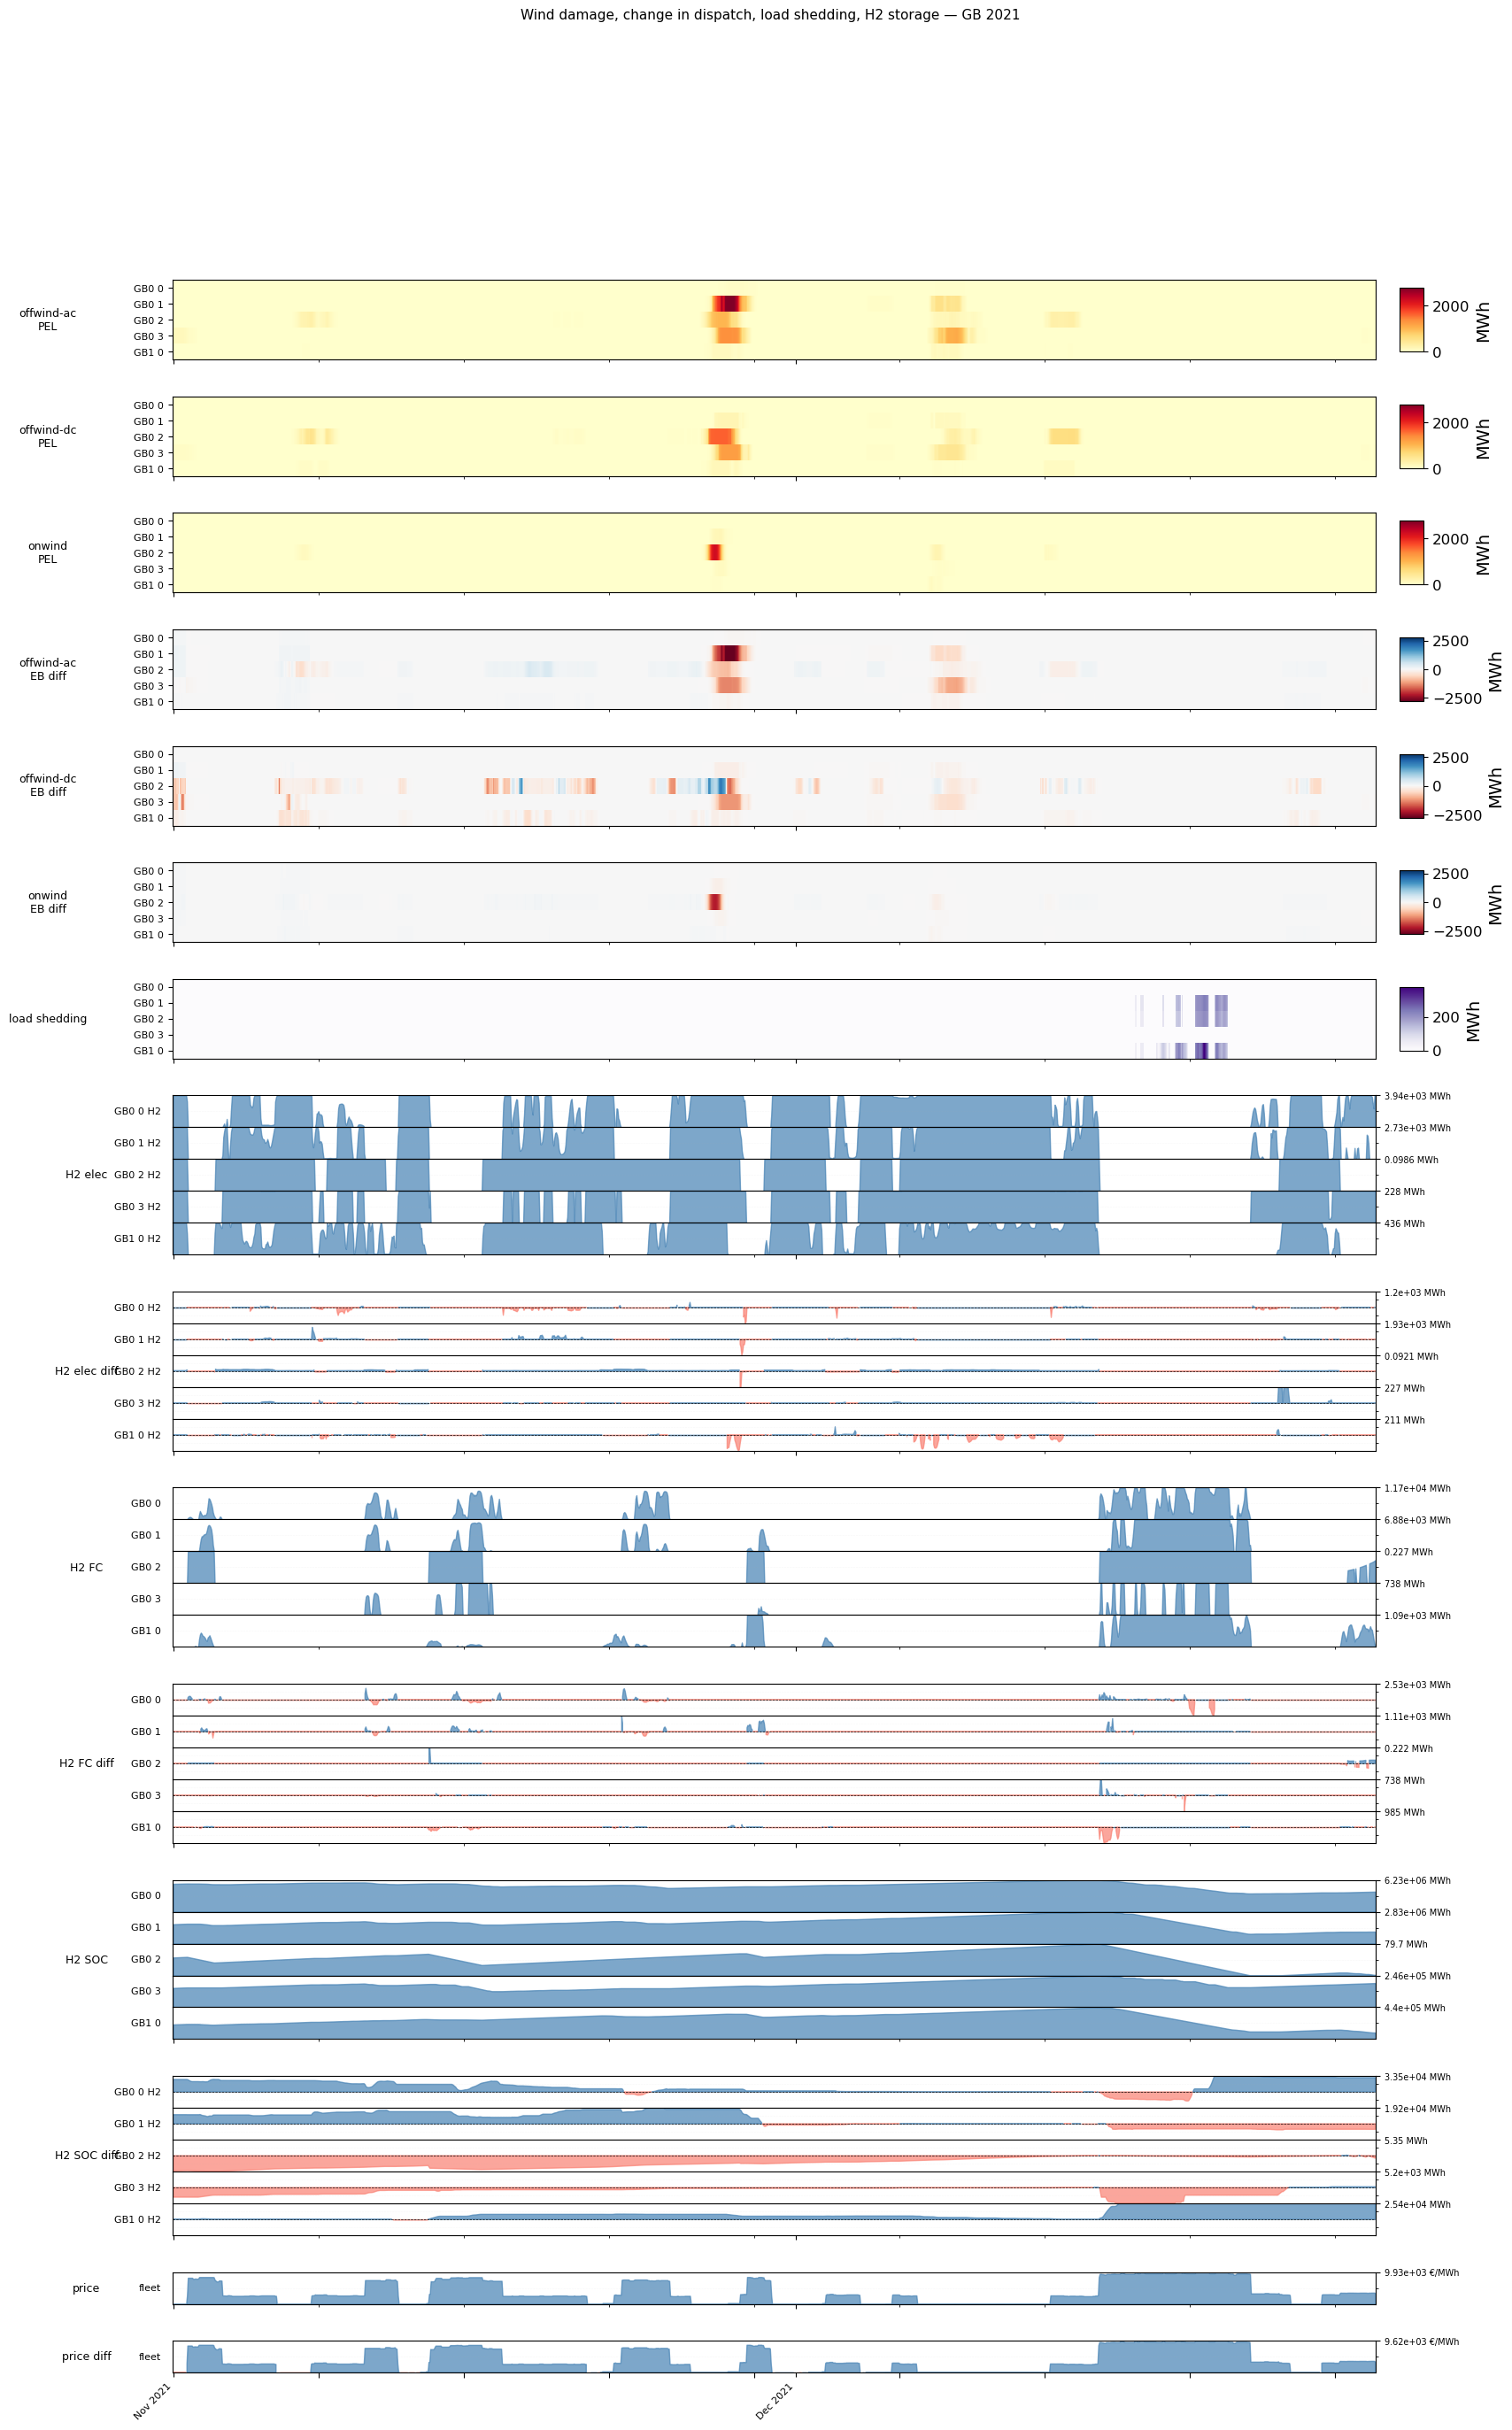

In [119]:
d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=pel_nc_paths)

fig, axes = plot_combination_profile(
    carrier_groups={c: c for c in WIND_CARRIERS},
    components={
        "PEL": {
            "type": "carrier_dict", "data": d["pel_dict_win"],
            "cmap": "YlOrRd", "unit": "MWh", "vmax_group": "wind",
        },
        "EB diff": {
            "type": "ts_diff", "data": d["ts_diff"], "network": scen,
            "cmap": "RdBu", "symmetric": True, "unit": "MWh", "vmax_group": "wind",
        },
        "load shedding": {
            "type": "direct", "data": d["ls_df"],
            "cmap": "Purples", "unit": "MWh",
        },
        "H2 elec": {
            "type": "direct", "data": d["elec_scen_df"],
            "render": "area", "unit": "MWh", "row_height": 0.6,
        },
        "H2 elec diff": {
            "type": "direct", "data": d["elec_diff_df"],
            "render": "area", "symmetric": True, "unit": "MWh", "row_height": 0.6,
        },
        "H2 FC": {
            "type": "direct", "data": d["fc_df"],
            "render": "area", "unit": "MWh", "row_height": 0.6,
        },
        "H2 FC diff": {
            "type": "direct", "data": d["fc_diff_df"],
            "render": "area", "symmetric": True, "unit": "MWh", "row_height": 0.6,
        },
        "H2 SOC": {
            "type": "direct", "data": d["storage_dict"]["H2"],
            "render": "area", "unit": "MWh", "row_height": 0.6,
        },
        "H2 SOC diff": {
            "type": "direct", "data": d["soc_diff_df"],
            "render": "area", "symmetric": True, "unit": "MWh", "row_height": 0.6,
        },
        "price": {
            "type": "direct", "data": d["price_fleet"],
            "render": "area", "unit": "€/MWh", "row_height": 0.6,
        },
        "price diff": {
            "type": "direct", "data": d["price_diff"],
            "render": "area", "unit": "€/MWh", "row_height": 0.6,
        },
    },
    aggregate_buses=False,
    date_range=(f"{YEAR}-11-01", f"{YEAR}-12-28"),
    title=f"Wind damage, change in dispatch, load shedding, H2 storage — GB {YEAR}",
    fig_width=18,
)


In [116]:
base = "base"
scen = "dis"

d = prepare_combo_data(base, scen, nc=nc, pel_nc_paths=pel_nc_paths)

soc_utilisation = pd.DataFrame({
    "e_nom_opt (MWh)":    d["h2_e_nom_by_bus"],
    "max SOC base (MWh)": d["soc_base"].max(),
    "max SOC base at":    d["soc_base"].idxmax(),
    "max SOC scen (MWh)": d["soc_scen"].max(),
    "max SOC scen at":    d["soc_scen"].idxmax(),
    "min SOC base (MWh)": d["soc_base"].min(),
    "min SOC base at":    d["soc_base"].idxmin(),
    "min SOC scen (MWh)": d["soc_scen"].min(),
    "min SOC scen at":    d["soc_scen"].idxmin(),
})
soc_utilisation["utilisation base (%)"] = (
    soc_utilisation["max SOC base (MWh)"] / soc_utilisation["e_nom_opt (MWh)"] * 100
).round(1)
soc_utilisation["utilisation scen (%)"] = (
    soc_utilisation["max SOC scen (MWh)"] / soc_utilisation["e_nom_opt (MWh)"] * 100
).round(1)
soc_utilisation["max SOC diff (MWh)"] = (
    soc_utilisation["max SOC scen (MWh)"] - soc_utilisation["max SOC base (MWh)"]
).round(1)

soc_utilisation


,e_nom_opt (MWh),max SOC base (MWh),max SOC base at,max SOC scen (MWh),max SOC scen at,min SOC base (MWh),min SOC base at,min SOC scen (MWh),min SOC scen at,utilisation base (%),utilisation scen (%),max SOC diff (MWh)
bus,,,,,,,,,,,,
GB0 0 H2,6.229603e+06,6.229603e+06,2021-12-15 14:00:00,6.229603e+06,2021-12-15 14:00:00,0.001332,2022-01-26 10:00:00,0.015603,2022-01-26 10:00:00,100.0,100.0,0.0
GB0 1 H2,2.830187e+06,2.830187e+06,2021-12-15 14:00:00,2.830187e+06,2021-12-15 14:00:00,0.001351,2022-01-26 10:00:00,0.004525,2022-01-26 10:00:00,100.0,100.0,0.0
GB0 2 H2,7.969375e+01,7.968762e+01,2021-12-15 15:00:00,7.969376e+01,2022-03-15 20:00:00,0.007347,2021-09-20 10:00:00,0.000069,2021-09-20 10:00:00,100.0,100.0,0.0
GB0 3 H2,2.464473e+05,2.464472e+05,2021-12-15 14:00:00,2.464472e+05,2021-12-15 14:00:00,0.001276,2022-01-26 10:00:00,0.000351,2022-01-26 10:00:00,100.0,100.0,0.0
GB1 0 H2,4.403061e+05,4.403061e+05,2021-12-15 14:00:00,4.403061e+05,2021-12-15 14:00:00,0.004852,2022-01-25 21:00:00,0.000360,2021-09-20 10:00:00,100.0,100.0,0.0


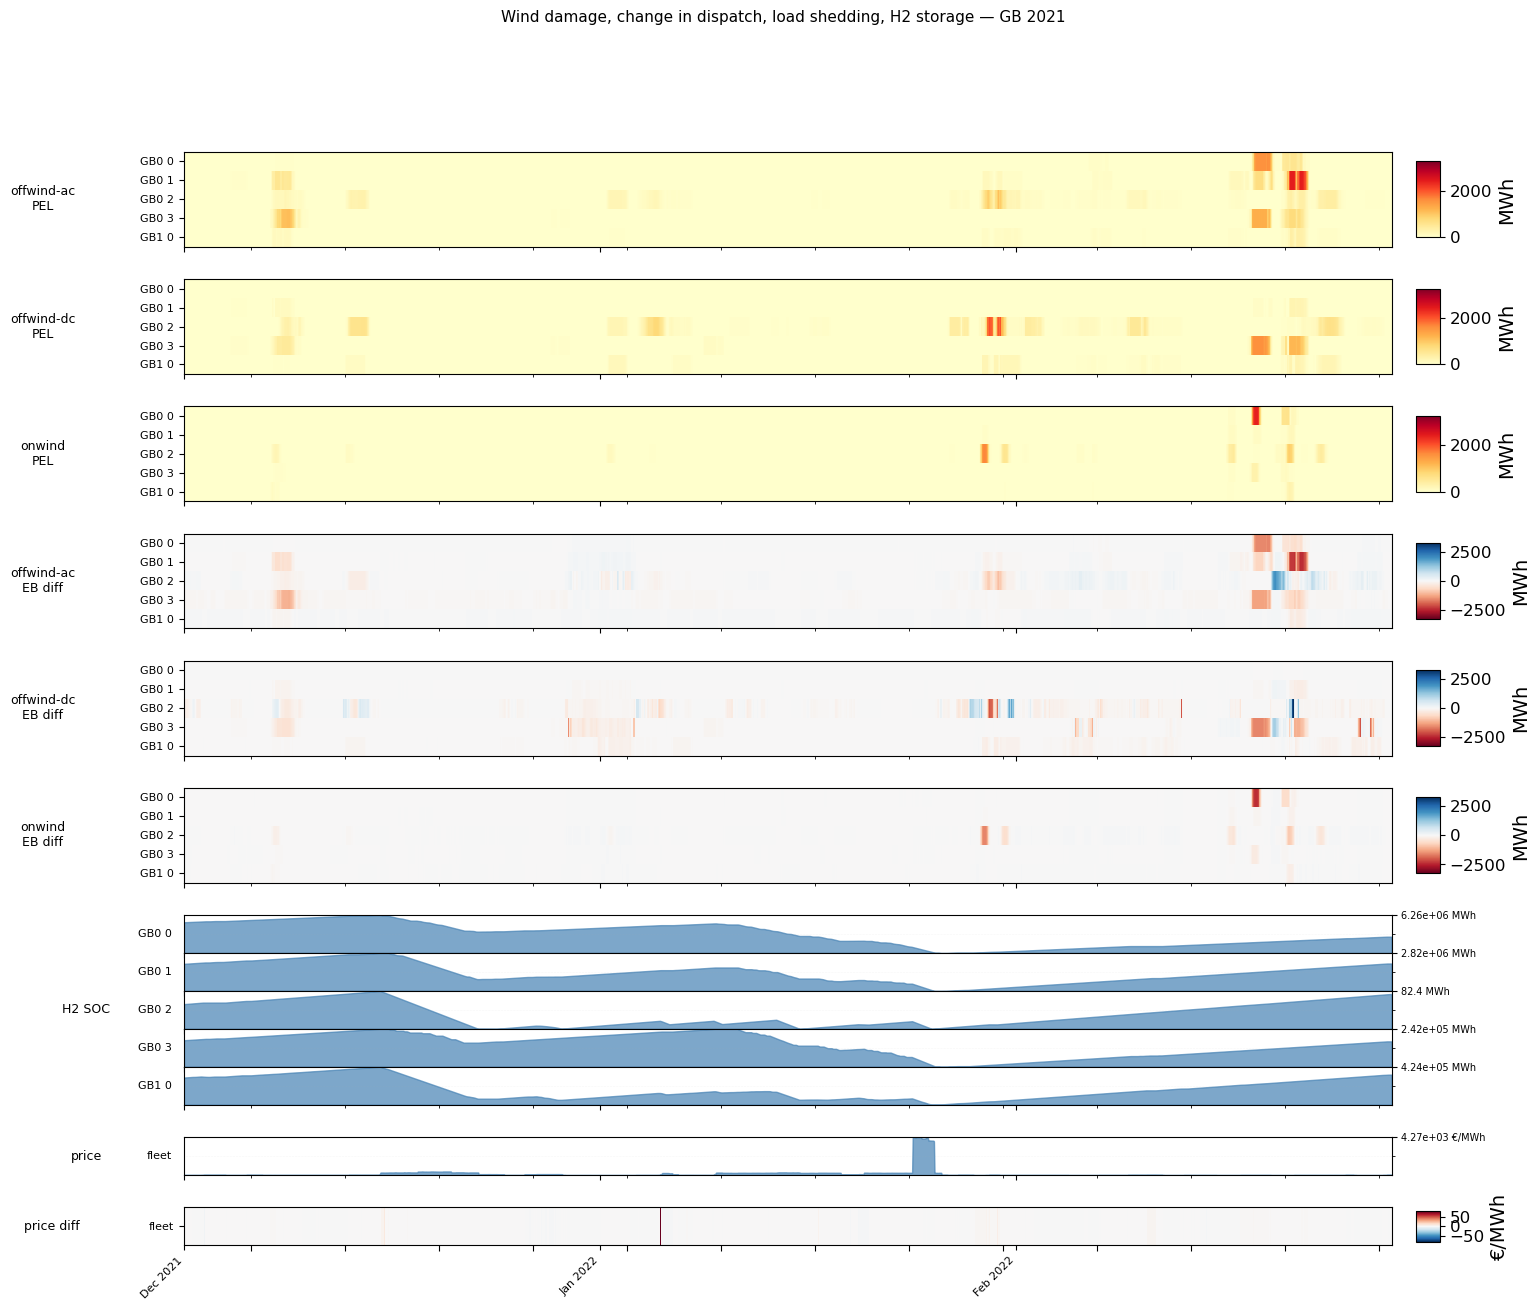

In [103]:
base = "base"
scen = "cap"

# ── Statistics diffs ──────────────────────────────────────────────────────────
ts_diff = format_ts_diff_df(networks, stat="energy_balance", base=base)

# compute load shedding from scenario network only
EXCLUDE_gen_storage = ["coal", "ocgt", "ccgt"]
ts_eb  = format_ts_df(networks[scen], stat="energy_balance")
ts_eb  = ts_eb[~ts_eb["carrier"].isin(EXCLUDE_gen_storage)]
ls_raw = ts_eb[
    (ts_eb["carrier"] == "load_shedding") &
    (ts_eb["bus_carrier"] == "AC")
]
ls_df = ls_raw.pivot_table(index="snapshot", columns="bus", values="value", aggfunc="sum").fillna(0)

# ── Wind PEL ──────────────────────────────────────────────────────────────────
WIND_CARRIERS = ["offwind-ac", "offwind-dc", "onwind"]

pel_dict_win = {
    c: compute_potential_energy_loss(
        SCENARIO_DIR / "damage_profiles" / f"{c}_damage_{CLUSTERS}.nc",
        networks[base], c, date_range=dr, freq="h", by_bus=True
    )
    for c in WIND_CARRIERS
}


storage_dict = build_storage_dict(nc, scen)

# ── Prices ────────────────────────────────────────────────────────────────────
def fleet_price(n):
    ac     = n.buses.index[n.buses.carrier == "AC"]
    prices = n.buses_t.marginal_price[ac]
    load_w = n.loads_t.p_set.reindex(columns=ac).fillna(0)
    return (prices * load_w).sum(axis=1) / load_w.sum(axis=1).replace(0, np.nan)

price_base  = fleet_price(networks[base])
price_dis   = fleet_price(networks[scen])
price_fleet = price_dis.to_frame("fleet")
price_diff  = (price_dis - price_base).to_frame("fleet")

fig, axes = plot_combination_profile(
    carrier_groups={c: c for c in WIND_CARRIERS},
    # carrier_groups={"offwind": ["offwind-ac", "offwind-dc"], "onwind": "onwind"},

    components={
        "PEL": {
            "type": "carrier_dict", "data": pel_dict_win,
            "cmap": "YlOrRd", "unit": "MWh", "vmax_group": "wind",
        },
        "EB diff": {
            "type": "ts_diff", "data": ts_diff, "network": scen,
            "cmap": "RdBu", "symmetric": True, "unit": "MWh", "vmax_group": "wind",
        },
        # "load shedding": {
        #     "type": "direct", "data": ls_df,
        #     "cmap": "Purples", "unit": "MWh",
        # },
        "H2 SOC": {
            "type": "direct", "data": storage_dict["H2"],
            "render": "area",
            "unit": "MWh",
            "row_height": 0.6,
        },
        "price": {
            "type": "direct", "data": price_fleet,
            "render": "area",
            #  "symmetric": True,
            "unit": "€/MWh",
            "row_height": 0.6,
        },
        "price diff": {
            "type": "direct", "data": price_diff,
            "cmap": "RdBu_r",
            "unit": "€/MWh",
            "symmetric": True,
            "row_height": 0.6,
        },

    },
    aggregate_buses=False,
    date_range=(f"{YEAR}-12-01", f"{YEAR+1}-02-28"),
    title=f"Wind damage, change in dispatch, load shedding, H2 storage — GB {YEAR}",
)


In [131]:
ts_eb[ts_eb['carrier'] == "H2 fuel cell"]

,component,network,bus,carrier,bus_carrier,snapshot,value
161,Link,base,GB0 0,H2 fuel cell,AC,2021-06-01 00:00:00,0.00226
163,Link,base,GB0 0 H2,H2 fuel cell,H2,2021-06-01 00:00:00,-0.00451
166,Link,base,GB0 1,H2 fuel cell,AC,2021-06-01 00:00:00,0.00231
168,Link,base,GB0 1 H2,H2 fuel cell,H2,2021-06-01 00:00:00,-0.00462
171,Link,base,GB0 2,H2 fuel cell,AC,2021-06-01 00:00:00,0.00266
...,...,...,...,...,...,...,...
2400185,Link,dis,GB0 2 H2,H2 fuel cell,H2,2022-05-31 23:00:00,-0.00002
2400187,Link,dis,GB0 3,H2 fuel cell,AC,2022-05-31 23:00:00,0.00001
2400189,Link,dis,GB0 3 H2,H2 fuel cell,H2,2022-05-31 23:00:00,-0.00002
2400192,Link,dis,GB1 0,H2 fuel cell,AC,2022-05-31 23:00:00,0.00001


# Aggregate check